# Statistics for Michel electron candidate

### Created by Shu, 202510---

<br />
<br />
<br />
<br />
<br />
<br />

## WVF Coincidence Explore:

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


import os

# ------------------------------------------------------------
# 1️⃣ Define which dates to include
# ------------------------------------------------------------
dates = ["20251029"]  # ✅ modify as needed

coinNum = []     # waveform coincidence numbers


# ------------------------------------------------------------
# 2️⃣ Read waveform coincidence counts
# ------------------------------------------------------------
for d in dates:
    fname = f"./statResult_pds/print_wvfCoin_count{d}.txt"
    if not os.path.exists(fname):
        print(f"[WARN] File not found: {fname}")
        continue

    with open(fname, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            parts = line.split(":")
            if len(parts) >= 2:
                try:
                    number = int(parts[1].strip())
                    coinNum.append(number)
                except ValueError:
                    print(f"[WARN] Could not convert '{parts[1].strip()}' in {fname} to an integer.")








# ------------------------------------------------------------
# ✅ Summary
# ------------------------------------------------------------


print("Track candidates (TPC cut)  : 12707")
print("Track candidates with NO wvf: 1335")
print("Number of track candidates  :", len(coinNum))

#coinNum.extend([0] * (88+95))



Track candidates (TPC cut)  : 12707
Track candidates with NO wvf: 1335
Number of track candidates  : 12127



Candidates with #opWvf>=4:  8284 / 12127 (68.31%)


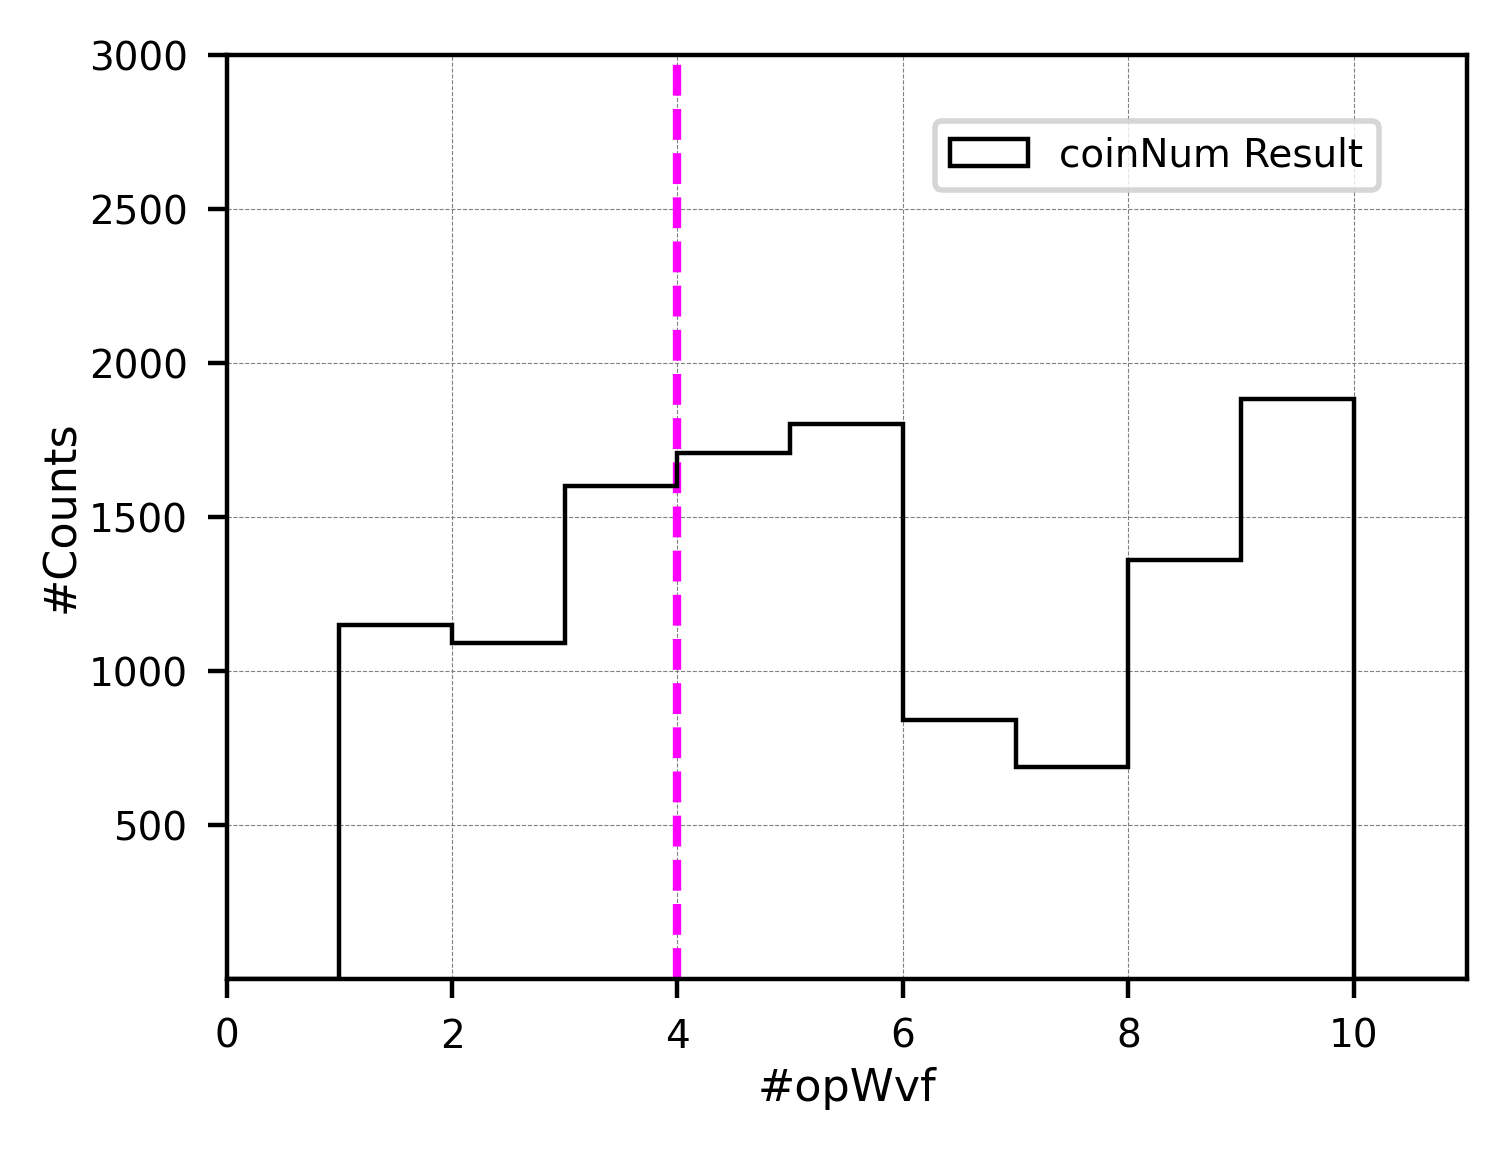

In [3]:
#Apply preliminary cut #opWvf >=4:=====================
coinNum_cut4 = []
coinNum_trueE_cut4 = []
for i in range(0, len(coinNum)):
    coin = coinNum[i]

    if coin >=4:
        coinNum_cut4.append(coin)

print("\nCandidates with #opWvf>=4: ", len(coinNum_cut4), "/", len(coinNum), "({:.2f}%)".format(len(coinNum_cut4)/len(coinNum)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([4, 4], [0, 3000], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coinNum, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label='coinNum Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 3000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






<br />
<br />
<br />
<br />
<br />
<br />

## Process WVF:
### After TPC cuts & (#opWvf >= 4) (This can be taken as "PDS Cut 1")

In [5]:
from dataclasses import dataclass
from typing import Optional
import matplotlib.pyplot as plt
import numpy as np
import re
from mpl_toolkits.mplot3d import Axes3D



# ------------------- Dataclass -------------------
@dataclass
class PdsEvent:
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    third_time: Optional[int] = None             # NEW
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None      # NEW
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None
    # muon
    mu_leftTurn: Optional[int] = None
    mu_rightTurn: Optional[int] = None
    mu_leftHeight: Optional[float] = None
    mu_rightHeight: Optional[float] = None
    # michel
    mi_leftTurn: Optional[int] = None
    mi_rightTurn: Optional[int] = None
    mi_leftHeight: Optional[float] = None
    mi_rightHeight: Optional[float] = None
    # third peak
    th_leftTurn: Optional[int] = None            # NEW
    th_rightTurn: Optional[int] = None           # NEW
    th_leftHeight: Optional[float] = None        # NEW
    th_rightHeight: Optional[float] = None       # NEW
    # Michel-level attributes
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None            # ✅ NEW



# ------------------- Helpers -------------------
def parse_event_track(path_str: str):
    """Extract eventID and trackID from a file path string."""
    m = re.search(r"event(\d+)_trackID(\d+)", path_str)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None



def read_total_files(files, dates, kind="muon"):
    """
    Read *_total_xxx.txt files.
    Each line: path: t, I, leftTurn, leftHeight, rightTurn, rightHeight
    """
    records = []
    for fname, date in zip(files, dates):
        try:
            with open(fname, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split(":")
                    if len(parts) < 2:
                        continue

                    path_part = parts[0].strip()
                    values = [v.strip() for v in parts[1].split(",")]
                    if len(values) < 6:
                        print(f"[WARN] Malformed line in {fname}: {line}")
                        continue

                    try:
                        time_val = int(values[0])
                        inten_val = float(values[1])
                        left_turn = int(values[2])
                        left_h = float(values[3])
                        right_turn = int(values[4])
                        right_h = float(values[5])
                    except ValueError:
                        print(f"[WARN] Could not parse numbers in {line}")
                        continue

                    evID, trID = parse_event_track(path_part)
                    rec = {"eventID": evID, "trackID": trID, "date": int(date)}

                    if kind == "muon":
                        rec.update({
                            "muon_time": time_val,
                            "muon_intensity": inten_val,
                            "mu_leftTurn": left_turn,
                            "mu_leftHeight": left_h,
                            "mu_rightTurn": right_turn,
                            "mu_rightHeight": right_h
                        })
                    elif kind == "michel":
                        rec.update({
                            "michel_time": time_val,
                            "michel_intensity": inten_val,
                            "mi_leftTurn": left_turn,
                            "mi_leftHeight": left_h,
                            "mi_rightTurn": right_turn,
                            "mi_rightHeight": right_h
                        })
                    elif kind == "third":
                        rec.update({
                            "third_time": time_val,
                            "third_intensity": inten_val,
                            "th_leftTurn": left_turn,
                            "th_leftHeight": left_h,
                            "th_rightTurn": right_turn,
                            "th_rightHeight": right_h
                        })

                    records.append(rec)
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return records




def read_plain_files(files, cast_type=float):
    """Read one or more plain text files with one number per line and return concatenated values."""
    values = []
    for fname in files:
        try:
            with open(fname, "r") as file:
                for line in file:
                    value = line.strip()
                    if value:
                        try:
                            values.append(cast_type(value))
                        except ValueError:
                            print(f"Could not convert {value} in {fname}")
        except FileNotFoundError:
            print(f"File not found: {fname}")
    return values



# ------------------- Load data -------------------
dates = ["20251029"]

muon_files   = [f"./statResult_pds/muon_total_{d}.txt" for d in dates]
michel_files = [f"./statResult_pds/michel_total_{d}.txt" for d in dates]
third_files  = [f"./statResult_pds/third_total_{d}.txt" for d in dates]

muon_records   = read_total_files(muon_files, dates, kind="muon")
michel_records = read_total_files(michel_files, dates, kind="michel")
third_records  = read_total_files(third_files, dates, kind="third")

# --- plain text attributes ---
posX     = read_plain_files([f"./statResult_pds/posX_extract_{d}.txt" for d in dates])
posY     = read_plain_files([f"./statResult_pds/posY_extract_{d}.txt" for d in dates])
posZ     = read_plain_files([f"./statResult_pds/posZ_extract_{d}.txt" for d in dates])
miScore  = read_plain_files([f"./statResult_pds/michelScore_extract_{d}.txt" for d in dates])
miHits   = read_plain_files([f"./statResult_pds/michelHits_extract_{d}.txt" for d in dates], cast_type=int)



# ------------------- Build dataset -------------------
events_veryInitial = []
n_events = min(
    len(muon_records), len(michel_records), len(third_records),
    len(posX), len(posY), len(posZ),
    len(miScore), len(miHits)
)

for i in range(n_events):
    rec_mu = muon_records[i]
    rec_mi = michel_records[i]
    rec_th = third_records[i]

    ev = PdsEvent(
        eventID=rec_mu.get("eventID", rec_mi.get("eventID", rec_th.get("eventID"))),
        trackID=rec_mu.get("trackID", rec_mi.get("trackID", rec_th.get("trackID"))),
        date=rec_mu.get("date", rec_mi.get("date", rec_th.get("date"))),

        # muon
        muon_time=rec_mu.get("muon_time"),
        muon_intensity=rec_mu.get("muon_intensity"),
        mu_leftTurn=rec_mu.get("mu_leftTurn"),
        mu_leftHeight=rec_mu.get("mu_leftHeight"),
        mu_rightTurn=rec_mu.get("mu_rightTurn"),
        mu_rightHeight=rec_mu.get("mu_rightHeight"),

        # michel
        michel_time=rec_mi.get("michel_time"),
        michel_intensity=rec_mi.get("michel_intensity"),
        mi_leftTurn=rec_mi.get("mi_leftTurn"),
        mi_leftHeight=rec_mi.get("mi_leftHeight"),
        mi_rightTurn=rec_mi.get("mi_rightTurn"),
        mi_rightHeight=rec_mi.get("mi_rightHeight"),
        michel_score=miScore[i],
        michel_hits=miHits[i],

        # third
        third_time=rec_th.get("third_time"),
        third_intensity=rec_th.get("third_intensity"),
        th_leftTurn=rec_th.get("th_leftTurn"),
        th_leftHeight=rec_th.get("th_leftHeight"),
        th_rightTurn=rec_th.get("th_rightTurn"),
        th_rightHeight=rec_th.get("th_rightHeight"),

        # physical properties
        posX=posX[i], posY=posY[i], posZ=posZ[i]
    )
    events_veryInitial.append(ev)

print("Very initial dataset:", len(events_veryInitial))

example = events_veryInitial[0]
print("\nExample Event (index 0):")
for field, value in vars(example).items():
    print(f"  {field:20s}: {value}")









#Apply cuts on peak intensities-----------------------------
events_reco_initial = []

for ev in events_veryInitial:
    muIntensity = ev.muon_intensity
    miIntensity = ev.michel_intensity

    if muIntensity > 0.3  and miIntensity > -0.1:#mu & mi are cuts in following block already!
        events_reco_initial.append(ev)


print("\nDataset after initial intensity-cut----------------------")
print("Michel initial dataset   : ", len(events_reco_initial))






Very initial dataset: 8284

Example Event (index 0):
  muon_time           : 58
  michel_time         : 230
  third_time          : 128
  muon_intensity      : 7.8207
  michel_intensity    : 2.06045
  third_intensity     : 0.500291
  posX                : -127.796
  posY                : 344.023
  posZ                : 348.168
  eventID             : 100017
  trackID             : 4
  date                : 20251029
  mu_leftTurn         : 36
  mu_rightTurn        : 82
  mu_leftHeight       : 9.89513
  mu_rightHeight      : 7.8207
  mi_leftTurn         : 213
  mi_rightTurn        : 263
  mi_leftHeight       : 2.30839
  mi_rightHeight      : 2.06045
  th_leftTurn         : 112
  th_rightTurn        : 159
  th_leftHeight       : 0.500291
  th_rightHeight      : 1.09959
  michel_score        : 0.499263
  michel_hits         : 19

Dataset after initial intensity-cut----------------------
Michel initial dataset   :  8284


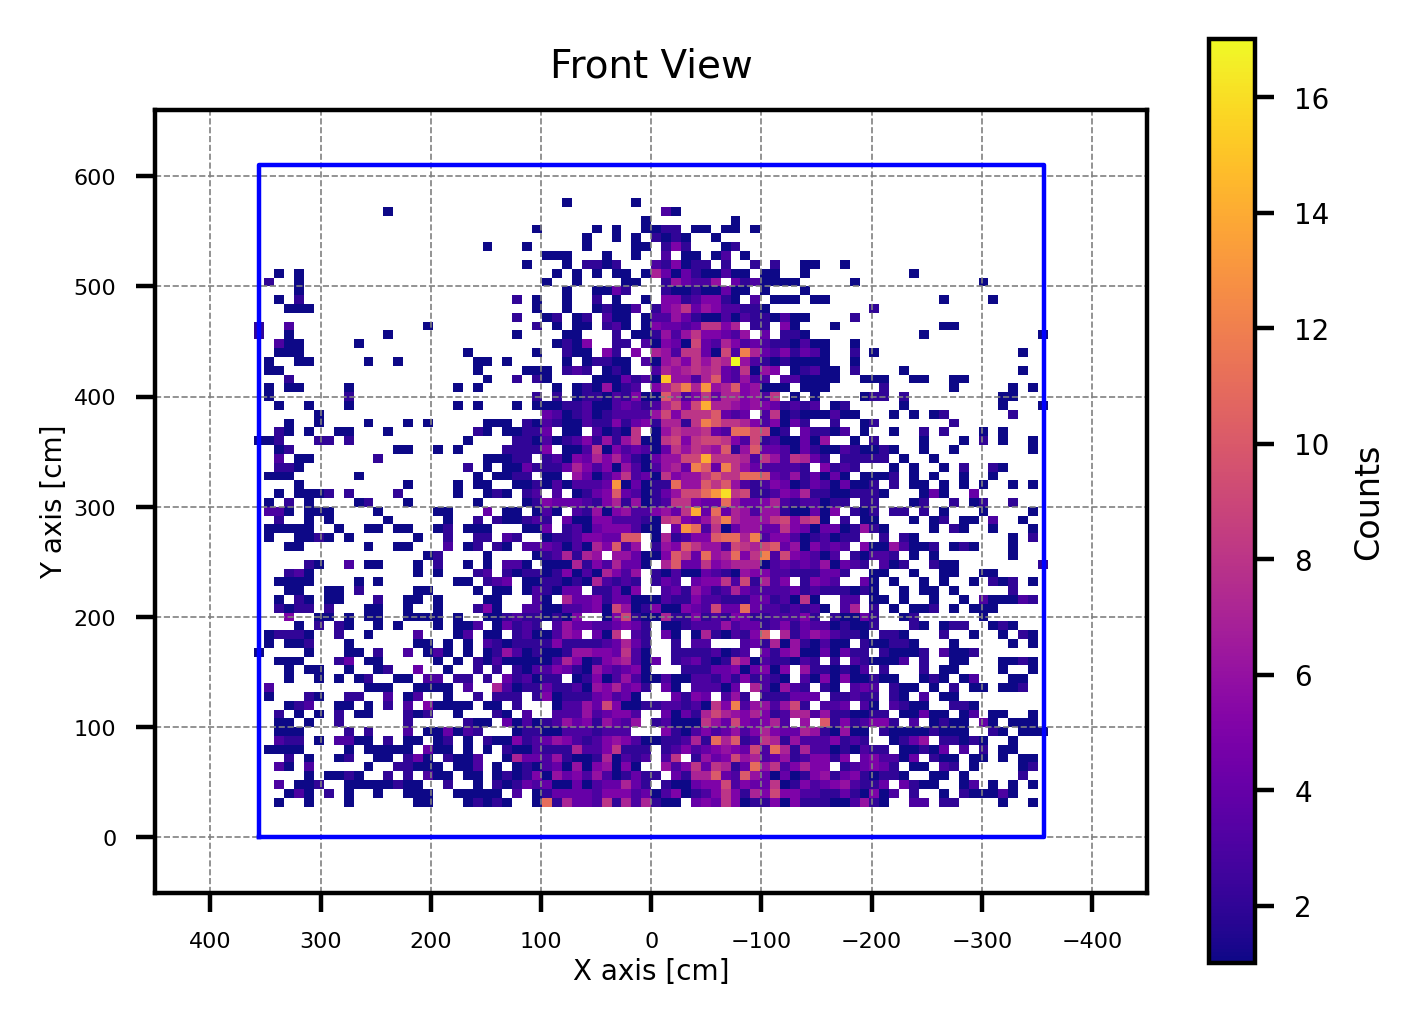

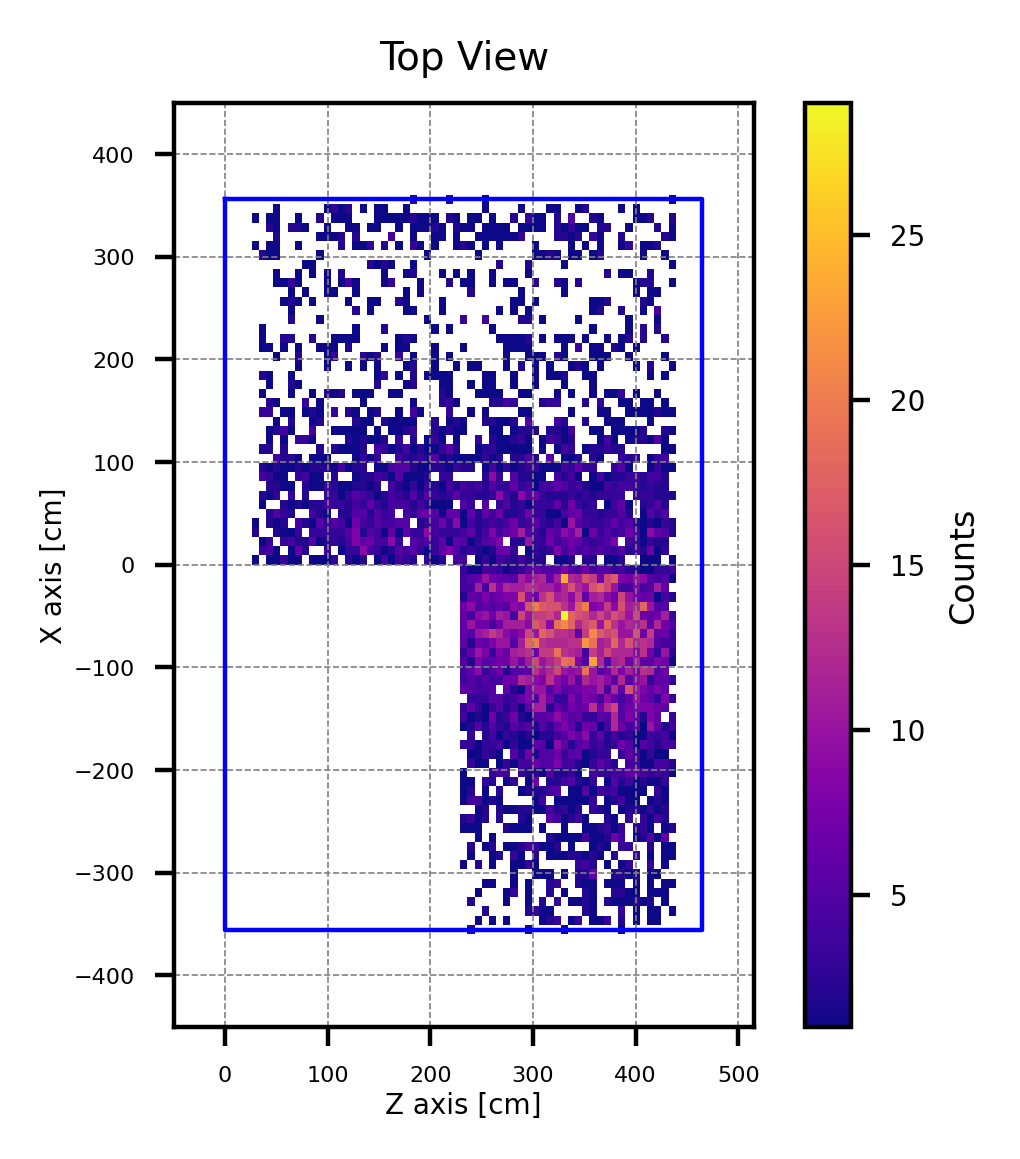


Decay points distribution (TPC & #opWvf cuts): 
# of X < 0 :  5458 (65.89%)
# of X >= 0:  2826 (34.11%)


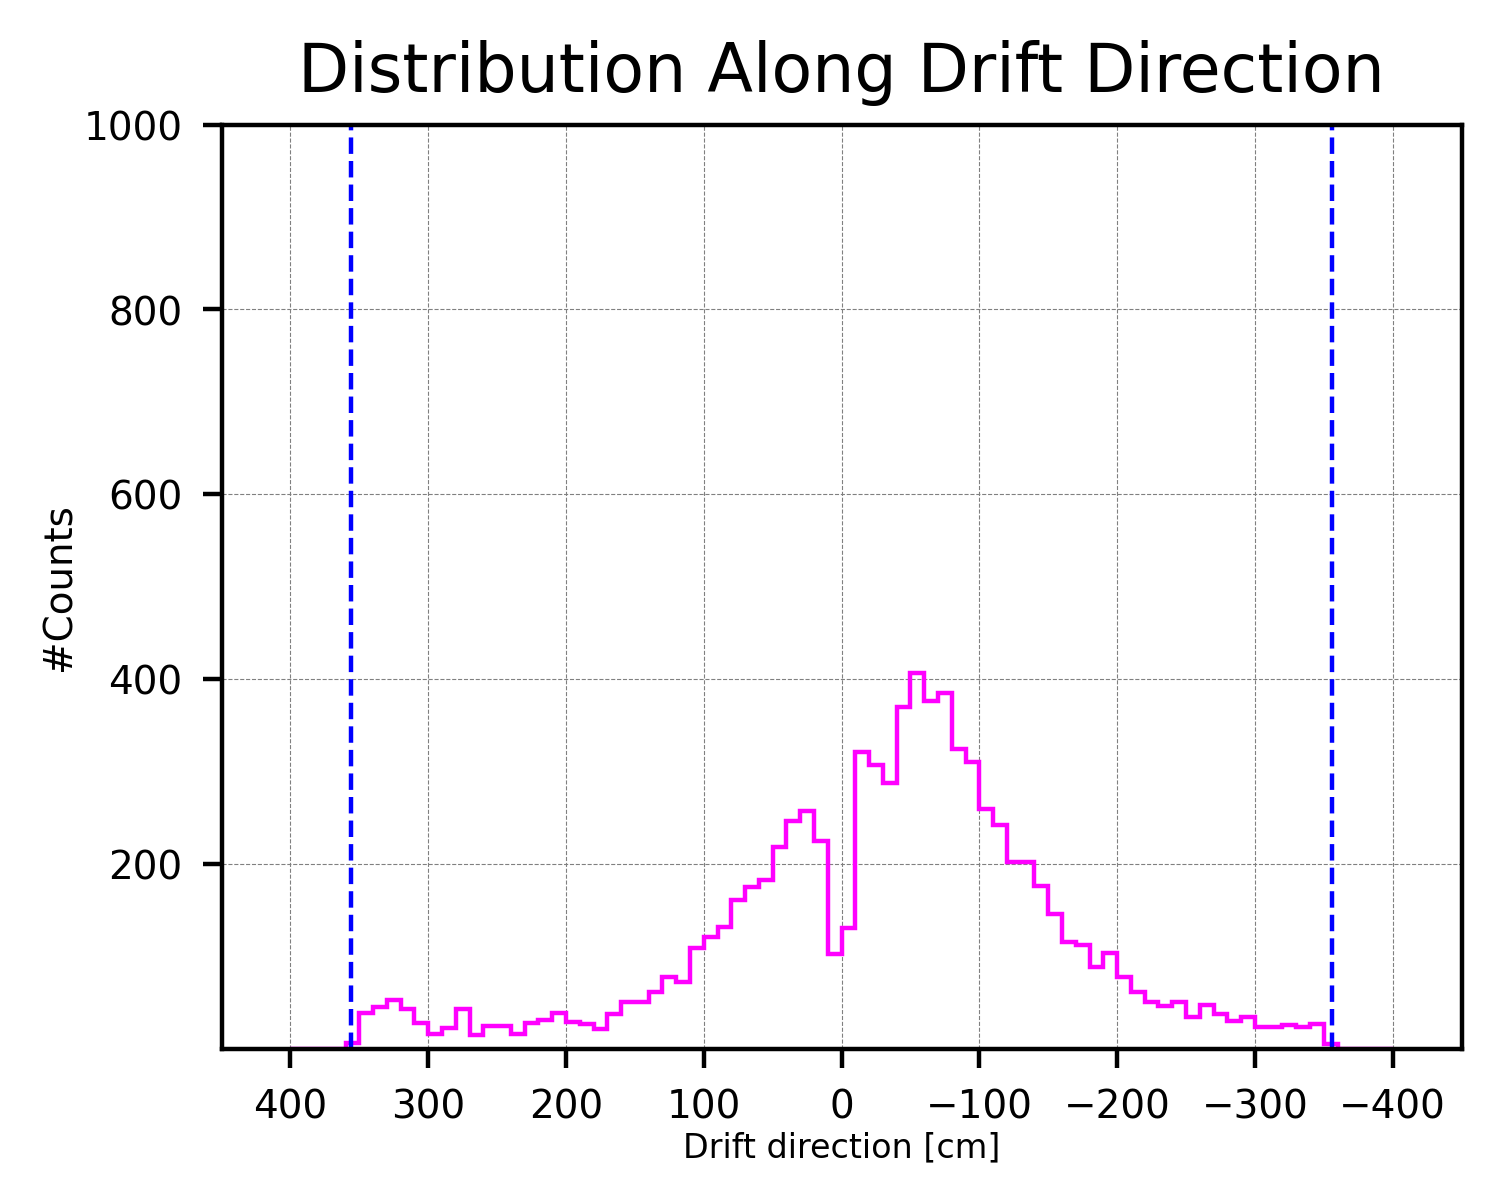

In [9]:
posX = [ev.posX for ev in events_reco_initial]
posY = [ev.posY for ev in events_reco_initial]
posZ = [ev.posZ for ev in events_reco_initial]




#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posX, posY, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(posZ, posX, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()








#Decay points distribution:==================================================================
print("\nDecay points distribution (TPC & #opWvf cuts): ")

posX = np.array(posX)
neg_X = np.sum(posX < 0)
pos_X = np.sum(posX >= 0)
print("# of X < 0 : ", neg_X, "({:.2f}%)".format(neg_X/len(posX)*100))
print("# of X >= 0: ", pos_X, "({:.2f}%)".format(pos_X/len(posX)*100))      




#============================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(posX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

#APA planes---
plt.plot([-356, -356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 10000], color="blue", linewidth=0.8, linestyle='--')


plt.xlim(-450, 450)
plt.xlabel('Drift direction [cm]', labelpad=1, fontsize=6)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylabel('#Counts', labelpad=1, fontsize=7)
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution Along Drift Direction', fontsize=12)
plt.show()  






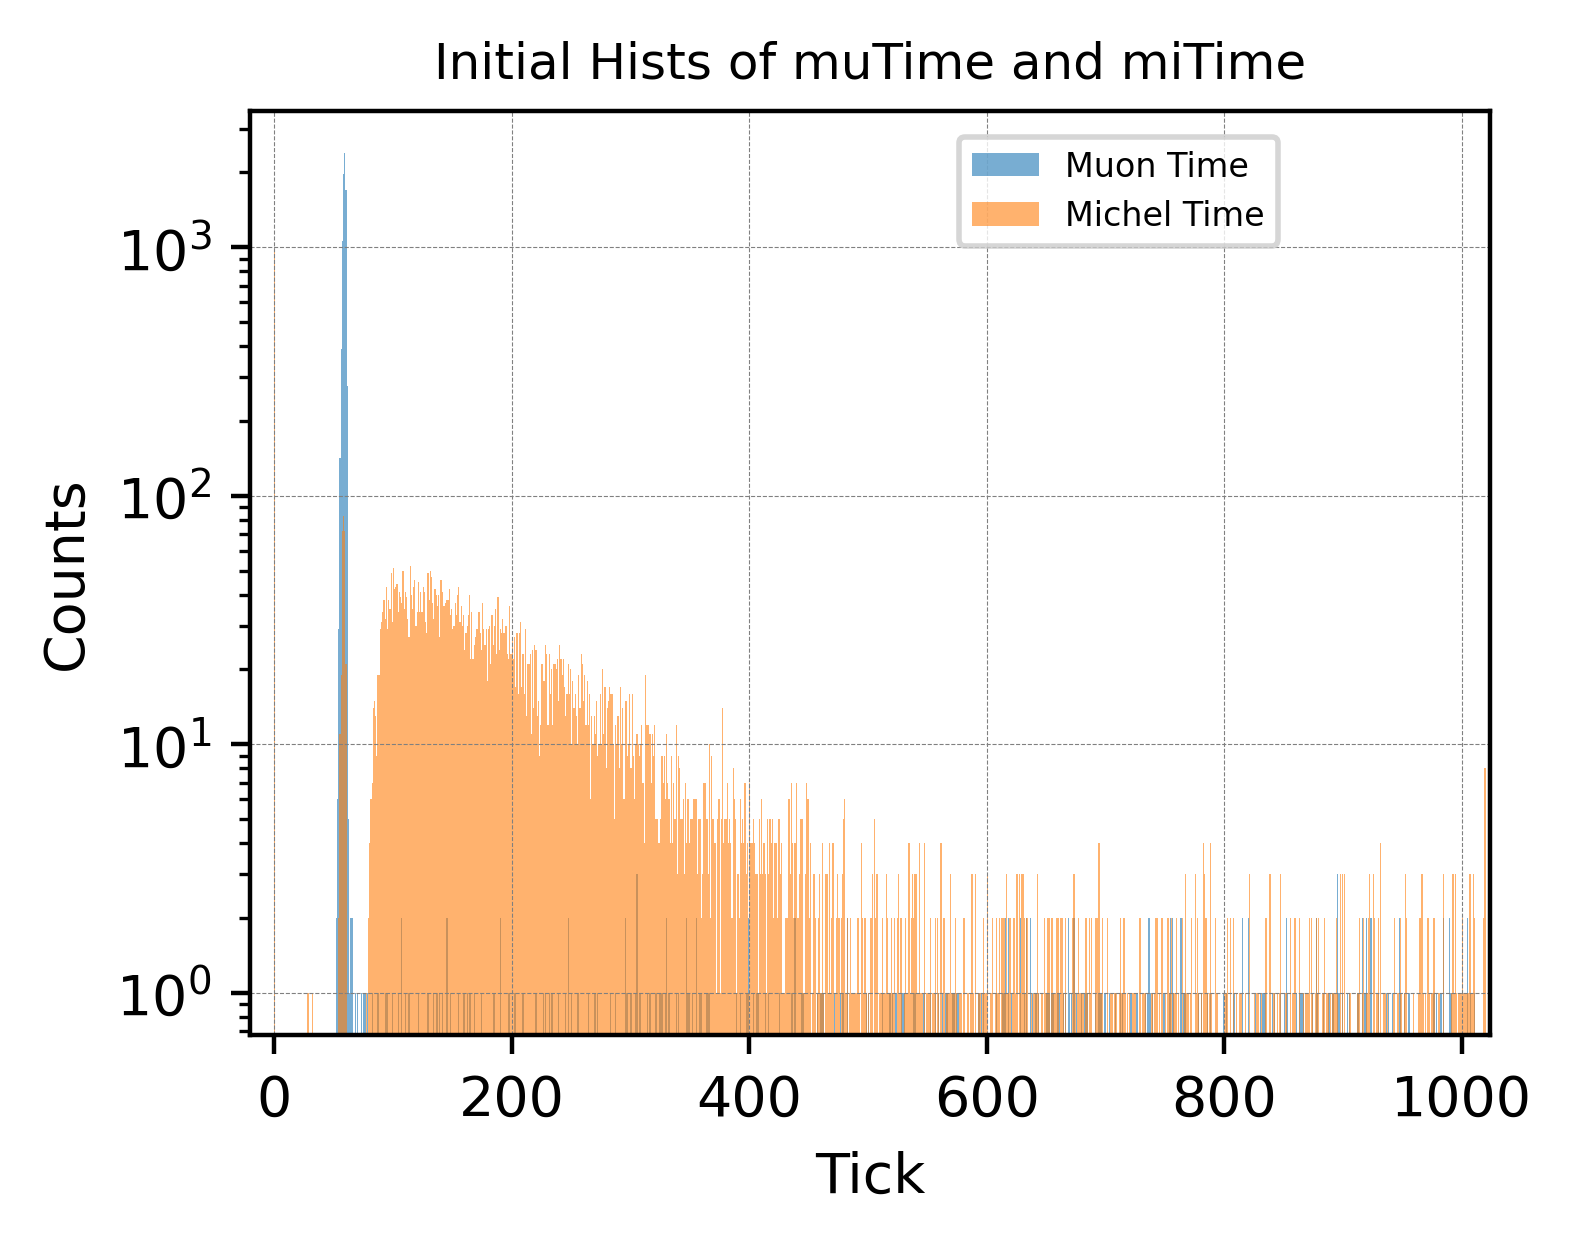

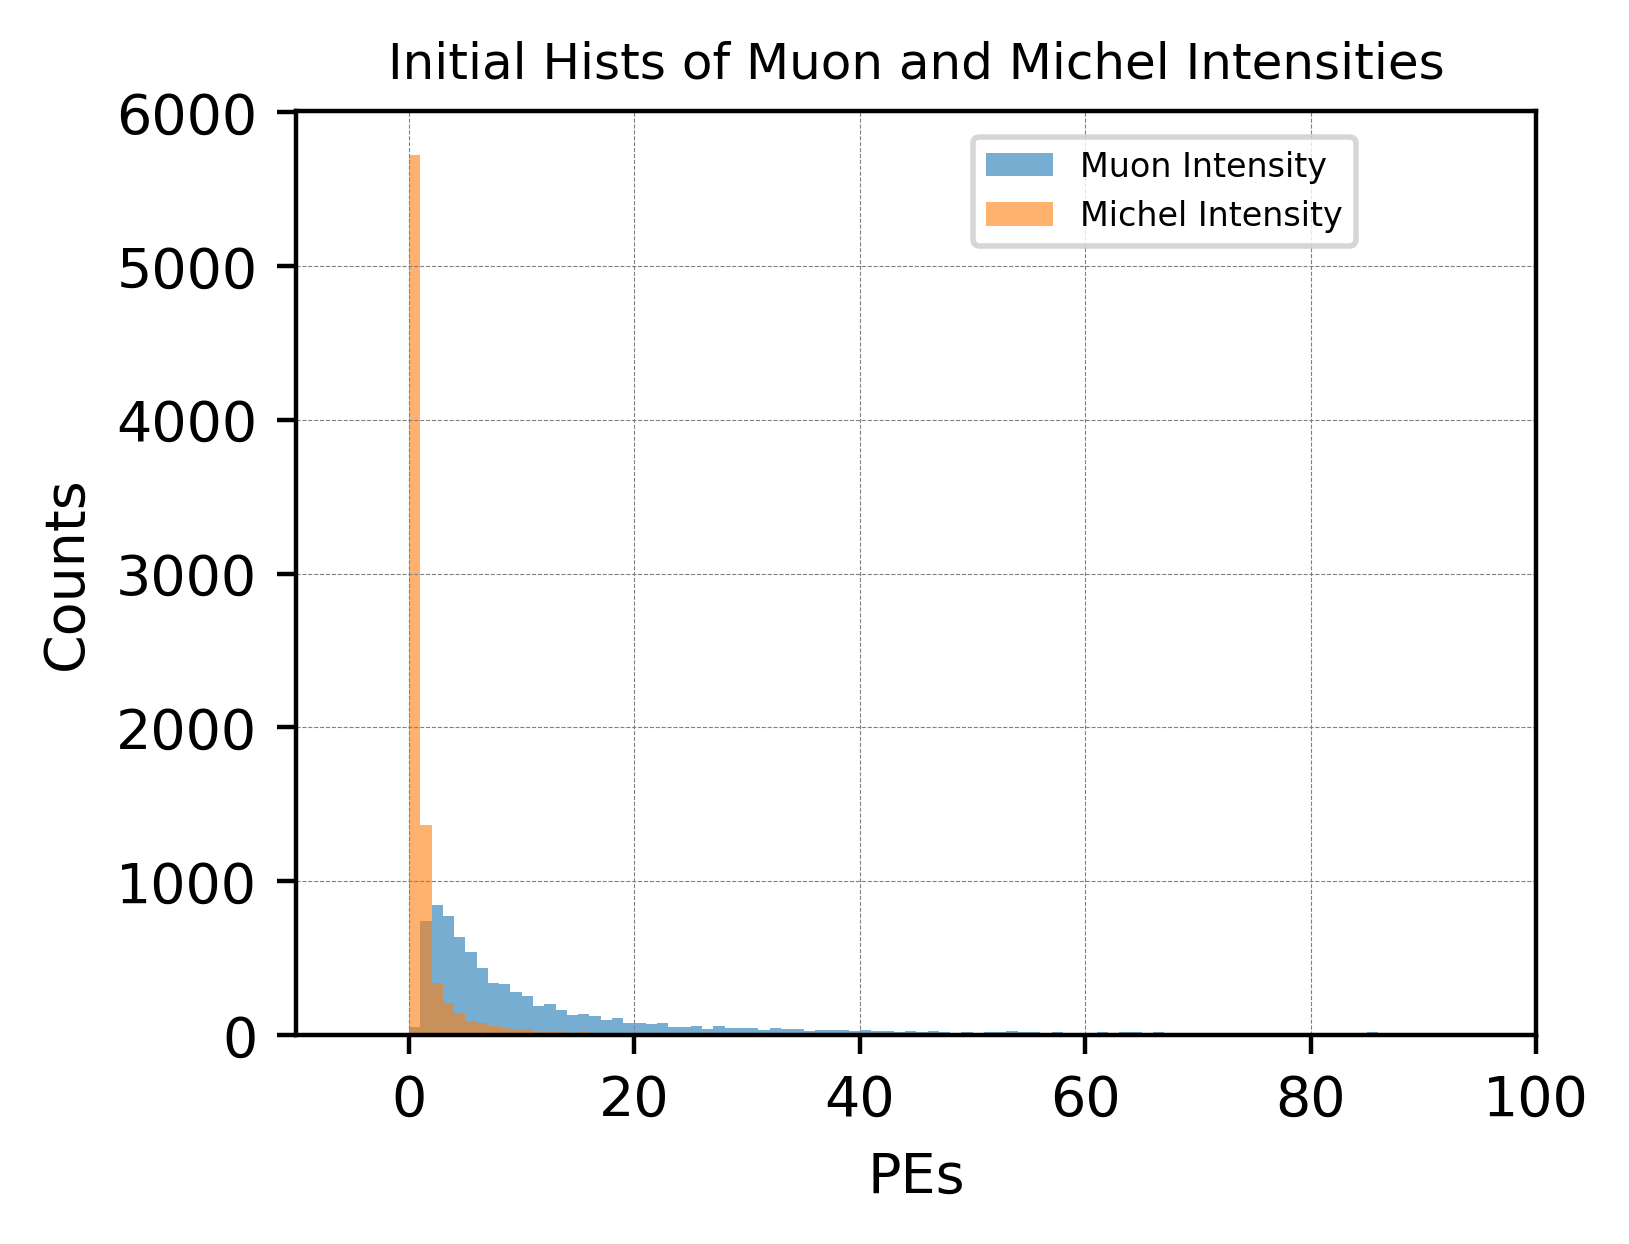

In [16]:
muon_time = [ev.muon_time for ev in events_reco_initial]
michel_time = [ev.michel_time for ev in events_reco_initial]

muon_intensity = [ev.muon_intensity for ev in events_reco_initial]
michel_intensity = [ev.michel_intensity for ev in events_reco_initial]



#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 1  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()




#Initial Mu and Michel intensity distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muon_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('PEs')
plt.ylabel('Counts')
#plt.yscale('log')
plt.xlim(-10, 100)
plt.title('Initial Hists of Muon and Michel Intensities', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









 





<br />
<br />
<br />
<br />


### Purification / cut 2: remove abnormal muon signals (constrain muTime to [50, 65])

Muon events selection (mu peak constrained to [50, 65]):
Updated Muon events:  7987 (96.41%)
Length of time_difference (Updated):  7987


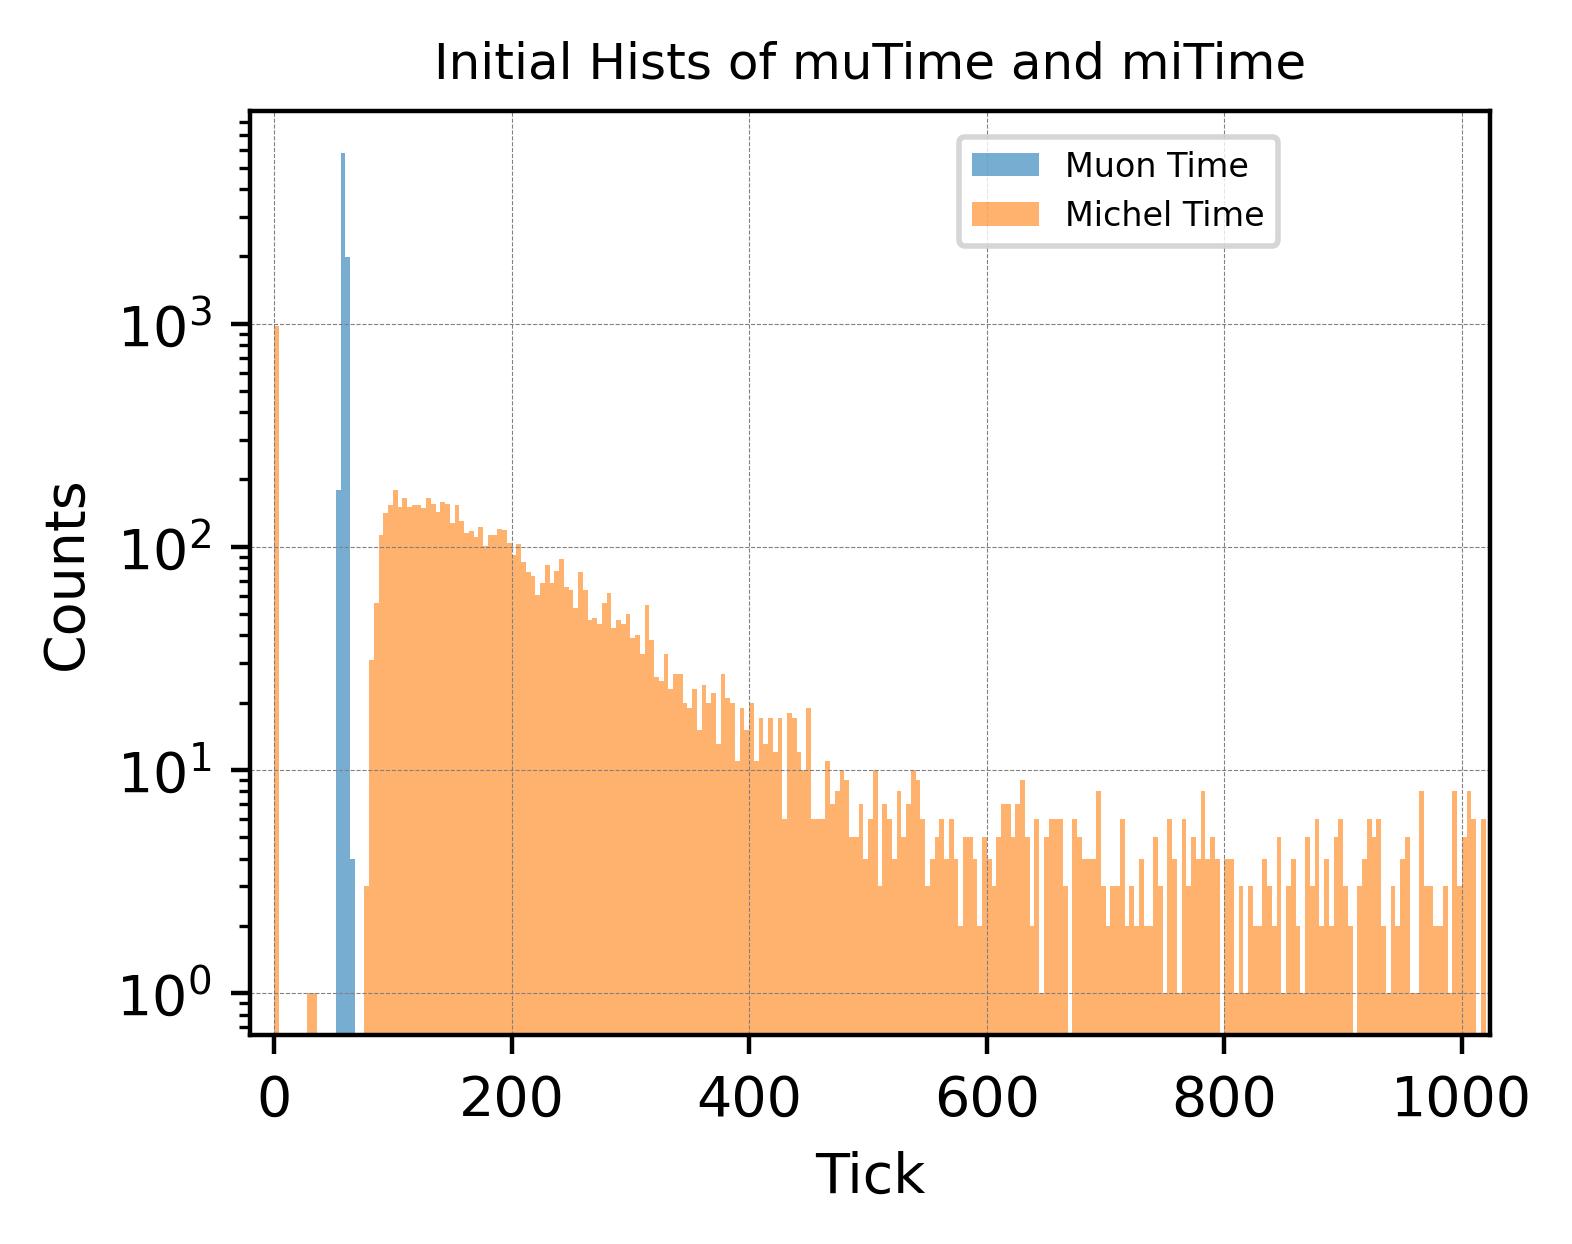




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  7987


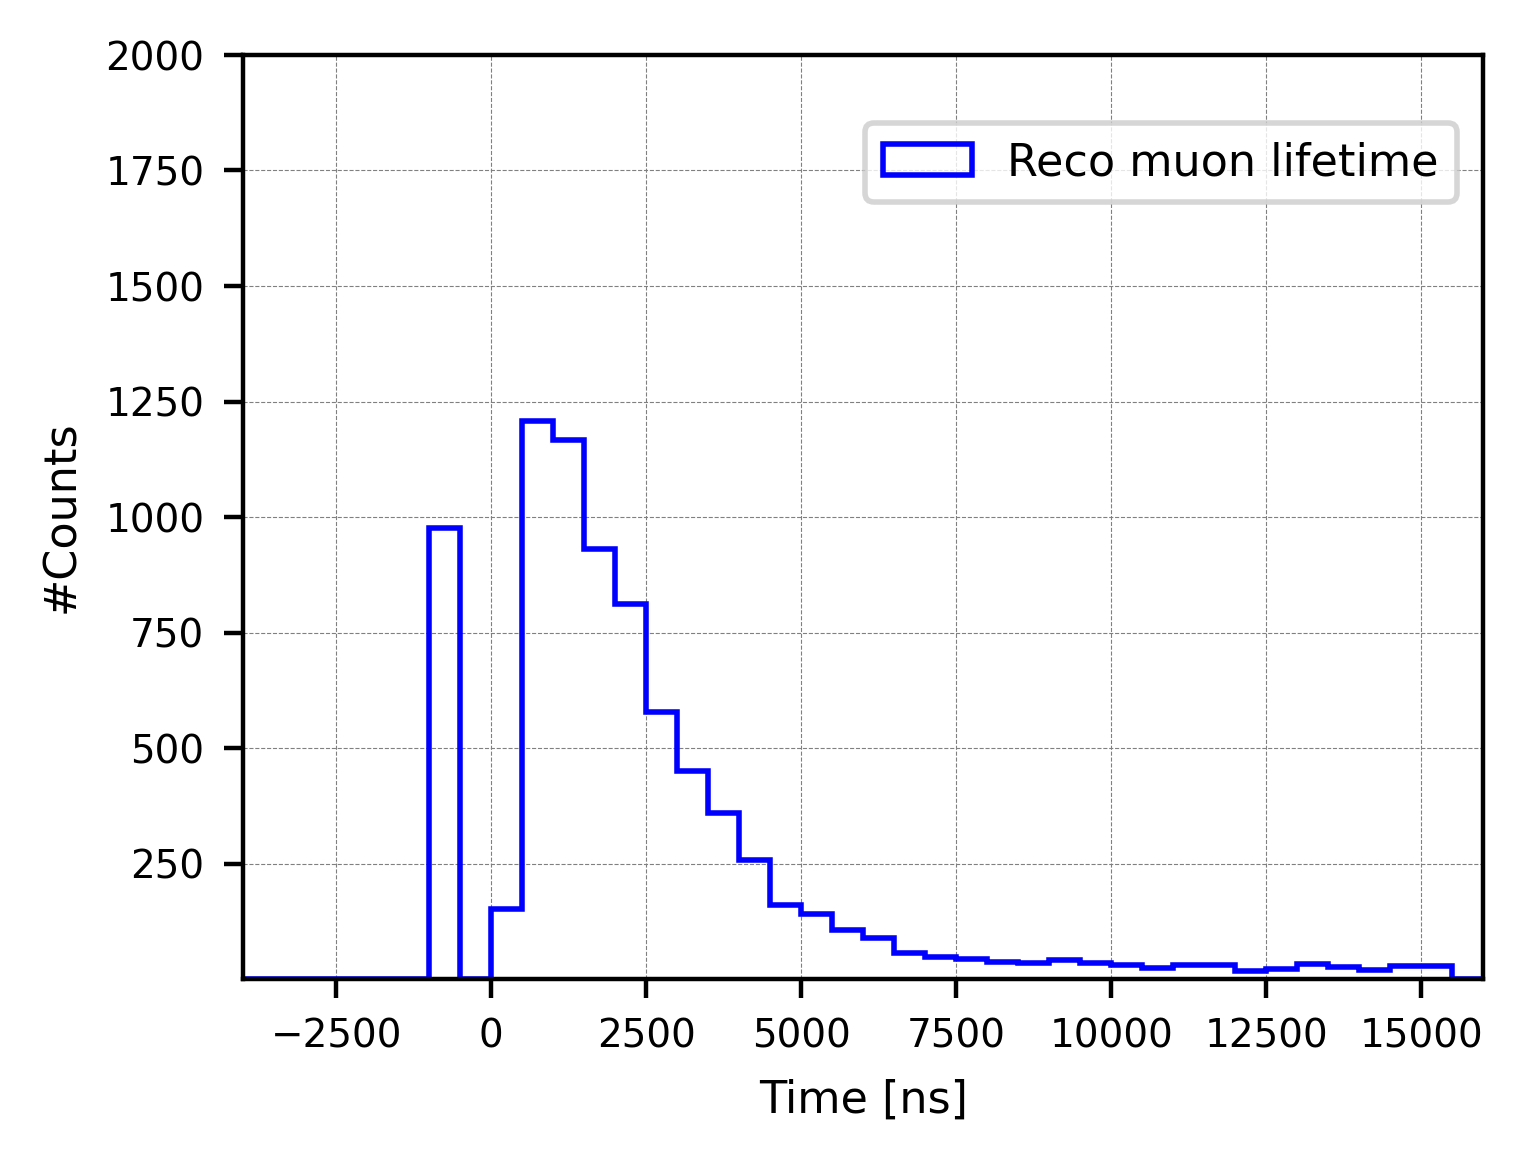

In [19]:
events_reco_update1 = []

lifetime_reco_update1 = []

for ev in events_reco_initial:
    muTime = ev.muon_time
    miTime = ev.michel_time

    if 50 <= muTime <= 65:
        events_reco_update1.append(ev)
        t = miTime-muTime
        lifetime_reco_update1.append(t)



print("Muon events selection (mu peak constrained to [50, 65]):")
print("Updated Muon events: ", len(events_reco_update1),
       "({:.2f}%)".format(len(events_reco_update1)/len(events_reco_initial)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
print("Length of time_difference (Updated): ", len(lifetime_reco_update1))









#Initial Mu and Michel time distributions=================================================
plt.figure(figsize=(4,3),dpi=400)

muTime_update = [ev.muon_time for ev in events_reco_update1]
miTime_update = [ev.michel_time for ev in events_reco_update1]


# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value; default: 4
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-20, 1024)
plt.title('Initial Hists of muTime and miTime', fontsize=9)

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()









# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
timdeDiff_update_ns = [value * 16 for value in lifetime_reco_update1]#reco lifetime---



print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(timdeDiff_update_ns))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(timdeDiff_update_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(-4000, 16000)
plt.ylim(0.9, 2000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






<br />
<br />
<br />
<br />


### Purification / cut 3: remove events with unphysical lifetime (constrain lifetime to [500, inf))

#### (20251022): lifetime cut should be >0 here (we know later that 500 is NOT a good standard)




Lifetime distribution (Updated):
# Updated Candidates [0, 16000]:  7009


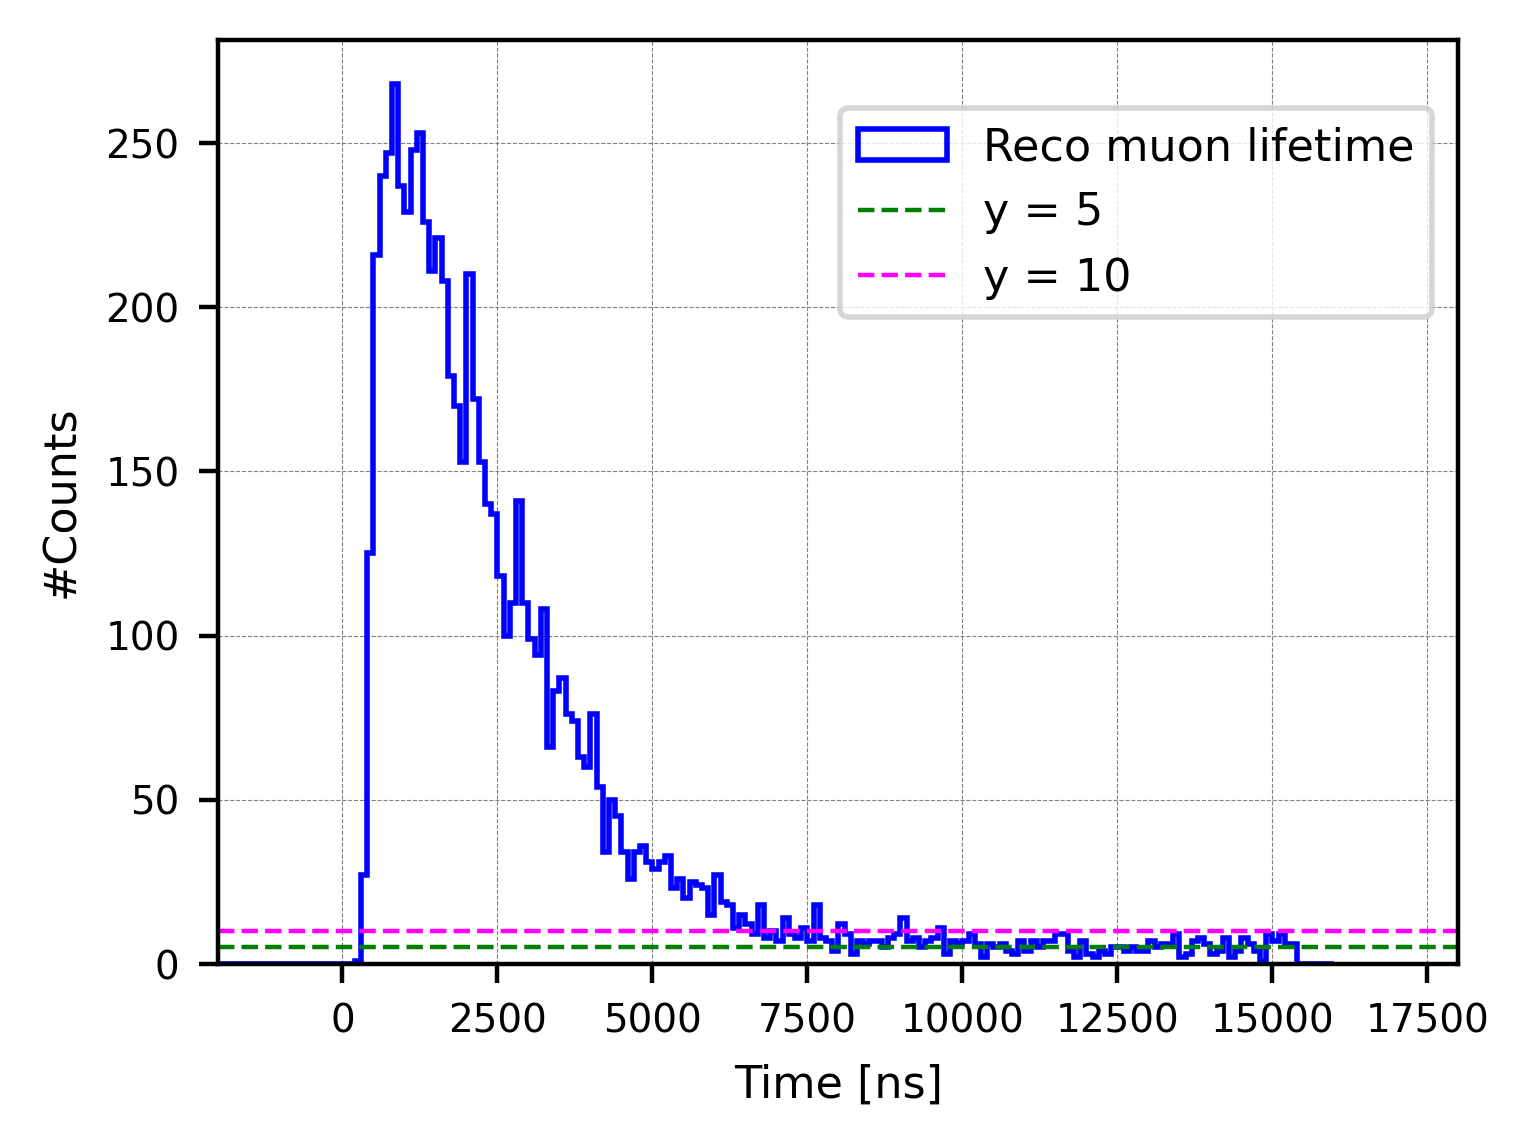

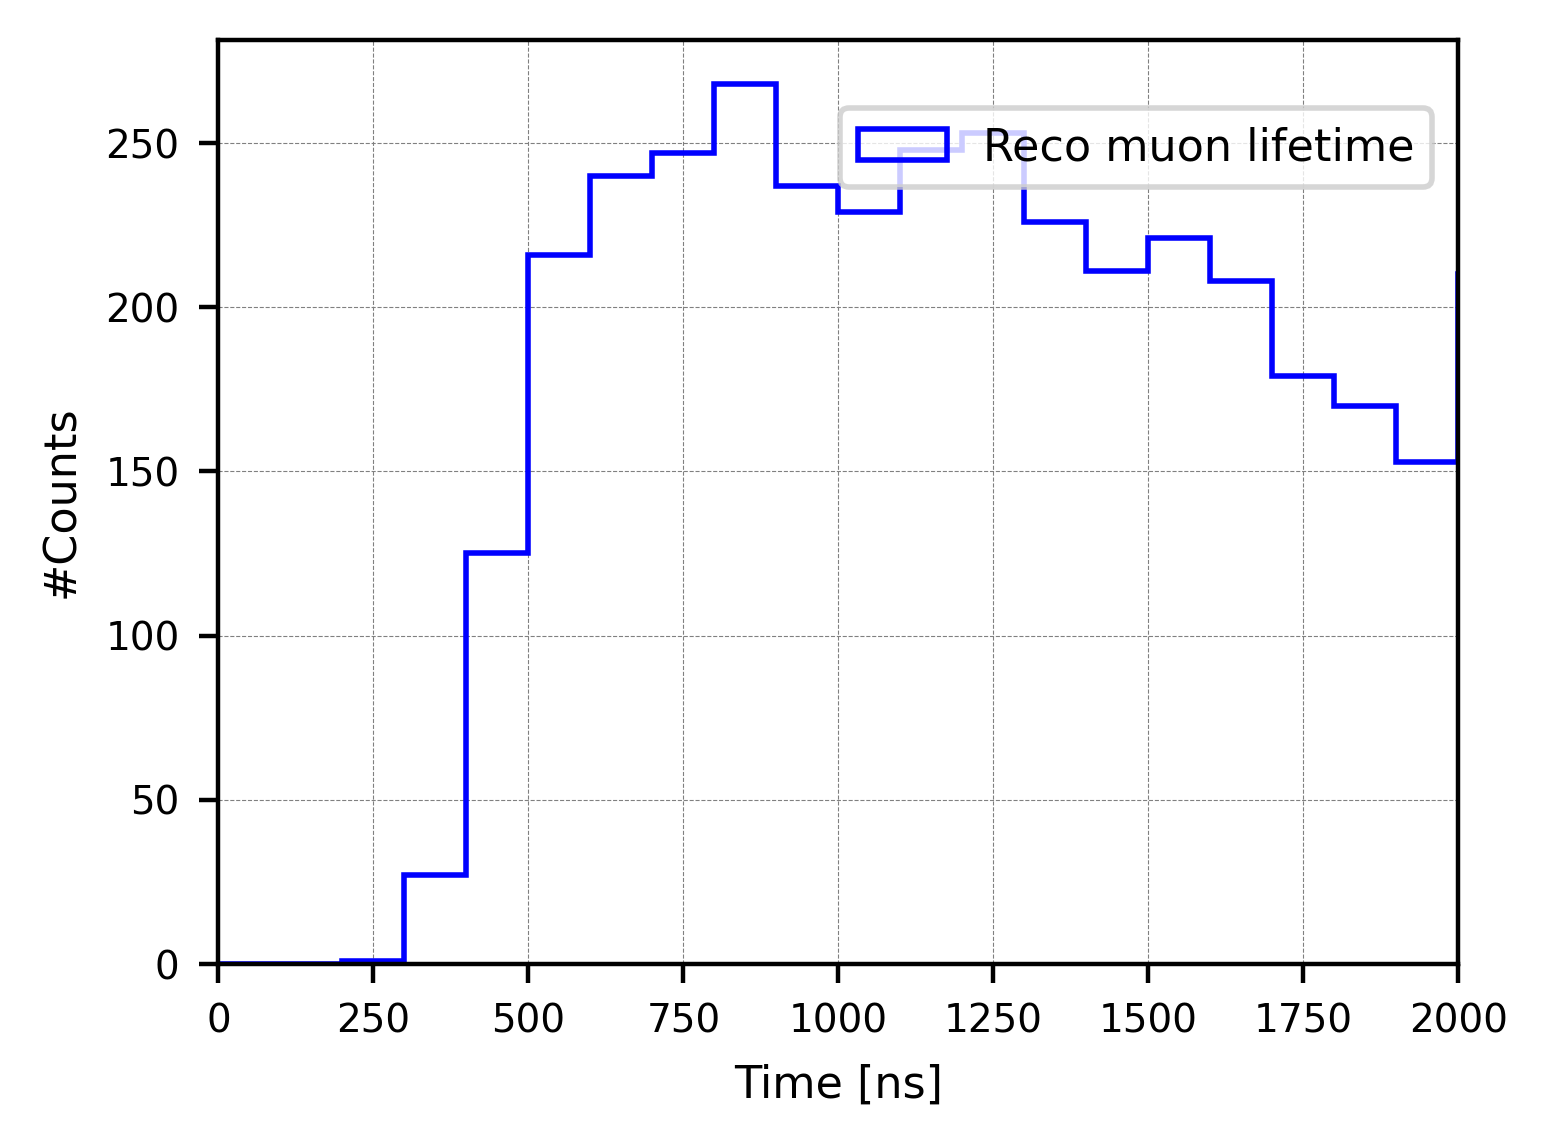

In [27]:
events_reco_update2 = []#Dataset after Purification 2---
lifetime_reco_update2 = []

for ev in events_reco_update1:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    if 0 <= timeDiff: #keep physical events here---
        events_reco_update2.append(ev)
        lifetime_reco_update2.append(timeDiff)


print("\n\n\nLifetime distribution (Updated):")
print("# Updated Candidates [0, 16000]: ", len(events_reco_update2))






# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.plot([-2000, 20000], [5, 5], color="green", linewidth=0.8, linestyle='--', label='y = 5')
plt.plot([-2000, 20000], [10, 10], color="magenta", linewidth=0.8, linestyle='--', label='y = 10')

plt.xlim(-2000, 18000)
#plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# zoomed-in plot--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)


# Define histogram parameters
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(lifetime_reco_update2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')



plt.xlim(0, 2000)
#plt.ylim(0, 1500)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.74, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()



### Preliminary Lifetime fittings:

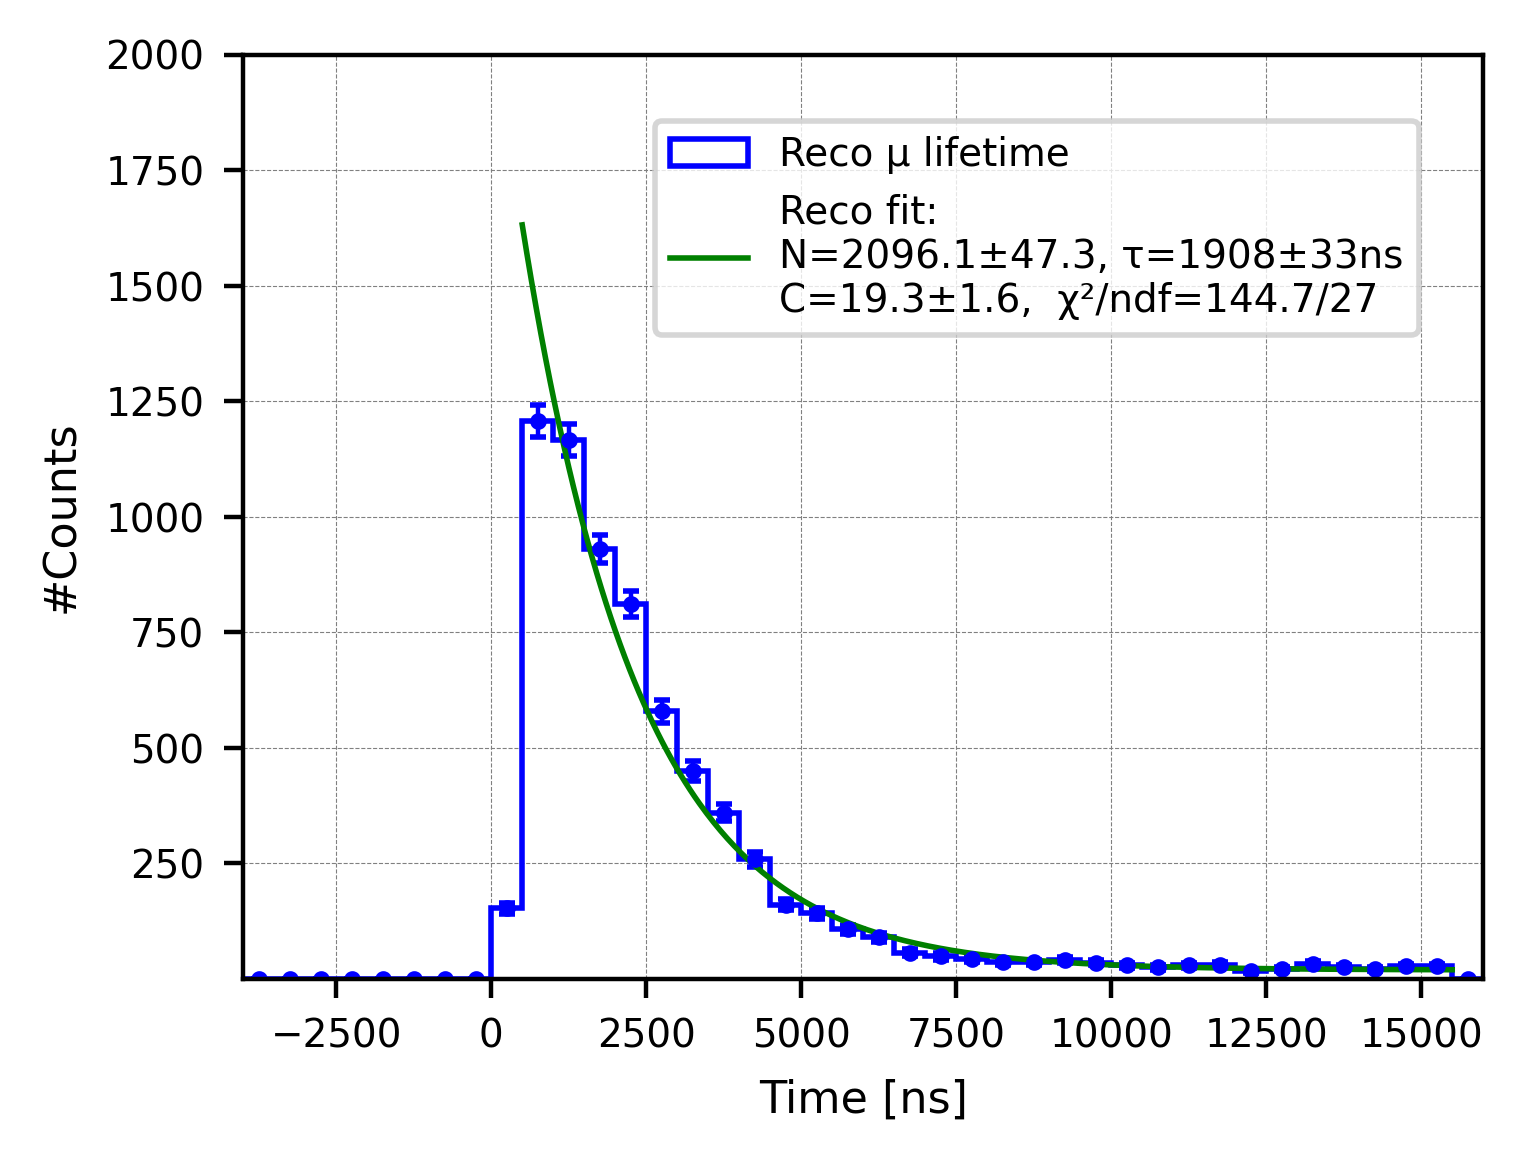

In [29]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt



#======Single Fitting==================================================
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histograms (Reco + True, but error bars only for Reco)
counts_reco, bin_edges_reco, _ = plt.hist(
    lifetime_reco_update2, bins=bins, range=(range_min, range_max),
    edgecolor='blue', histtype='step', linewidth=1.0,
    label='Reco μ lifetime'
)

# Add error bars for Reco
bin_centers_reco = 0.5 * (bin_edges_reco[:-1] + bin_edges_reco[1:])
errors_reco = np.sqrt(np.clip(counts_reco, 0, None))
plt.errorbar(
    bin_centers_reco, counts_reco, yerr=errors_reco,
    fmt='o', color='blue', markersize=2.0, elinewidth=0.8, capsize=1.5,
    label=None  # don’t duplicate legend entry
)


# ---------- add χ² fits with constant background ----------
def exp1C(t, N, tau, C):
    return N * np.exp(-t / tau) + C

def fit_and_overlay(sample, label, fit_min, fit_max, color=None, line_style='-'):
    # Use the SAME binning
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Select fit window
    m = (centers >= fit_min) & (centers <= fit_max)
    x = centers[m]
    y = counts[m].astype(float)

    if len(x) < 3 or y.sum() <= 0:
        print(f"[WARN] Not enough stats to fit {label}")
        return

    # Uncertainty per bin
    sigma = np.sqrt(np.clip(y, 1.0, None))

    # Initial guesses
    N0 = float(y.max())
    tau0 = max(100.0, (np.sum(y * (x - fit_min)) / max(np.sum(y), 1.0)))  # ns
    C0 = min(y)  # background level ~ lowest bin

    # Weighted least squares (χ²)
    popt, pcov = curve_fit(exp1C, x, y, p0=[N0, tau0, C0],
                           sigma=sigma, absolute_sigma=True, maxfev=20000)
    N_fit, tau_fit, C_fit = popt
    N_err, tau_err, C_err = np.sqrt(np.diag(pcov))

    # χ²/ndf
    yfit = exp1C(x, *popt)
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(x) - len(popt), 1)

    # Overlay smooth curve
    t_smooth = np.linspace(fit_min, fit_max, 400)
    plt.plot(
        t_smooth,
        exp1C(t_smooth, *popt),
        line_style,
        linewidth=1.0,
        color=color,
        label=(
            f"{label} fit:\n"
            f"N={N_fit:.1f}±{N_err:.1f}, τ={tau_fit:.0f}±{tau_err:.0f}ns\n"
            f"C={C_fit:.1f}±{C_err:.1f},  χ²/ndf={chi2:.1f}/{ndf}"
        ),
    )


# Fit windows
fit_and_overlay(lifetime_reco_update2, "Reco",  500, 15500, color="green", line_style='-')
#fit_and_overlay(lifetime_update_ns2, "True",     0, 15500, color="magenta")
# ---------- end fits ----------

plt.xlim(-4000, 16000)
plt.ylim(0.1, 2000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=9,
           markerscale=5, ncol=1, prop={'size':7})
plt.show()


<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Explore Dataset After purification 3 [RecoT>0]:

In [31]:
@dataclass
class PdsEventNew: #new class containing reco lifetime, true lifetime & diff
    muon_time: Optional[int] = None
    michel_time: Optional[int] = None
    muon_intensity: Optional[float] = None
    michel_intensity: Optional[float] = None
    third_intensity: Optional[float] = None
    posX: Optional[float] = None
    posY: Optional[float] = None
    posZ: Optional[float] = None
    eventID: Optional[int] = None
    trackID: Optional[int] = None
    date: Optional[int] = None 
    michel_score: Optional[float] = None         # ✅ NEW
    michel_hits: Optional[int] = None 
    reco_lifetime: Optional[float] = None
    michel_rise: Optional[float] = None
    michel_drop: Optional[float] = None



#Test print---------------
print("Size of events_reco_update2 (previous class): ", len(events_reco_update2))

#New calculated reco & true lifetime lists:
recoLife_update2 = []

michel_rise_slope = []
michel_drop_slope = []

for ev in events_reco_update2:
    muTime = ev.muon_time
    miTime = ev.michel_time
    timeDiff = (miTime - muTime) * 16 #convert from tick to ns---

    recoLife_update2.append(timeDiff)

    left_slope = ev.mi_leftHeight / (miTime - ev.mi_leftTurn)
    right_slope = ev.mi_rightHeight / (ev.mi_rightTurn - miTime)

#    left_slope = (miTime - ev.mi_leftTurn)
#    right_slope = (ev.mi_rightTurn - miTime)

    michel_rise_slope.append(left_slope)
    michel_drop_slope.append(right_slope)

print("Size of lifetime_reco_update2               : ", len(recoLife_update2))



#Final events with new features----------
events_newClass = []
for ev, reco_life, rise, drop in zip(
    events_reco_update2, 
    recoLife_update2,
    michel_rise_slope,
    michel_drop_slope
    ):
    new_ev = PdsEventNew(
        muon_time=ev.muon_time,
        michel_time=ev.michel_time,
        muon_intensity=ev.muon_intensity,
        michel_intensity=ev.michel_intensity,
        third_intensity=ev.third_intensity,
        posX=ev.posX,
        posY=ev.posY,
        posZ=ev.posZ,
        eventID=ev.eventID,
        trackID=ev.trackID,
        date=ev.date,
        michel_score=ev.michel_score,
        michel_hits=ev.michel_hits, 
        reco_lifetime=reco_life,
        michel_rise=rise,
        michel_drop=drop
    )
    events_newClass.append(new_ev)

print("\nLength of final dataset in format of new class: ", len(events_newClass))




Size of events_reco_update2 (previous class):  7009
Size of lifetime_reco_update2               :  7009

Length of final dataset in format of new class:  7009


### Purification 4:  Michel Intensity / Muon Intensity:

After lifetime cut (cut 3):
# Events:  7009

(michel Intensity) / (muon intensity) (Cut 4):----------
Efficiency (cut4 / cut3):  2334 / 7009 (33.30%)


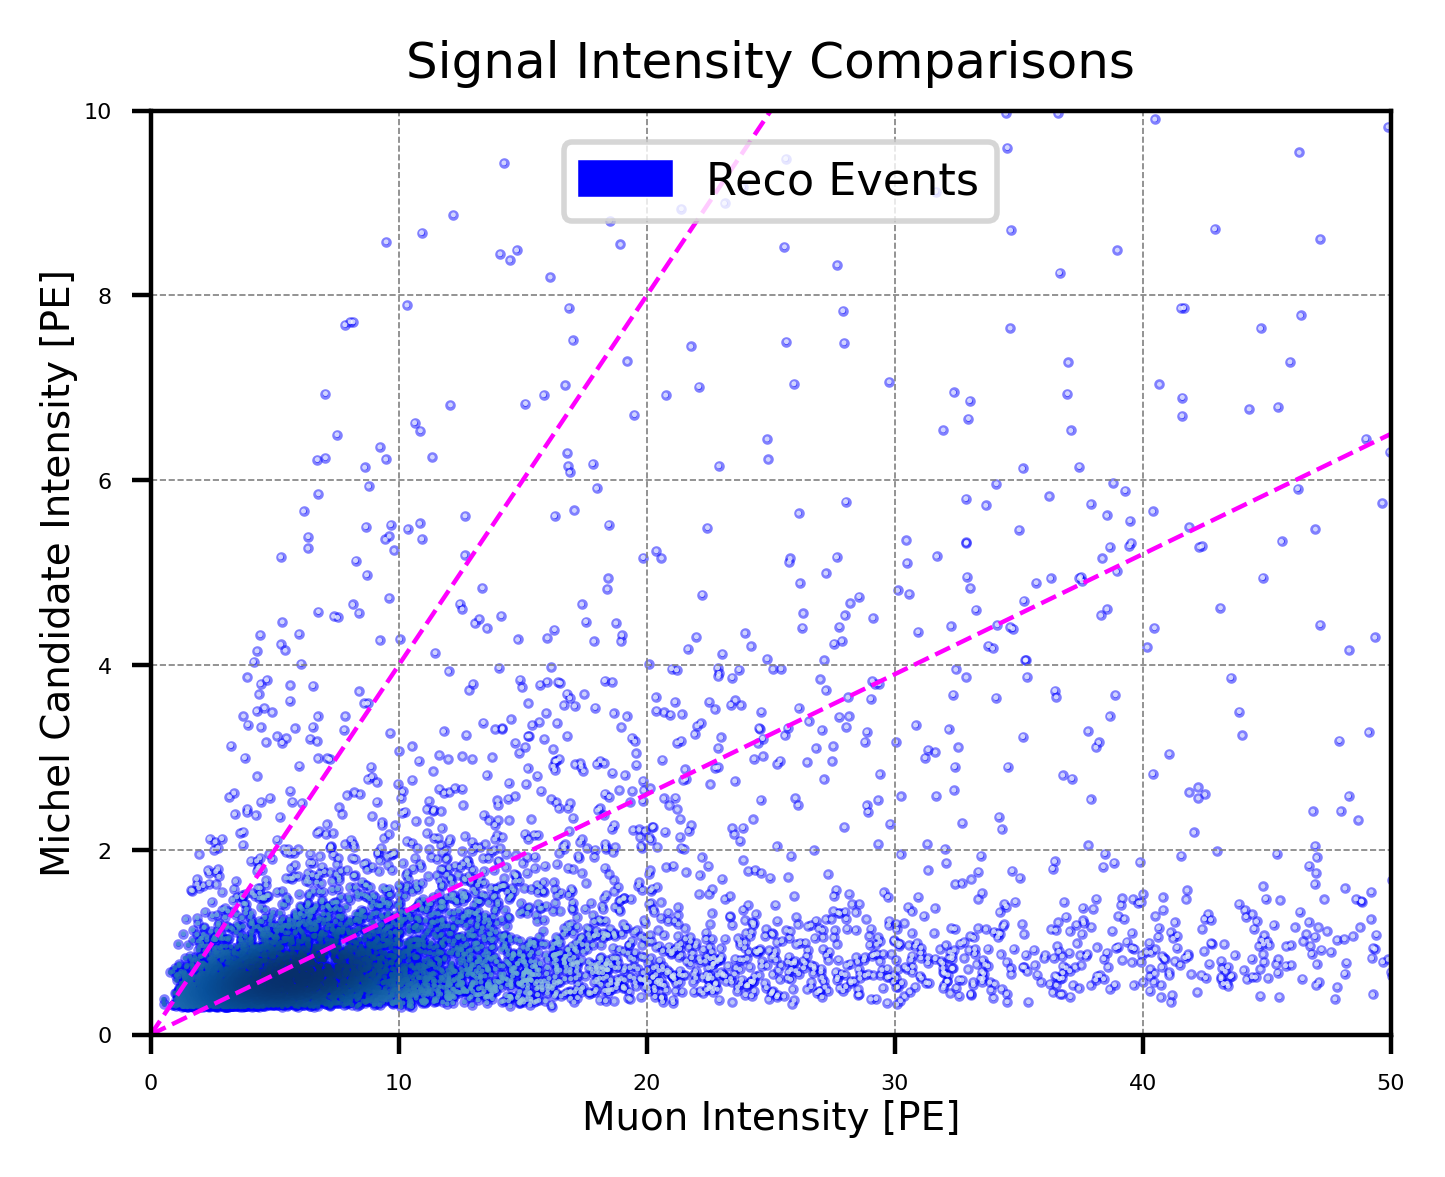


Purify 4----------------------


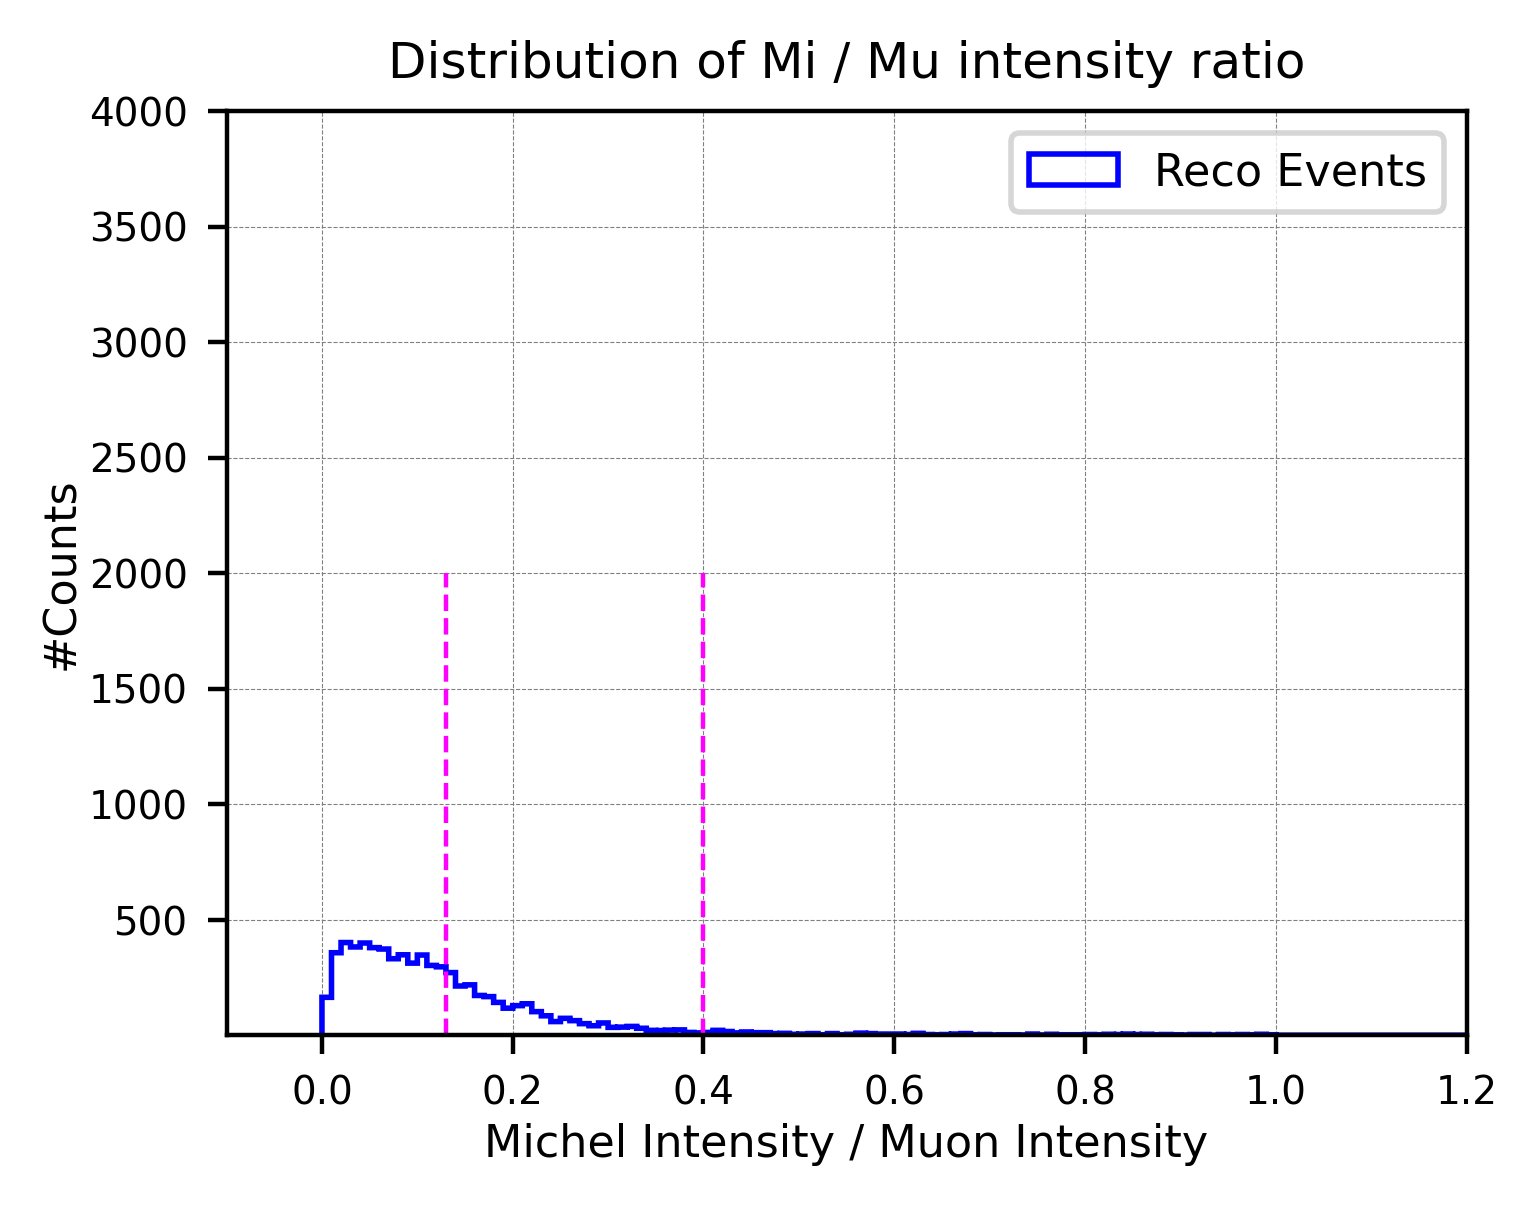

In [38]:
from scipy.stats import gaussian_kde
from matplotlib import colors 
import matplotlib.patches as mpatches

recoLife_diff = [ev.reco_lifetime for ev in events_newClass] #"diff" means nothing, just inherited from MC script
muInt_diff = [ev.muon_intensity for ev in events_newClass]
miInt_diff = [ev.michel_intensity for ev in events_newClass]
X_diff = [ev.posX for ev in events_newClass]









#Michel Intensity Cut (Cut 4)================================================
print("After lifetime cut (cut 3):")

print("# Events: ", len(events_newClass))




thre1 = 6.5 / 50
thre2 = 40 / 100

# filter the actual events
events_total_purify4 = [
    ev for ev in events_newClass
    if ev.muon_intensity != 0 and thre1 < ev.michel_intensity / ev.muon_intensity < thre2
]
#-------------------------------

print("\n(michel Intensity) / (muon intensity) (Cut 4):----------")

print("Efficiency (cut4 / cut3): ", len(events_total_purify4), "/", len(events_newClass),
      "({:.2f}%)".format(len(events_total_purify4)/len(events_newClass)*100))











# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff), np.array(miInt_diff)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 500], [0, 65], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 1000], [0, 400], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 50) #(-5, 400)
plt.ylim(0, 10) #(-5, 60)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()






#Ratio distribution===================================
print("\nPurify 4----------------------")

ratio_diff_purify3 = [mi / mu for mi, mu in zip(miInt_diff, muInt_diff) if mu != 0]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_diff_purify3, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")

plt.plot([0.13, 0.13], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.4, 0.4], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 1.2)
plt.xlabel('Michel Intensity / Muon Intensity', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Mi / Mu intensity ratio', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 



#### Cut 5: Michel intensity & Muon intensity: 

After cut 4:
# Events:  2334

Michel Intensity Cut (Cut 5):--------------
Efficiency (cut5 / cut4):  1042 / 2334 (44.64%)


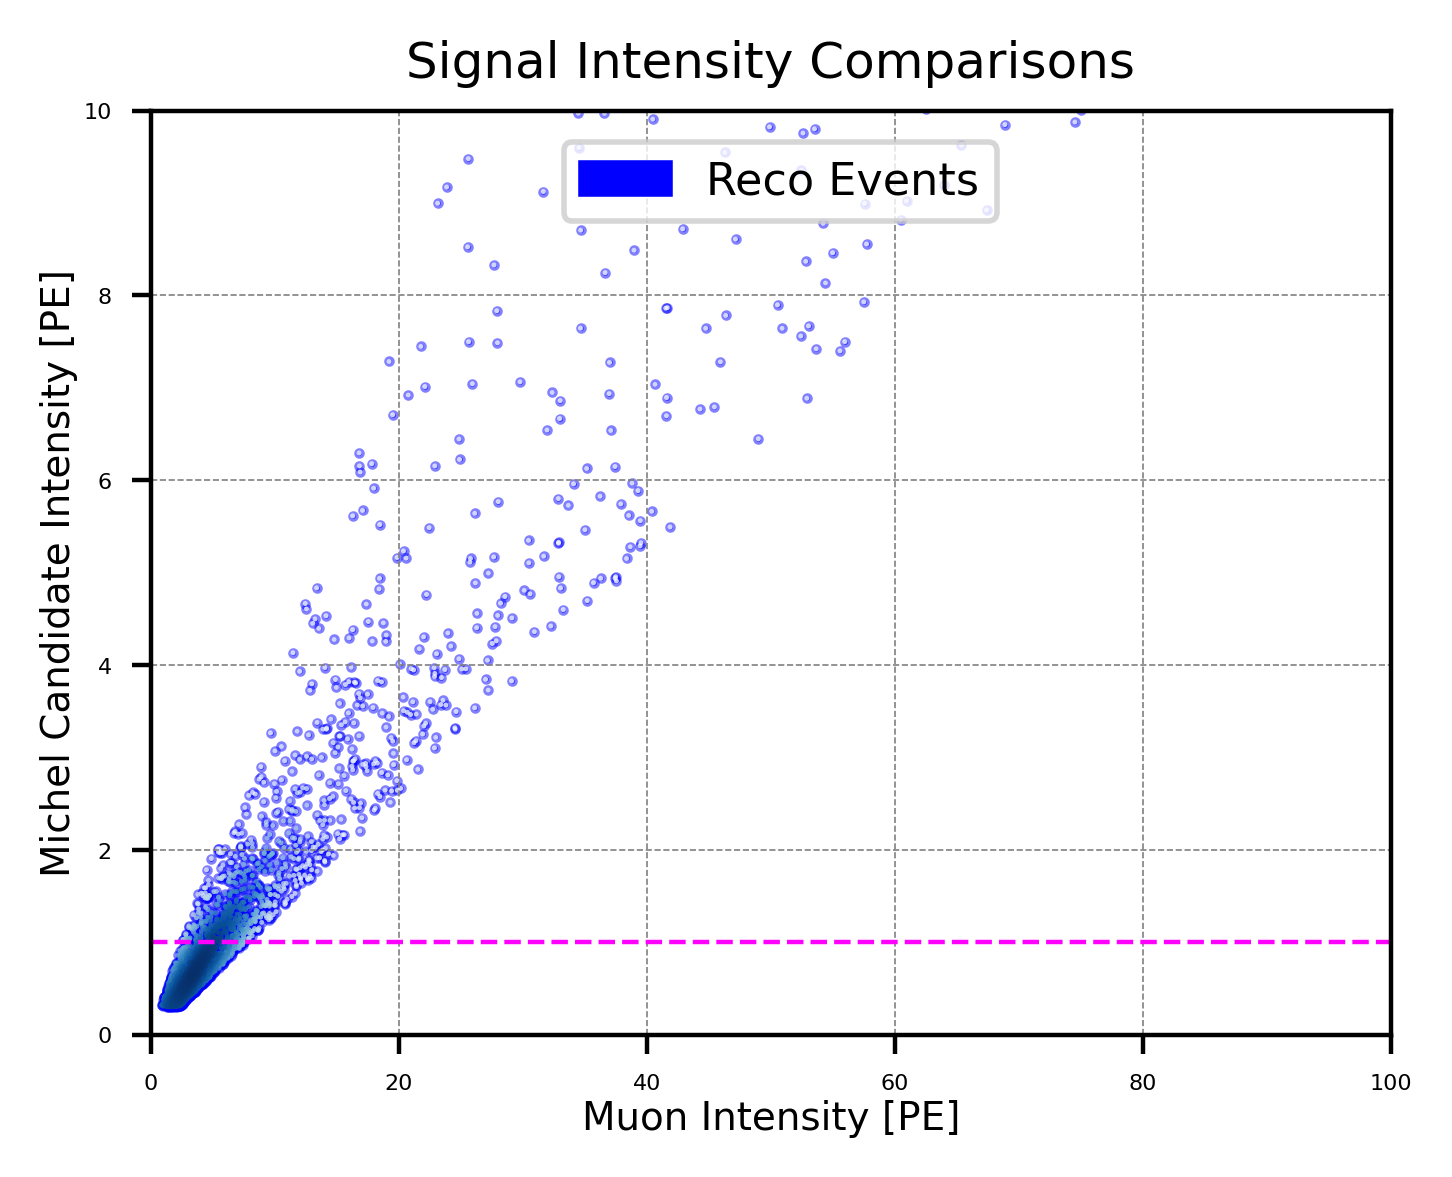


Purify 5----------------------


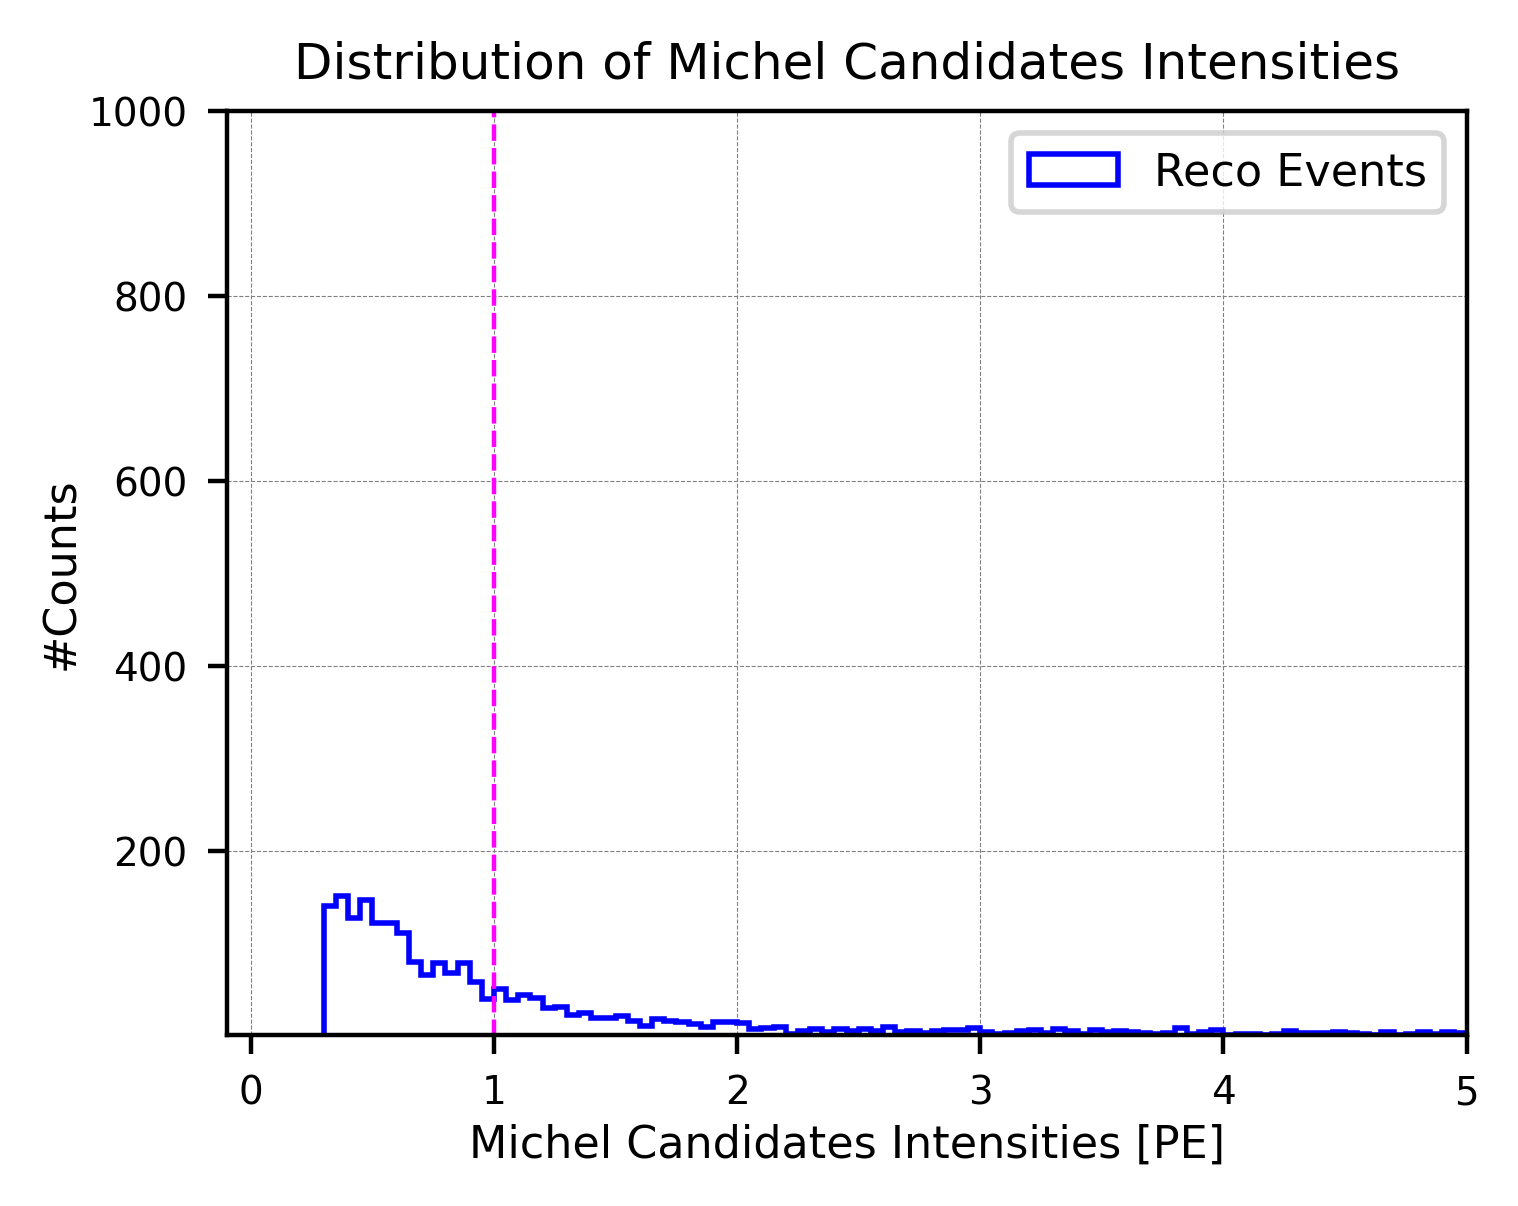

In [40]:
#Michel & Muon Intensities Cut (Cut 5)================================================
print("After cut 4:")

print("# Events: ", len(events_total_purify4))




thre_muInt = 0.3 # mu Int will automatically higher than mi---
thre_miInt = 0.9

# filter the actual events
events_total_purify5 = [
    ev for ev in events_total_purify4
    if thre_miInt < ev.michel_intensity and thre_muInt < ev.muon_intensity
]
#-------------------------------

print("\nMichel Intensity Cut (Cut 5):--------------")

print("Efficiency (cut5 / cut4): ", len(events_total_purify5), "/", len(events_total_purify4),
      "({:.2f}%)".format(len(events_total_purify5)/len(events_total_purify4)*100))








# ==========================================================
# Mu Intensity VS Michel Intensity
# ==========================================================
muInt_diff_purify4 = [ev.muon_intensity for ev in events_total_purify4]
miInt_diff_purify4 = [ev.michel_intensity for ev in events_total_purify4]



plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(muInt_diff_purify4), np.array(miInt_diff_purify4)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Reco Events")

#---------------------------------

plt.plot([0, 100], [1.0, 1.0], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 100)
plt.ylim(0, 10)
plt.xlabel('Muon Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Michel Candidate Intensity [PE]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
red_patch = mpatches.Patch(color="blue", label="Reco Events")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})


plt.show()







#Michel Intensity distribution===================================
print("\nPurify 5----------------------")

#miInt_diff500_purify5 = [ev.michel_intensity for ev in events_diff500_purify5]
#miInt_diff0_purify5 = [ev.michel_intensity for ev in events_diff0_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 10
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(miInt_diff_purify4, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reco Events")

plt.plot([1.0, 1.0], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 5)
plt.xlabel('Michel Candidates Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Michel Candidates Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#### Mu & Michel intensity distributions after Cut 5:

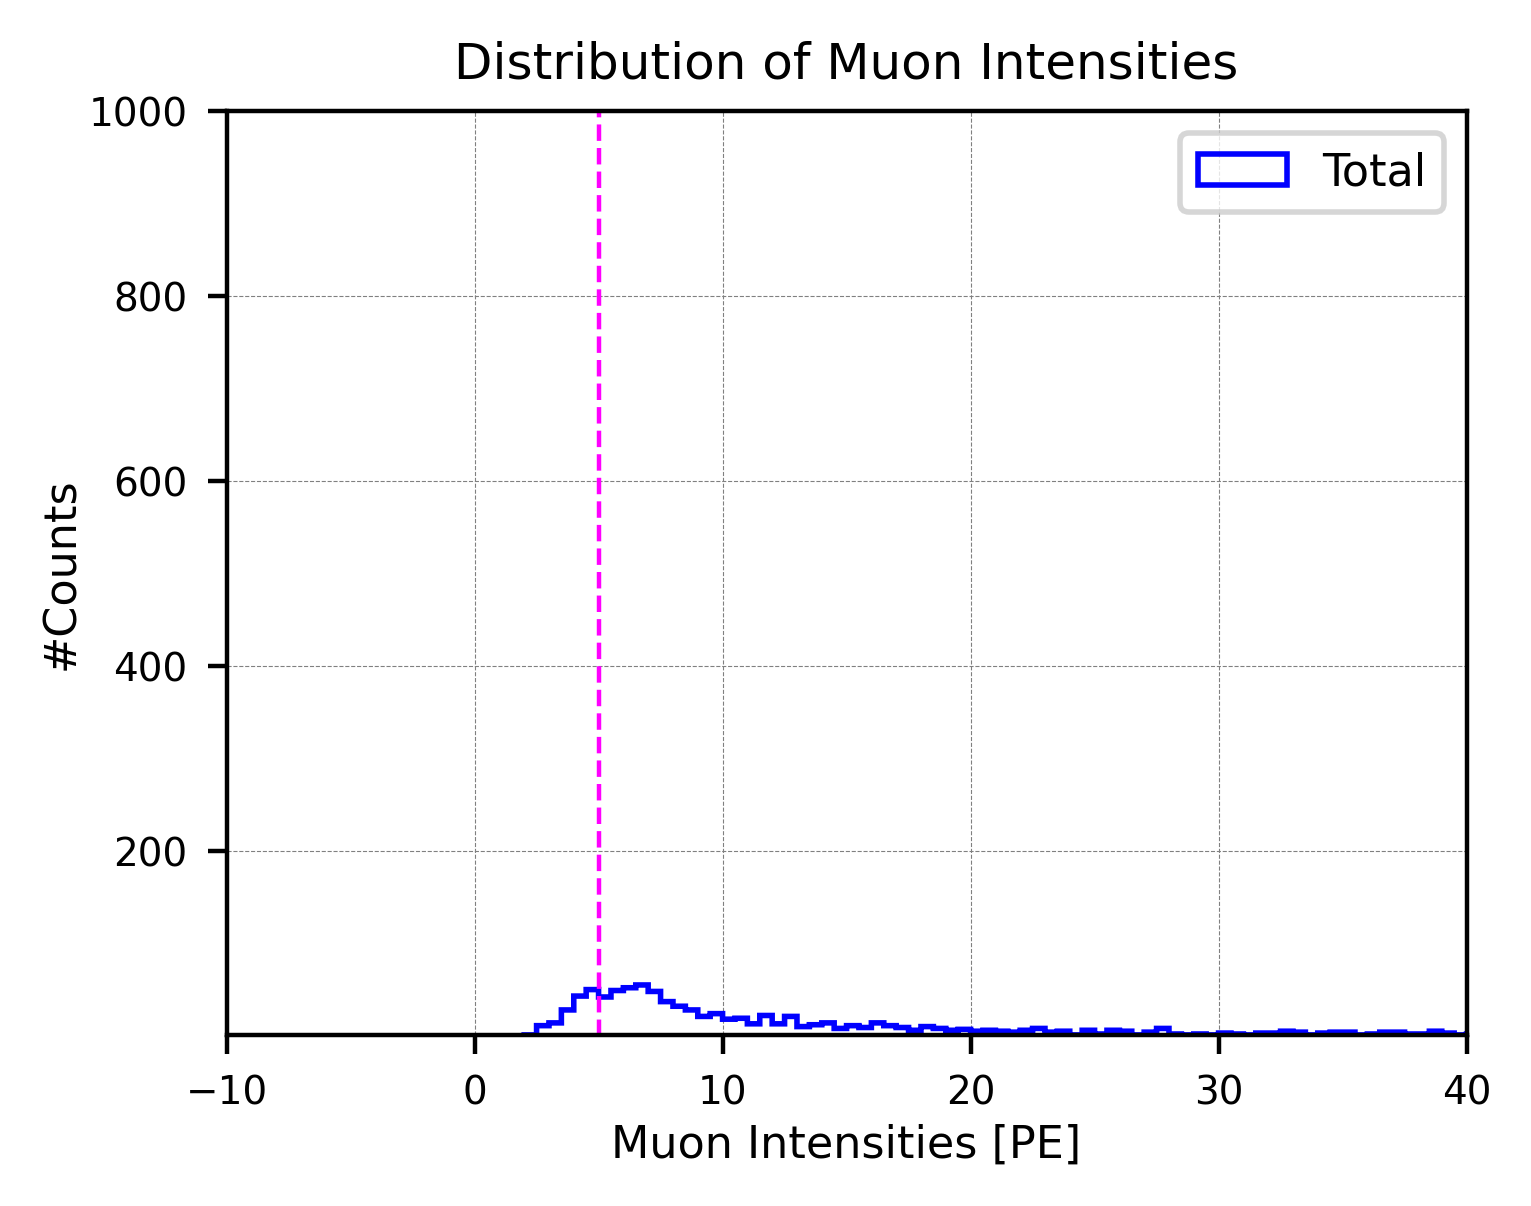

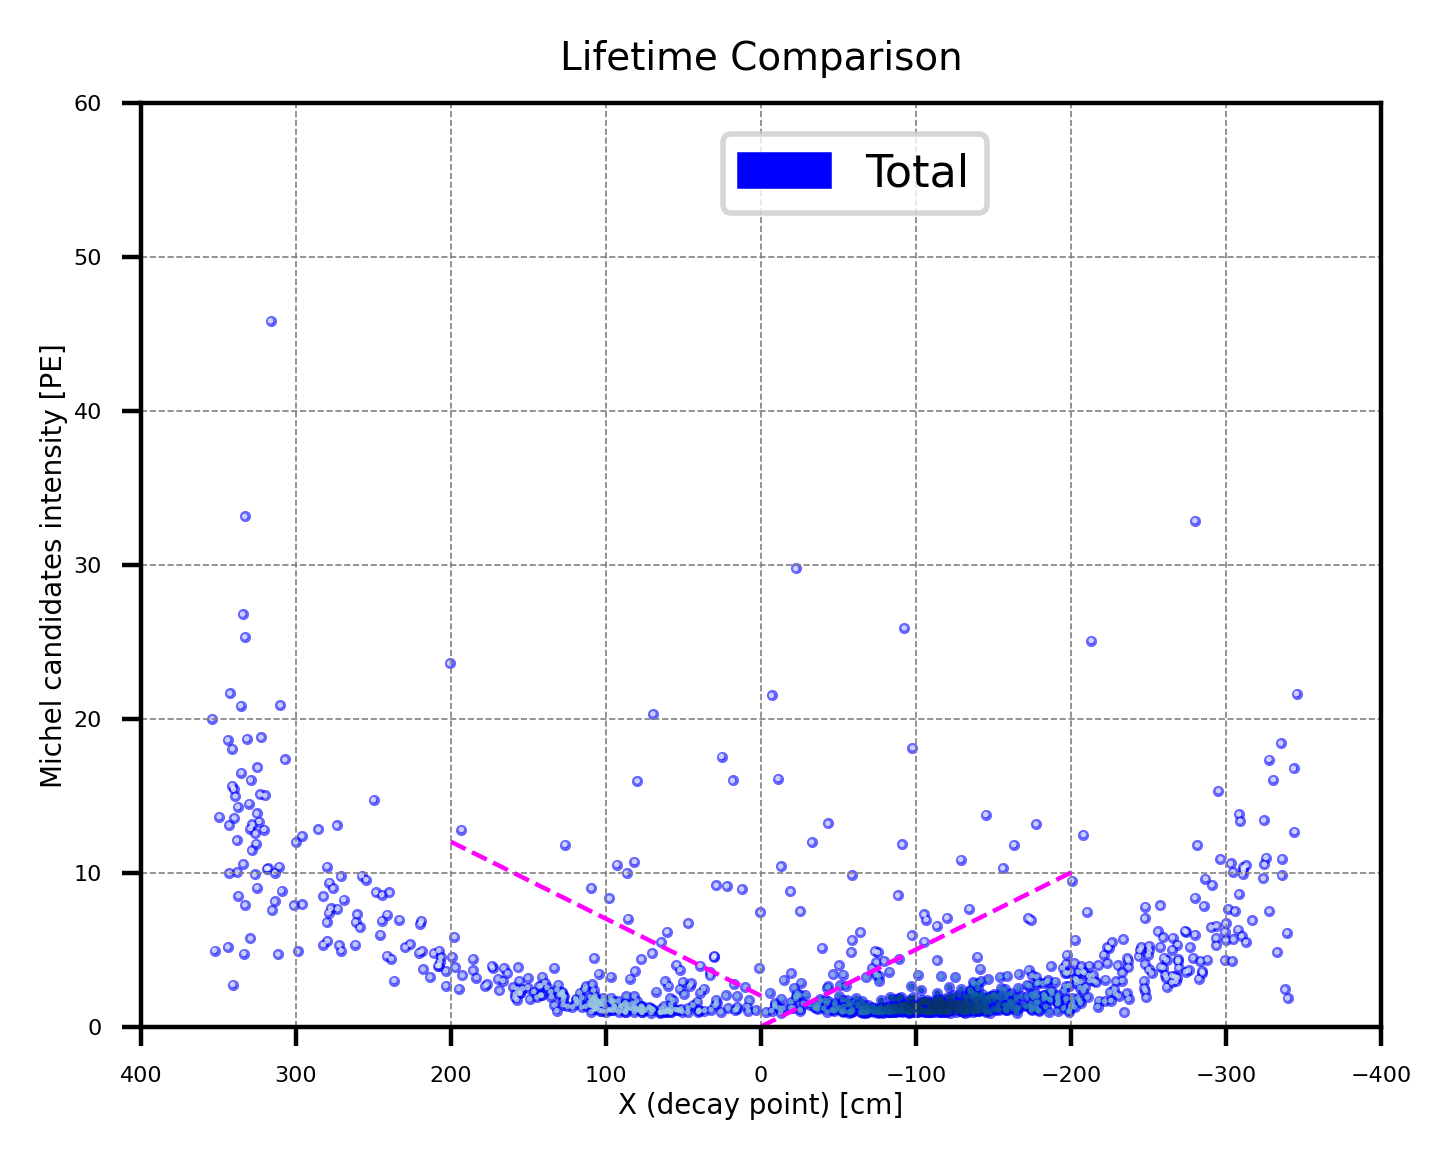

In [59]:
#Muon Intensity distribution===================================

muInt_total_purify5 = [ev.muon_intensity for ev in events_total_purify5]

plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = 0
range_max = 300
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(muInt_total_purify5, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Total")

plt.plot([5, 5], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-10, 40)
plt.xlabel('Muon Intensities [PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Muon Intensities', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 





#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5 = [ev.posX for ev in events_total_purify5]
miInt_total_purify5 = [ev.michel_intensity for ev in events_total_purify5]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5, dtype=float)
y1 = np.array(miInt_total_purify5, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()

#### Cut 5': Michel signal VS Distance cut:

After cut 5:---------
#events:  1042

After Cut 5' (Michel vs Distance):--------------
Efficiency (cut5' / cut5):  955 / 1042 (91.65%)


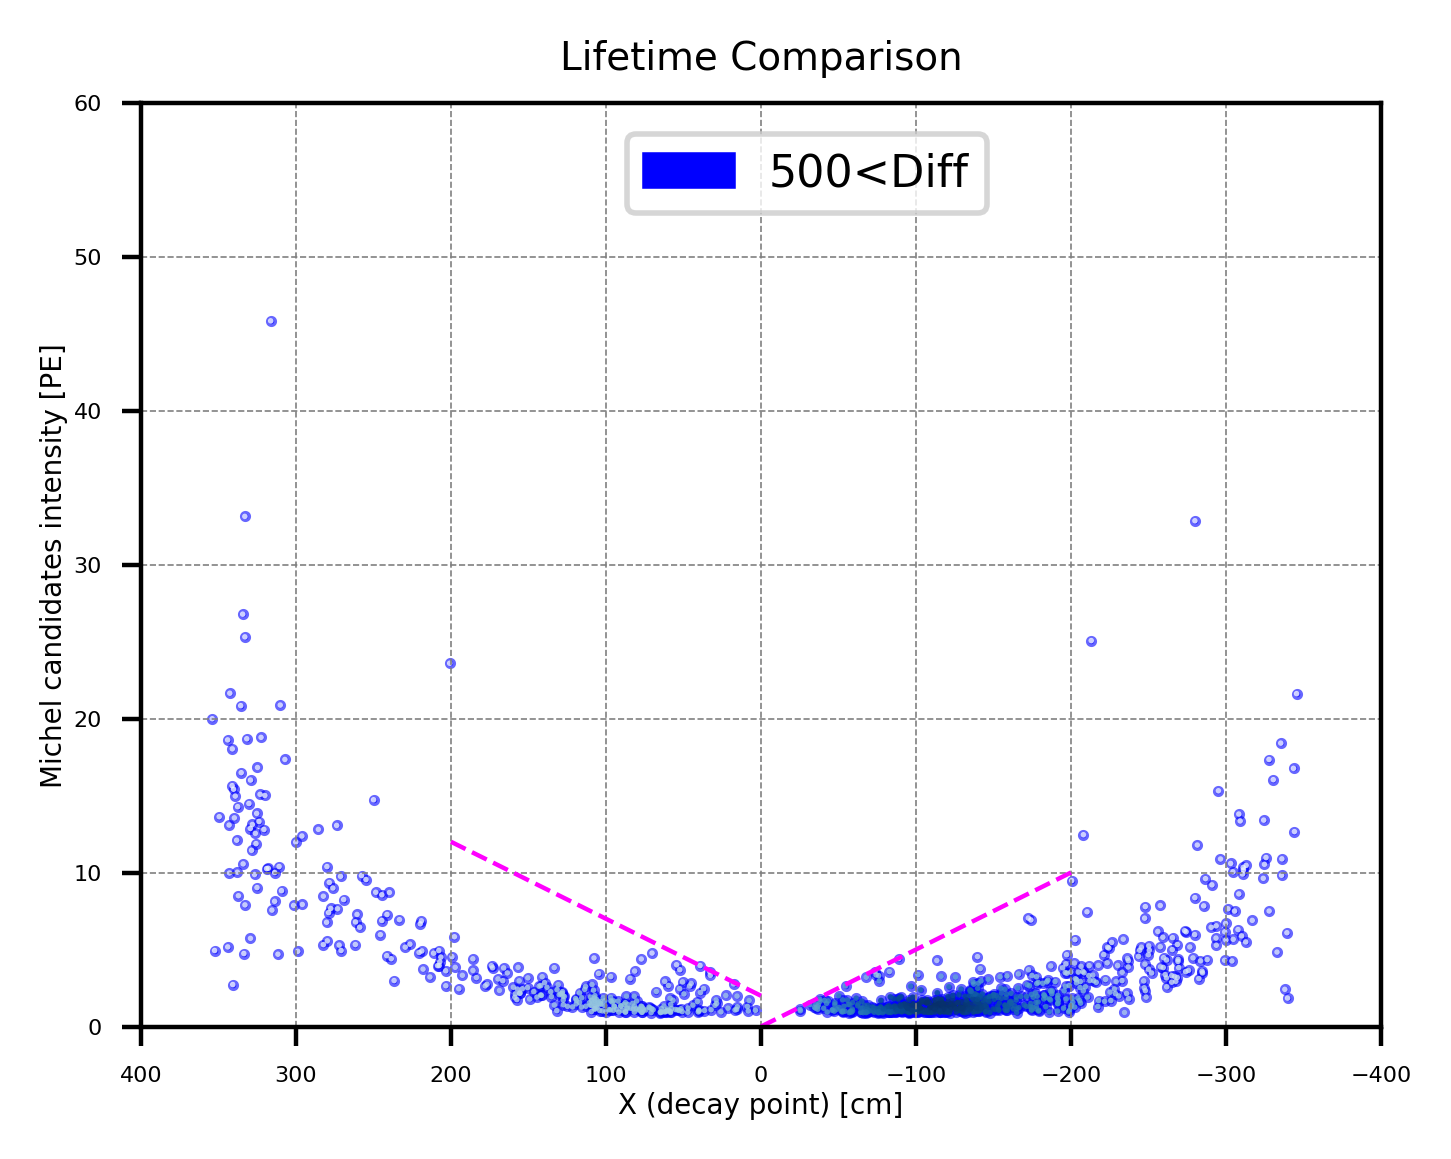

In [42]:
print("After cut 5:---------")

print("#events: ", len(events_total_purify5))



#Michel Peak rise & drop Cut (Cut 5')--------
# --- Define slopes and intercepts for both cuts ---
slope_pos = (7 - 2) / 100.0      # = 0.05
intercept_pos = 2.0

slope_neg = (10 - 0) / (-200 - 0.0)  # = -0.05
intercept_neg = 0.0

def below_line_cut(ev):
    """Return True if event passes both (posX, michel_intensity) cuts."""
    x = ev.posX
    y = ev.michel_intensity

    # Region 1: positive side [0, 100]
    if 0 <= x <= 200:
        return y <= intercept_pos + slope_pos * x

    # Region 2: negative side [-200, 0]
    elif -200 <= x <= 0:
        return y <= intercept_neg + slope_neg * x

    # Outside both ranges: no cut
    else:
        return True

# --- Apply the geometric cut to both event classes ---
events_total_purify5P = [ev for ev in events_total_purify5 if below_line_cut(ev)]
#-------------------------------





print("\nAfter Cut 5' (Michel vs Distance):--------------")

print("Efficiency (cut5' / cut5): ", len(events_total_purify5P), "/", len(events_total_purify5),
      "({:.2f}%)".format(len(events_total_purify5P)/len(events_total_purify5)*100))






#Michel Intensity VS x axis================================
plt.figure(figsize=(4,3), dpi=400)

posX_total_purify5P = [ev.posX for ev in events_total_purify5P]
miInt_total_purify5P = [ev.michel_intensity for ev in events_total_purify5P]

# Scatter plot----------

# --- 500<Diff (blue group) ---
x1 = np.array(posX_total_purify5P, dtype=float)
y1 = np.array(miInt_total_purify5P, dtype=float)
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)

# Base layer (solid color so single points are visible)
plt.scatter(x1, y1, s=1, color="blue", alpha=0.6, label="_nolegend_")
# Density layer (adds shading in dense regions)
plt.scatter(x1, y1, c=z1, s=1, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#-----------------------

#slope = 5/100 [PE/cm]
plt.plot([0.0, 200.0], [2, 12], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0.0, -200.0], [0, 10], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0, 60)
plt.xlabel('X (decay point) [cm]', labelpad=1, fontsize=5)
plt.ylabel('Michel candidates intensity [PE]', labelpad=1, fontsize=5)
plt.title('Lifetime Comparison', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="500<Diff")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#### Cut 6: Michel peak rise and drop slope: 

After cut 5':---------
#event    :  955

Michel Peak Rise Drop Slope (Cut 6):--------------
Efficiency (cut6 / cut5):  660 / 955 (69.11%)


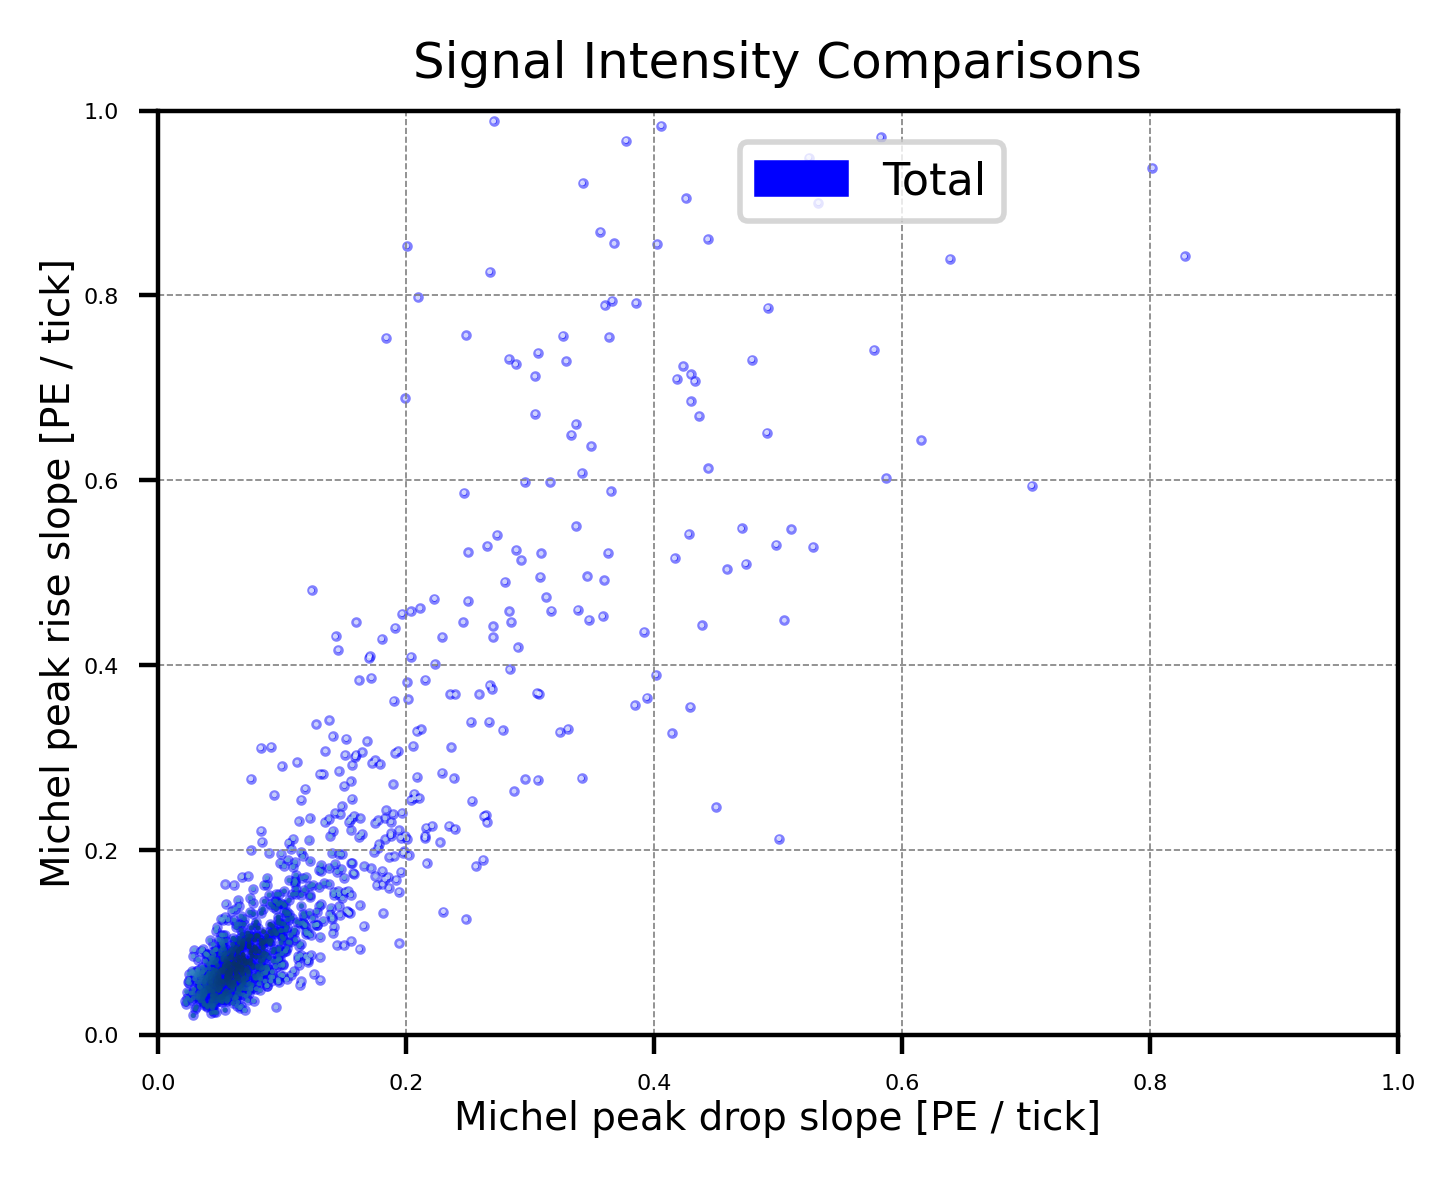

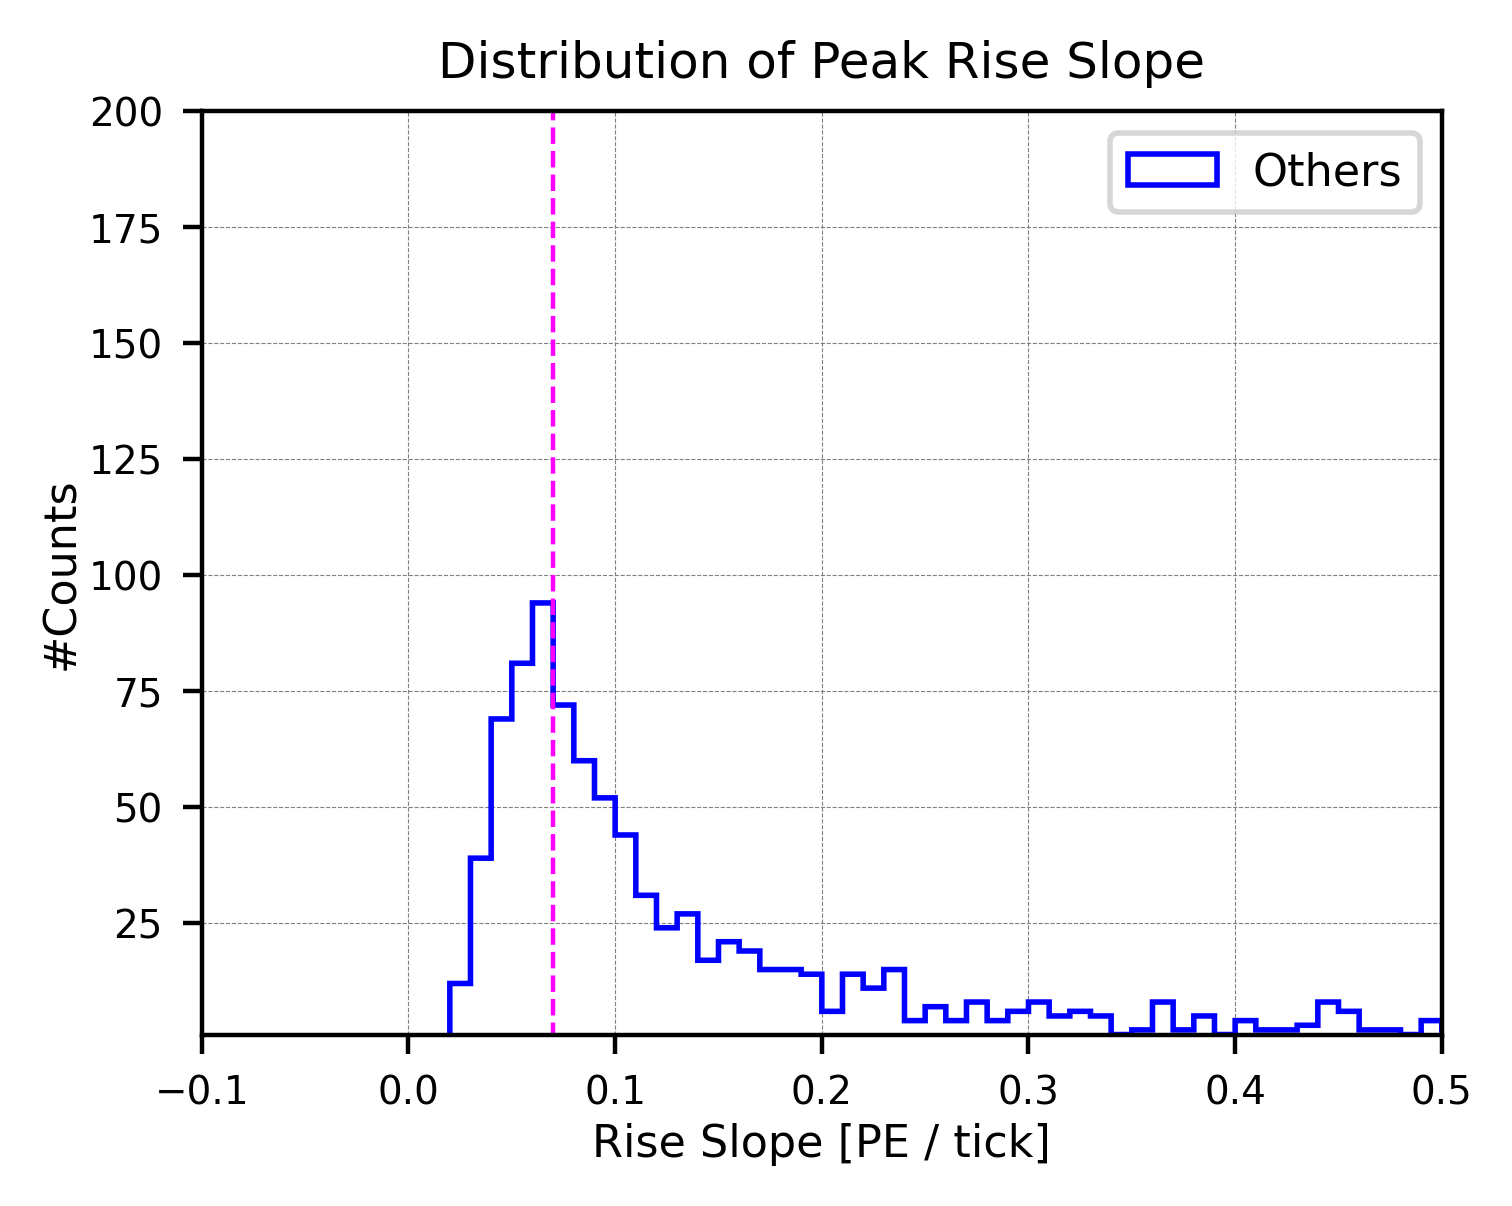

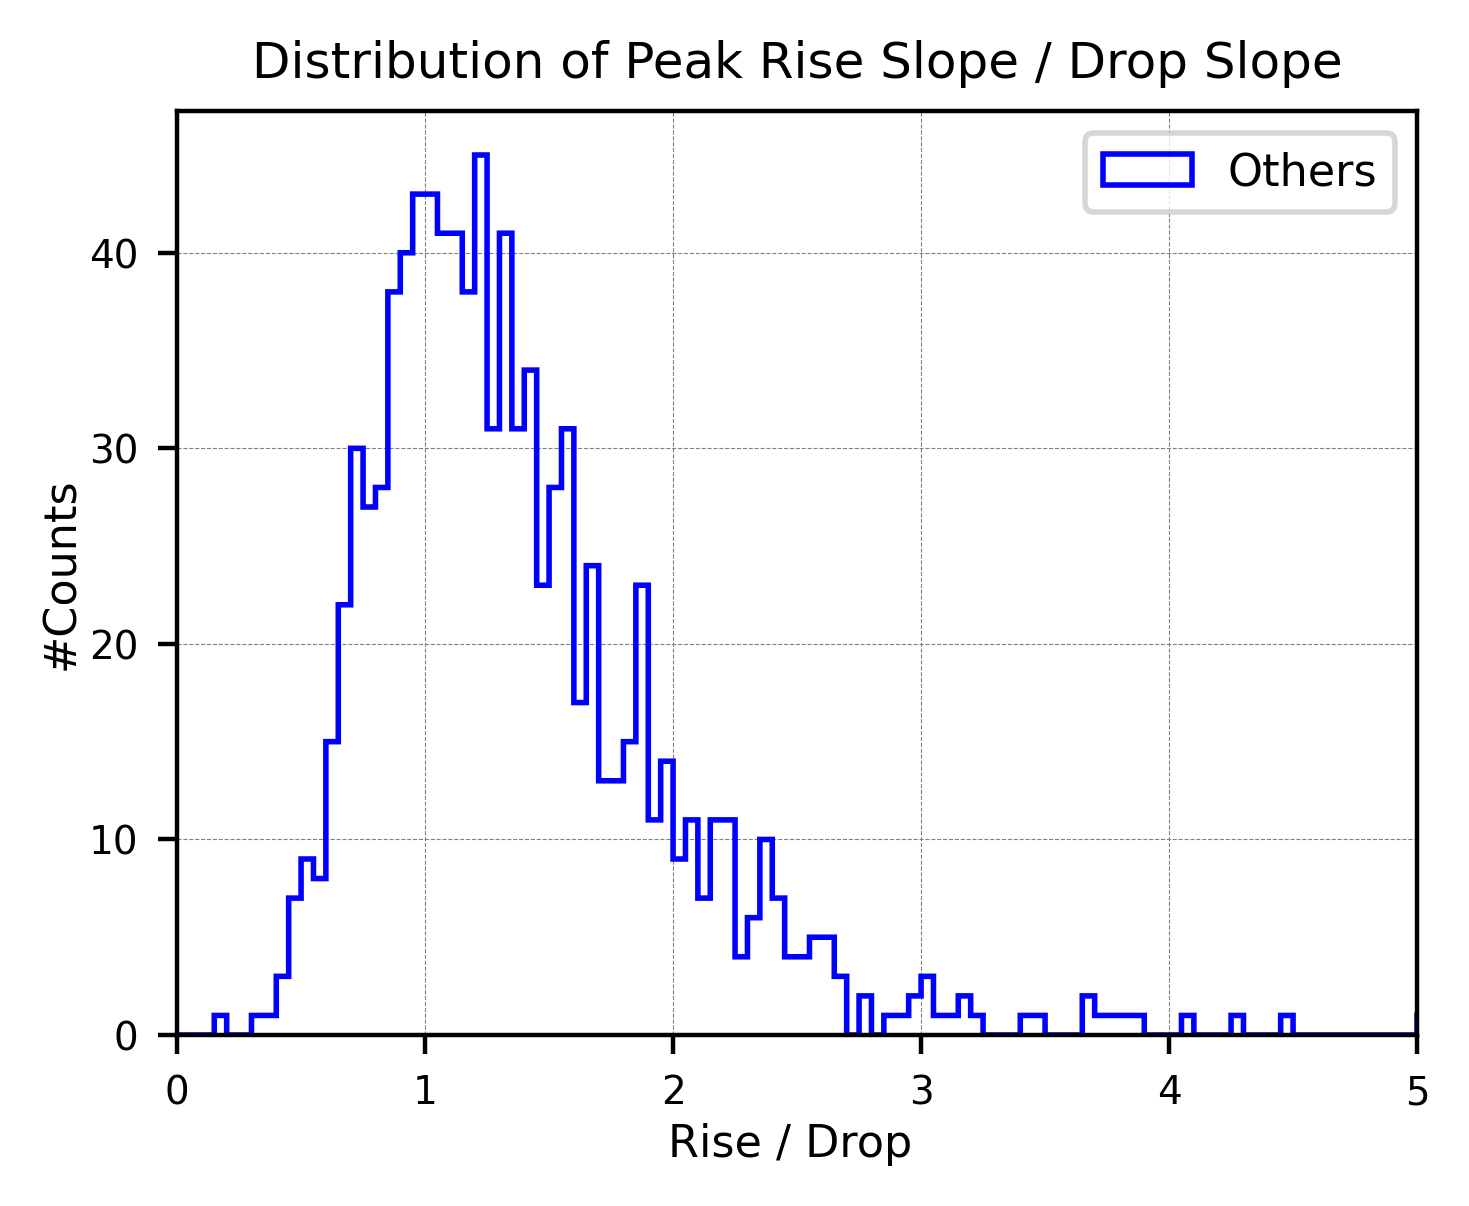

In [60]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 5':---------")
print("#event    : ", len(events_total_purify5P))



rise_total_purity5P = [ev.michel_rise for ev in events_total_purify5P]
drop_total_purity5P = [ev.michel_drop for ev in events_total_purify5P]

ratios_total_purity5P = [
    r / d if d not in (0, None) else None
    for r, d in zip(rise_total_purity5P, drop_total_purity5P)
]



thre_rise = 0.07 # mu Int will automatically higher than mi---


# filter the actual events
events_total_purify6 = [
    ev for ev in events_total_purify5P
    if thre_rise < ev.michel_rise 
]
#-------------------------------



print("\nMichel Peak Rise Drop Slope (Cut 6):--------------")

print("Efficiency (cut6 / cut5): ", len(events_total_purify6), "/", len(events_total_purify5P),
      "({:.2f}%)".format(len(events_total_purify6)/len(events_total_purify5P)*100))








# ==========================================================
# Michel Rise VS Michel Drop
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(drop_total_purity5P), np.array(rise_total_purity5P)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")


#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
#plt.plot([0, 1000], [0, 500], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('Michel peak drop slope [PE / tick]', labelpad=1, fontsize=7)
plt.ylabel('Michel peak rise slope [PE / tick]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()





#Michel Rise Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.01
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(rise_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.07, 0.07], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.1, 0.5)
plt.xlabel('Rise Slope [PE / tick]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 200)
#plt.xscale('log')
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  





#Michel Rise & Drop Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)
plt.hist(ratios_total_purity5P, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")


plt.xlim(0, 5)
plt.xlabel('Rise / Drop ', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.9, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Distribution of Peak Rise Slope / Drop Slope', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 




### Cut 7: 2nd 3rd peak intensity diff cut

After cut 6:---------
#event    :  660

Third / Second peak intensity (Cut 7):--------------
Efficiency (cut7 / cut6):  594 / 660 (90.00%)


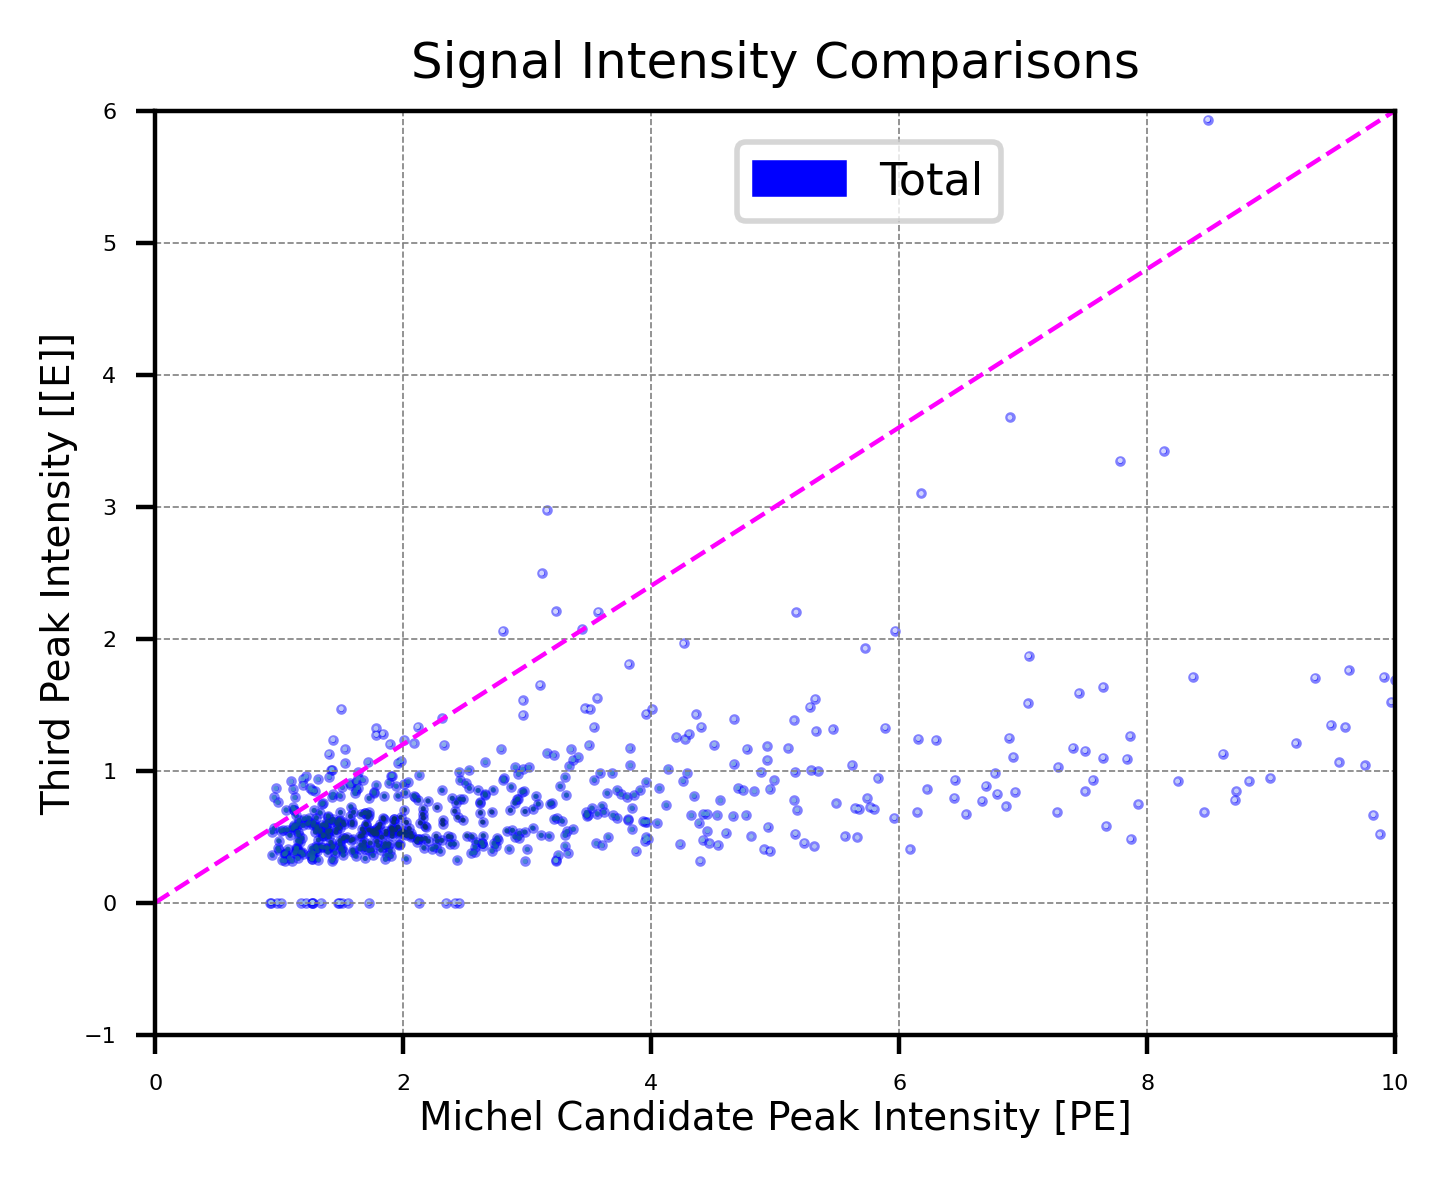

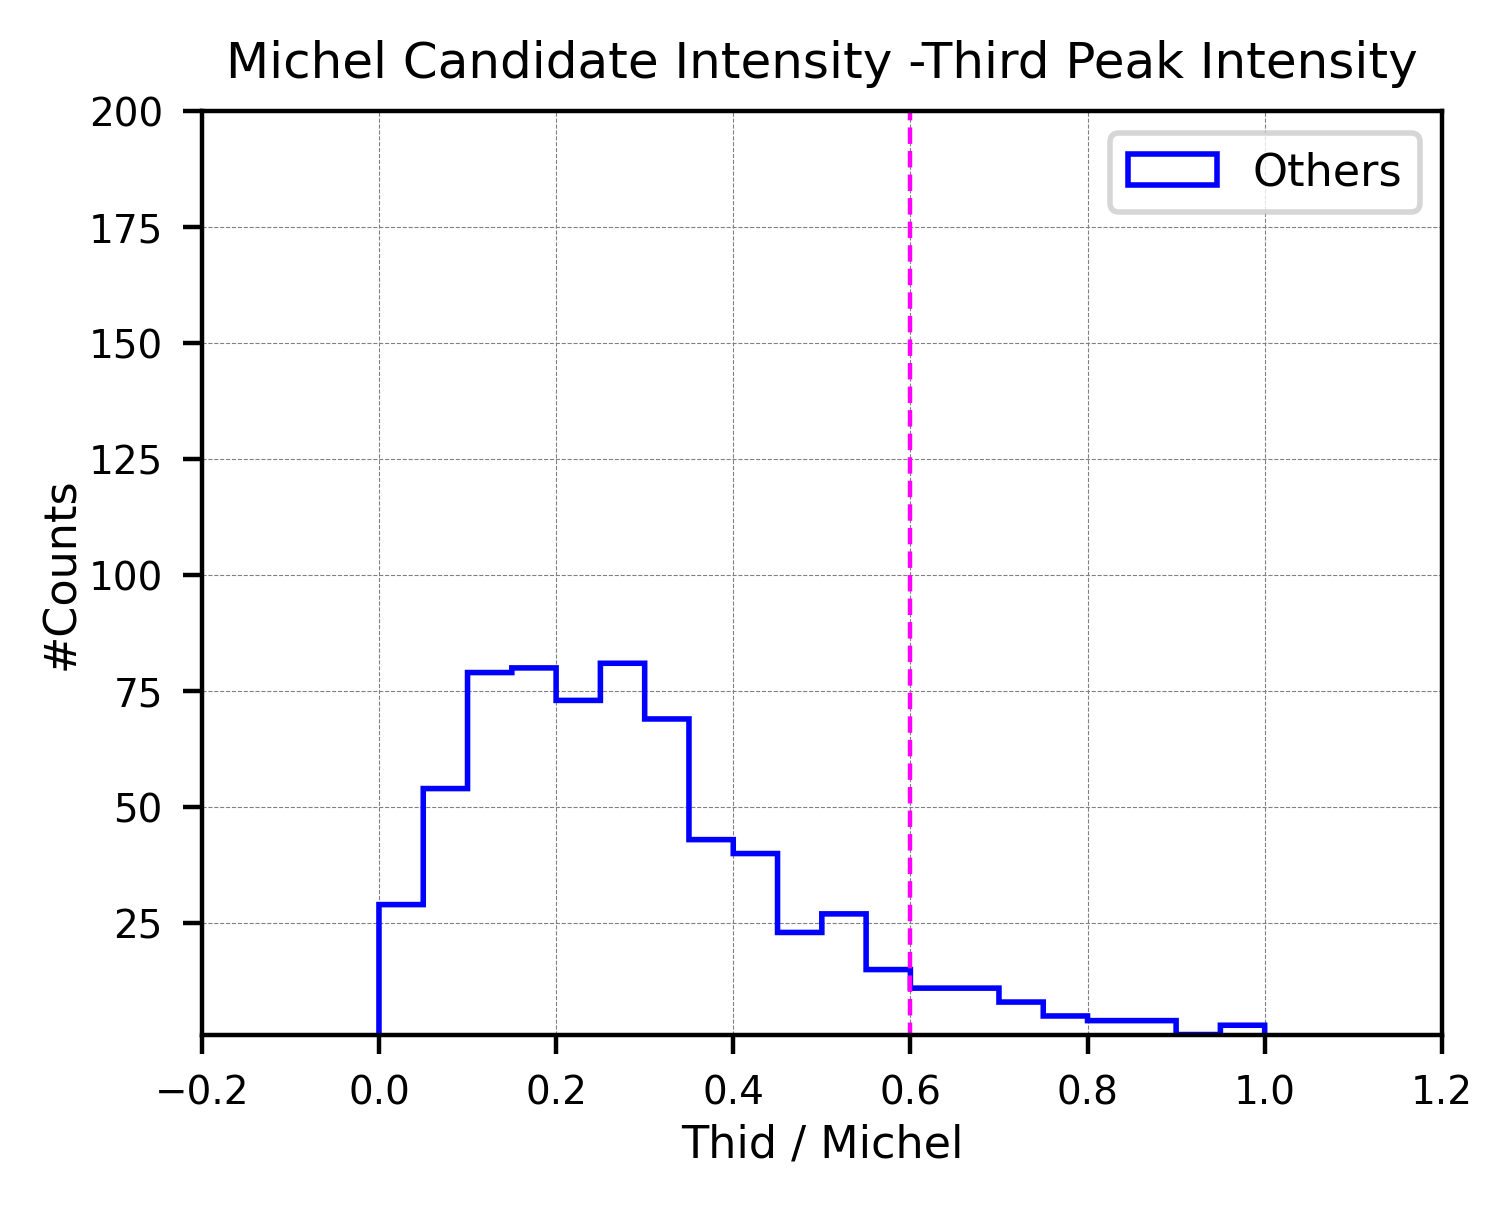

In [61]:
#Michel Peak rise & drop Cut (Cut 6)--------
print("After cut 6:---------")

print("#event    : ", len(events_total_purify6))



miInt_total_purity6 = [ev.michel_intensity for ev in events_total_purify6]
thInt_total_purity6 = [ev.third_intensity for ev in events_total_purify6]



# Element-by-element ratio (thInt / miInt)
ratio_total_purity6 = [th / mi for th, mi in zip(thInt_total_purity6, miInt_total_purity6)]


thre1 = 0.0
thre2 = 0.6

# filter the actual events

events_total_purify7 = [
    ev for ev in events_total_purify6
    if ev.michel_intensity != 0 and thre1 < ev.third_intensity / ev.michel_intensity < thre2
]
#-------------------------------


print("\nThird / Second peak intensity (Cut 7):--------------")
print("Efficiency (cut7 / cut6): ", len(events_total_purify7), "/", len(events_total_purify6),
      "({:.2f}%)".format(len(events_total_purify7)/len(events_total_purify6)*100))









# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x2, y2 = np.array(miInt_total_purity6), np.array(thInt_total_purity6)
# --- Density for group 2 (blue, 0<Diff<500) ---
xy2 = np.vstack([x2, y2])
z2 = gaussian_kde(xy2)(xy2)
idx2 = z2.argsort()
x2, y2, z2 = x2[idx2], y2[idx2], z2[idx2]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x2, y2, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x2, y2, c=z2, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

#plt.plot([0, 500], [0, 40], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([0, 100], [0, 60], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Total")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()






#Third / Michel Distributions===================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(ratio_total_purity6, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.6, 0.6], [0, 2000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-0.2, 1.2)
plt.xlabel('Thid / Michel', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 200)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show() 

### Cut 8: Third second peak intensity ratio cut


After Cut 7:--------------
#event   :  594

Michel 3rd Peaks intensity Diff (Cut 8):--------------
Efficiency (cut8 / cut7):  550 / 594 (92.59%)


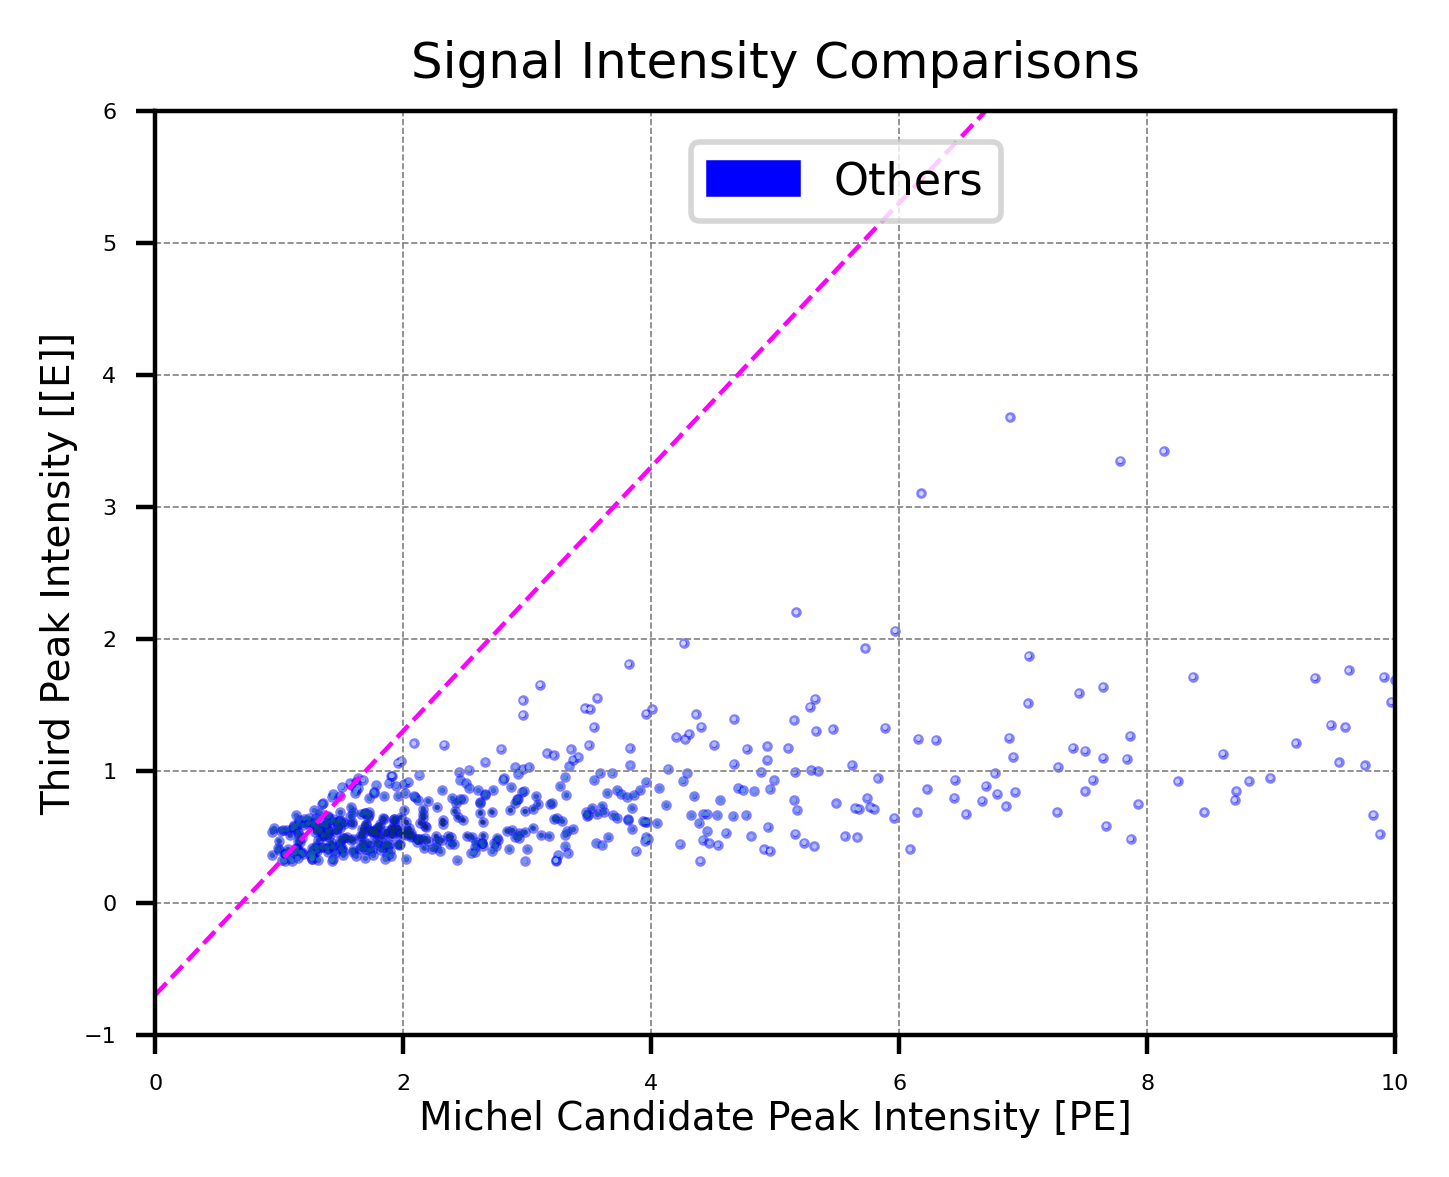

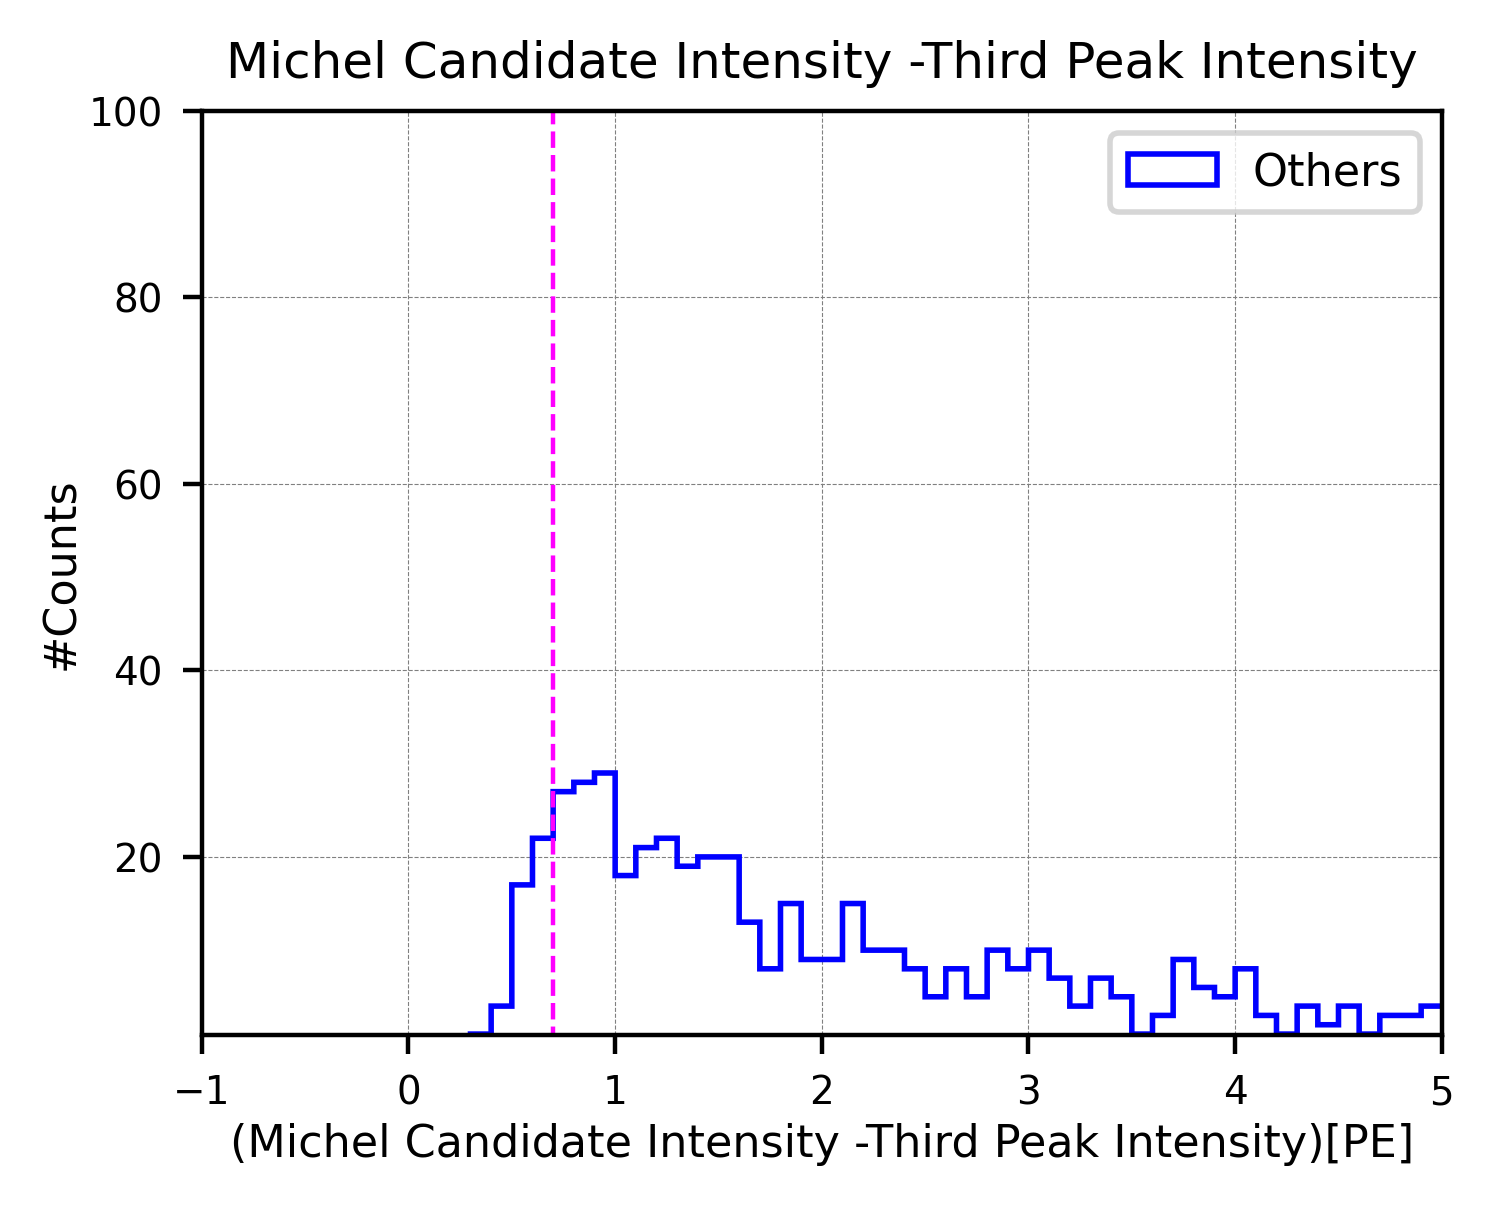

In [62]:
print("\nAfter Cut 7:--------------")

print("#event   : ", len(events_total_purify7))

miInt_total_purity7 = [ev.michel_intensity for ev in events_total_purify7]
thInt_total_purity7 = [ev.third_intensity for ev in events_total_purify7]

# Element-by-element difference (thInt - miInt)
subtract_total_purity7 = [mi - th for th, mi in zip(thInt_total_purity7, miInt_total_purity7)]


thre_diff = 0.7

# filter the actual events
events_total_purify8 = [
    ev for ev in events_total_purify7
    if thre_diff <  (ev.michel_intensity - ev.third_intensity)
]
#-------------------------------


print("\nMichel 3rd Peaks intensity Diff (Cut 8):--------------")

print("Efficiency (cut8 / cut7): ", len(events_total_purify8), "/", len(events_total_purify7),
      "({:.2f}%)".format(len(events_total_purify8)/len(events_total_purify7)*100))










# ==========================================================
# Michel Int VS Third Int
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot--------------------
# Convert to numpy arrays
x1, y1 = np.array(miInt_total_purity7), np.array(thInt_total_purity7)
# --- Density for group 1 (red, 500<Diff) ---
xy1 = np.vstack([x1, y1])
z1 = gaussian_kde(xy1)(xy1)
idx1 = z1.argsort()
x1, y1, z1 = x1[idx1], y1[idx1], z1[idx1]
# --- Scatter plots with base colors red & blue ---
# Base layer (solid red/blue so single points are visible)
plt.scatter(x1, y1, s=0.8, color="blue", alpha=0.5, label="_nolegend_")
# Density layer (adds darker shades where points overlap)
plt.scatter(x1, y1, c=z1, s=0.8, cmap="Blues", alpha=0.8, edgecolors="none", label="Total")
#---------------------------------

plt.plot([0, 10], [-0.7, 9.3], color="magenta", linewidth=0.8, linestyle='--')

#plt.axis('scaled')
plt.xlim(0, 10)
plt.ylim(-1, 6)
plt.xlabel('Michel Candidate Peak Intensity [PE]', labelpad=1, fontsize=7)
plt.ylabel('Third Peak Intensity [[E]]', labelpad=1, fontsize=7)
plt.title('Signal Intensity Comparisons', fontsize=9)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)

# Create proxy artists (red and blue dots)
blue_patch = mpatches.Patch(color="blue", label="Others")
plt.legend(handles=[blue_patch], loc="upper right", frameon=True, 
           bbox_to_anchor=(0.7, 0.99), fontsize=10, markerscale=6, ncol=1, prop={'size':8})

plt.show()









#(Michel Candidate Intensity -Third Peak Intensity) Distributions====================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(subtract_total_purity7, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Others")

plt.plot([0.7, 0.7], [0, 1000], color="magenta", linewidth=0.8, linestyle='--')

plt.xlim(-1, 5)
plt.xlabel('(Michel Candidate Intensity -Third Peak Intensity)[PE]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Michel Candidate Intensity -Third Peak Intensity', fontsize=9)
plt.legend(fontsize=8, loc="upper right")
plt.show()  

### Cut 9: Space Cut along drift direction


After Cut 8:--------------
Event    :  550

Drift Direction Cut (Cut 9):--------------
Efficiency (cut9 / cut8):  502 / 550 (91.27%)

Decay points distribution: 


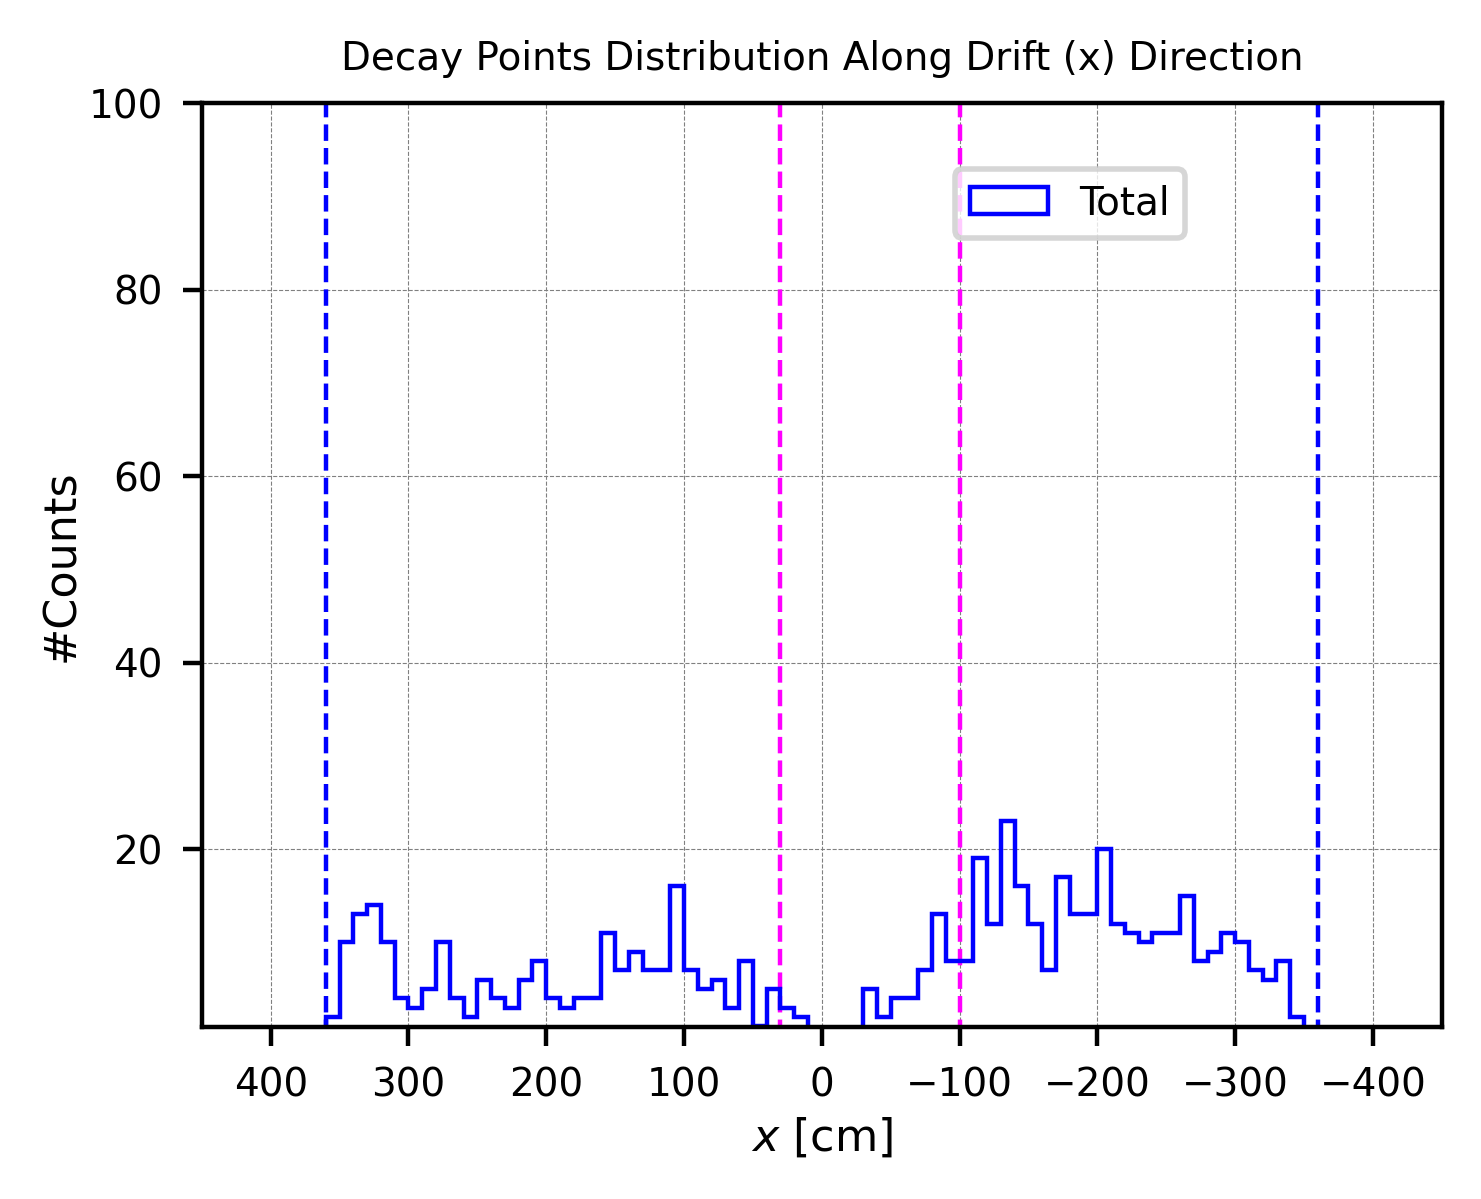

In [65]:
print("\nAfter Cut 8:--------------")

print("Event    : ", len(events_total_purify8))





posX_cut = 30
negX_cut = -100

# filter the actual events
events_total_purify9 = [
    ev for ev in events_total_purify8
    if posX_cut < ev.posX  or  ev.posX < negX_cut
]
#-------------------------------


print("\nDrift Direction Cut (Cut 9):--------------")

print("Efficiency (cut9 / cut8): ", len(events_total_purify9), "/", len(events_total_purify8),
      "({:.2f}%)".format(len(events_total_purify9)/len(events_total_purify8)*100))










posX_total_purify8 = [ev.posX for ev in events_total_purify8]



#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Cut line------
plt.plot([30, 30], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')
plt.plot([-100, -100], [0, 3000], color="magenta", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify8, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




<br />

#### Single Event Inspection:

In [50]:
# "Signal"
for ev in events_total_purify9:
    if ev.reco_lifetime >10000:
        print(ev)



PdsEventNew(muon_time=59, michel_time=788, muon_intensity=17.0864, michel_intensity=3.55586, third_intensity=0.447515, posX=32.9515, posY=267.385, posZ=129.208, eventID=113980, trackID=7, date=20251029, michel_score=0.669902, michel_hits=23, reco_lifetime=11664, michel_rise=0.196415, michel_drop=0.19754777777777777)
PdsEventNew(muon_time=60, michel_time=758, muon_intensity=86.2029, michel_intensity=32.8407, third_intensity=3.99499, posX=-280.003, posY=260.194, posZ=412.949, eventID=117234, trackID=0, date=20251029, michel_score=0.718517, michel_hits=11, reco_lifetime=11168, michel_rise=1.2137424242424242, michel_drop=1.0593774193548386)
PdsEventNew(muon_time=60, michel_time=974, muon_intensity=54.4064, michel_intensity=8.13298, third_intensity=3.42033, posX=313.692, posY=277.011, posZ=127.541, eventID=123957, trackID=22, date=20251029, michel_score=0.999672, michel_hits=11, reco_lifetime=14624, michel_rise=0.54183, michel_drop=0.4280515789473684)
PdsEventNew(muon_time=60, michel_time=9

<br />
<br />

#### Features of final dataset (after purification 9):


Decay points distribution: 


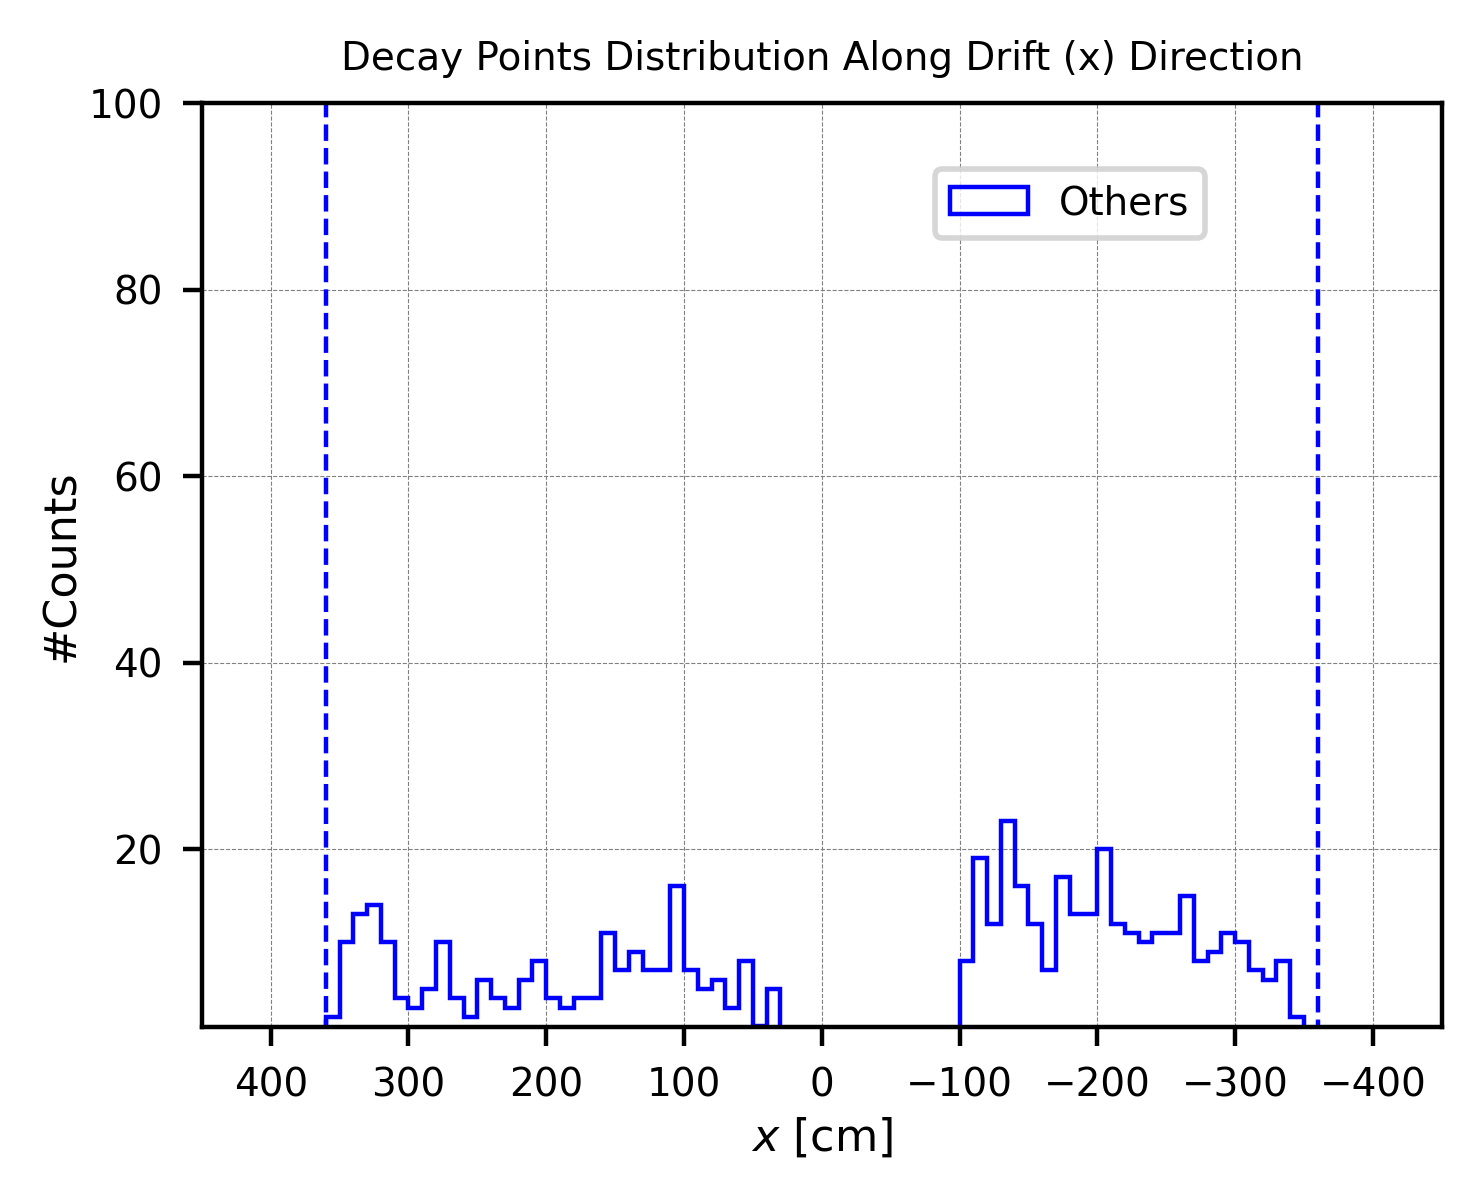

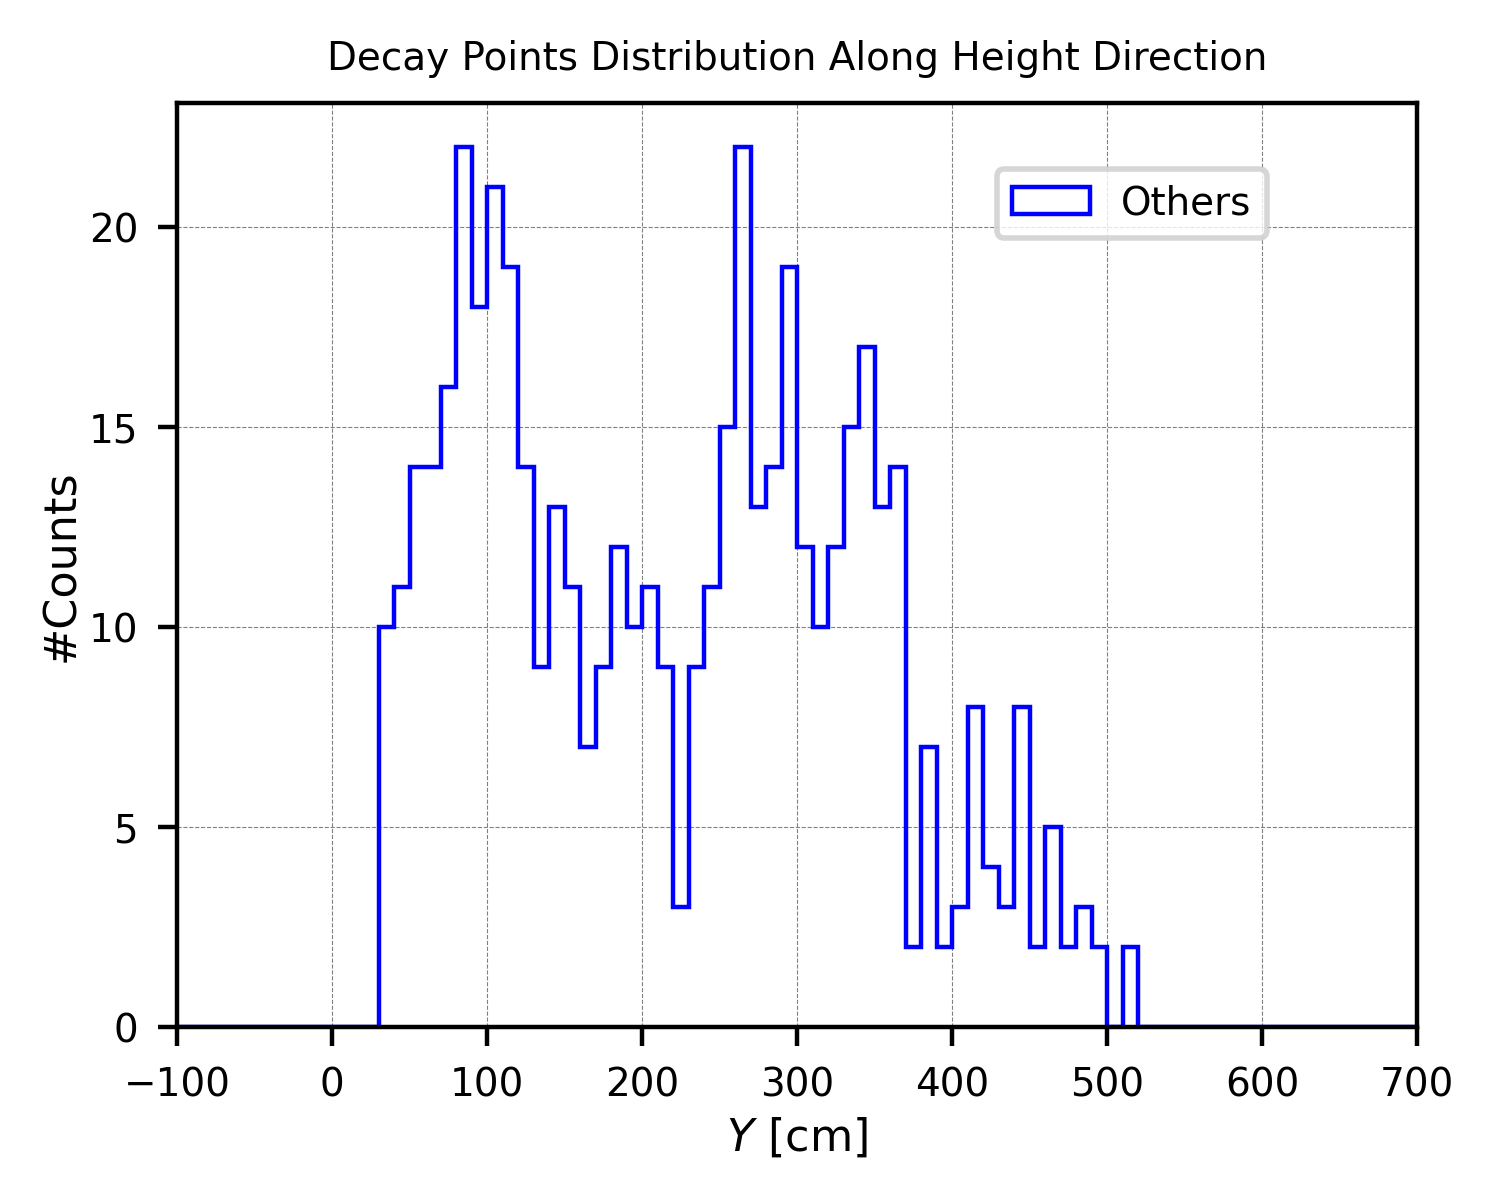

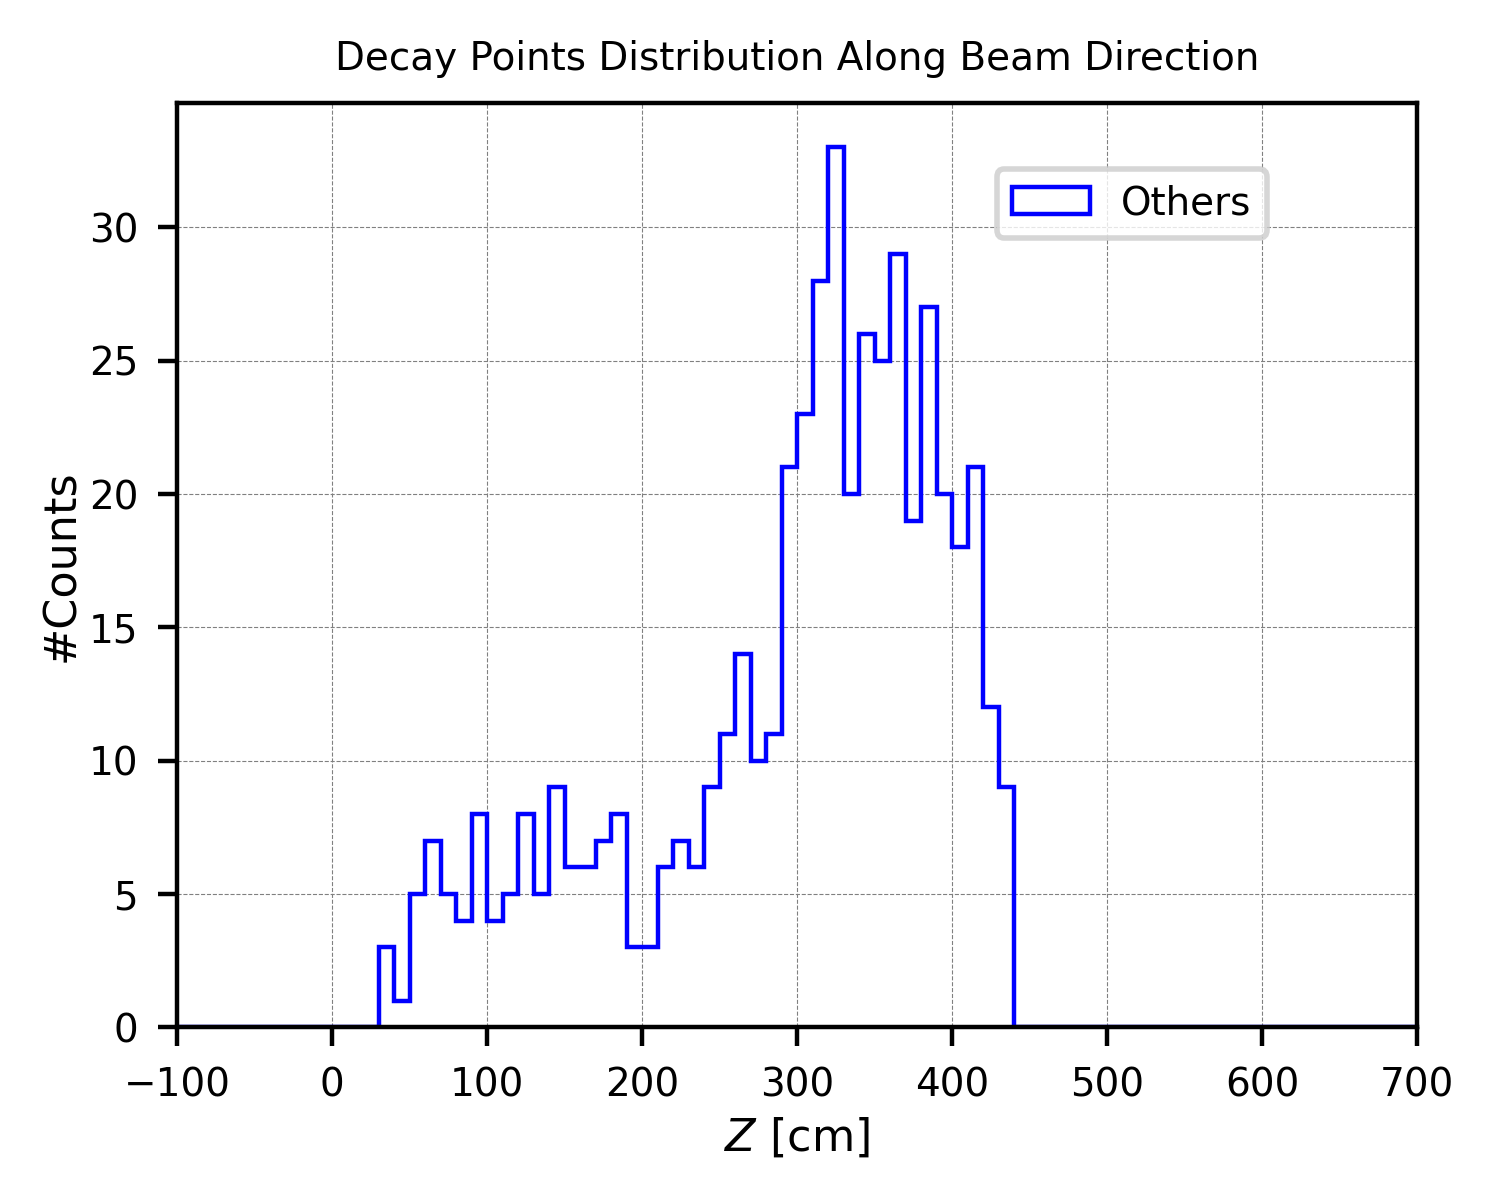

In [54]:

posX_total_purify9 = [ev.posX for ev in events_total_purify9]
posY_total_purify9 = [ev.posY for ev in events_total_purify9]
posZ_total_purify9 = [ev.posZ for ev in events_total_purify9]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posX_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-450, 450)
plt.xlabel(r'$x$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.9, 100)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift (x) Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Y distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posY_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Y$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Height Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  




# Plotting the histogram (Z distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 10
range_min = -1000
range_max = 1000
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(posZ_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")
#--------------------------------

plt.xlim(-100, 700)
plt.xlabel(r'$Z$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Beam Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 











# Set the limits of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

# Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465


# ==========================================================
# Y–X plane plotting (Front View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line for field cage
# aux2 = [0, 610, 610, 0, 0]
# aux1 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posX_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posX_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posX_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posX_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posX_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(xmin, xmax)
# plt.ylim(-50, 660)
# plt.gca().invert_xaxis()  # Flip x-axis
# plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Front View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


# ==========================================================
# Z–X plane plotting (Top View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux1 = [0, 465, 465, 0, 0]
# aux2 = [356, 356, -356, -356, 356]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posX_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posX_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posX_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posX_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posX_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.ylim(xmin, xmax)
# plt.xlim(-50, 515)
# plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.title('Top View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()




# ==========================================================
# Y–Z plane plotting (Side View)
# ==========================================================
# plt.figure(figsize=(4,3), dpi=400)

# # Auxiliary line
# aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY]
# aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
# plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# # Scatter plot----------
# # plt.scatter(posZ_true500, posY_true500, s=1, c='red', alpha=1.0, label="500<True")
# # plt.scatter(posZ_true0, posY_true0, s=1, c='blue', alpha=1.0, label="0<True<500")
# # plt.scatter(posZ_false, posY_false, s=1, c='black', alpha=1.0, label="True<0 (False)")

# plt.scatter(posZ_diff500, posY_diff500, s=1, c='grey', alpha=1.0, label="500<Diff")
# plt.scatter(posZ_diff0, posY_diff0, s=1, c='magenta', alpha=1.0, label="0<Diff<500")
# #-----------------------

# plt.axis('scaled')
# plt.xlim(-50, 515)
# plt.ylim(-50, 660)
# plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
# plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
# plt.title('Side View', fontsize=7)
# plt.tick_params(labelsize=4)
# plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
# plt.legend(fontsize=5, loc="upper right")
# plt.show()


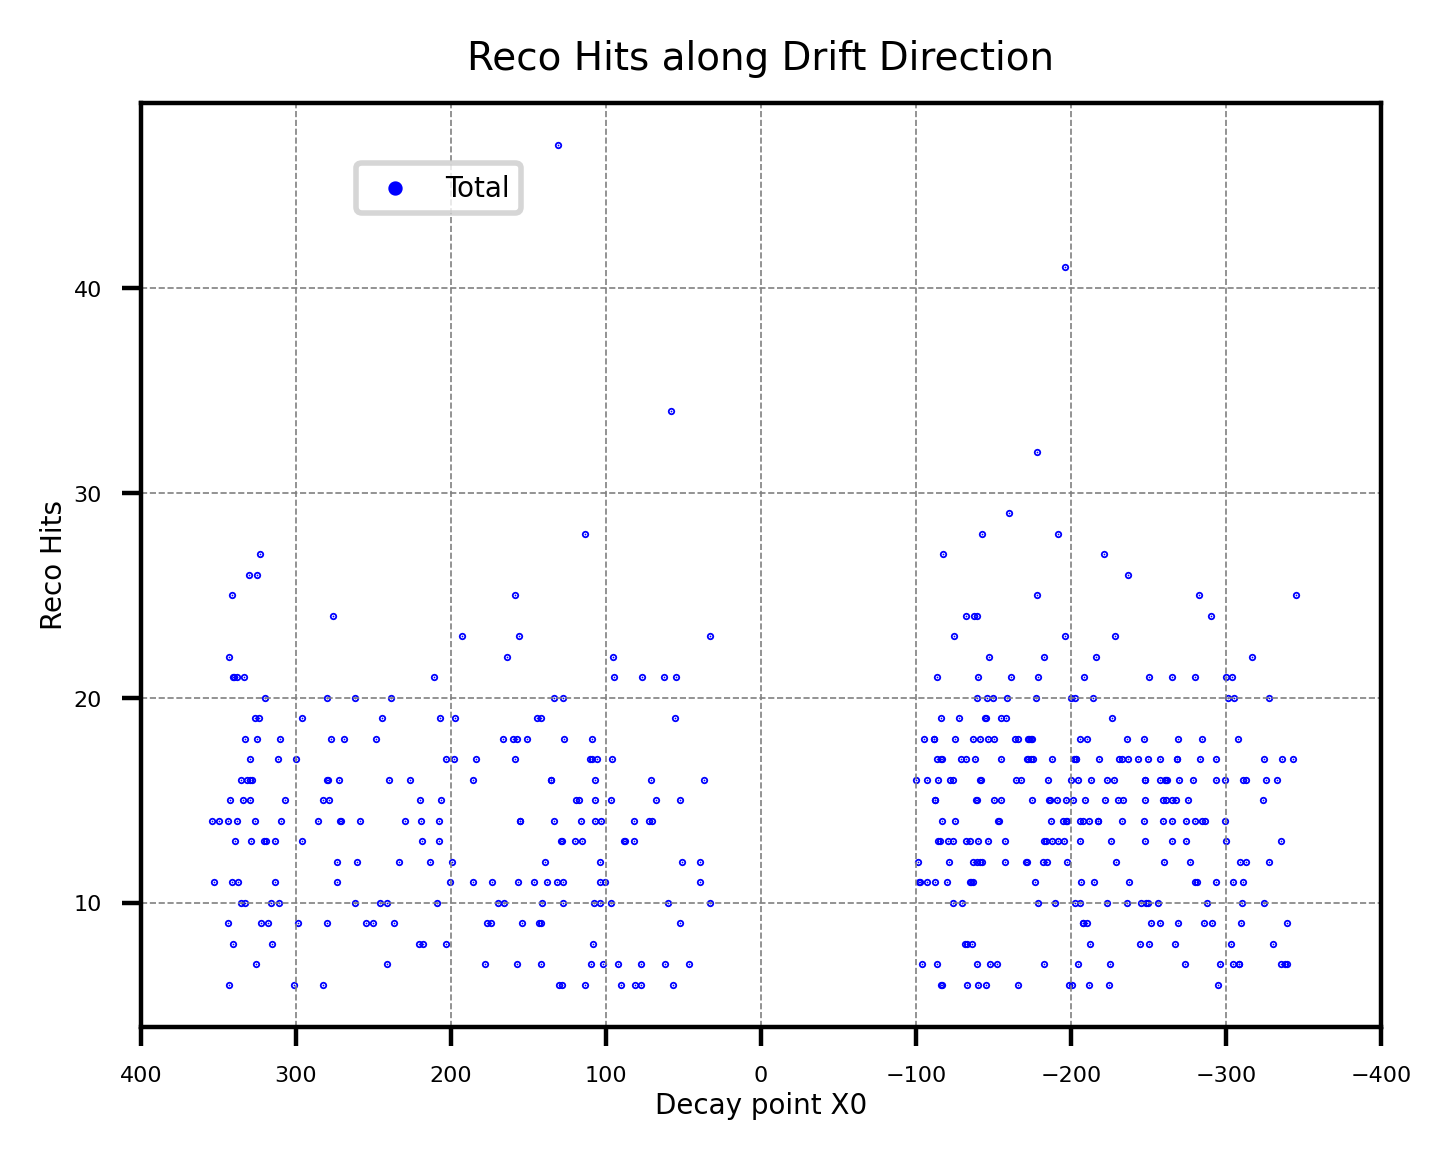


Michel Score Distribution: 


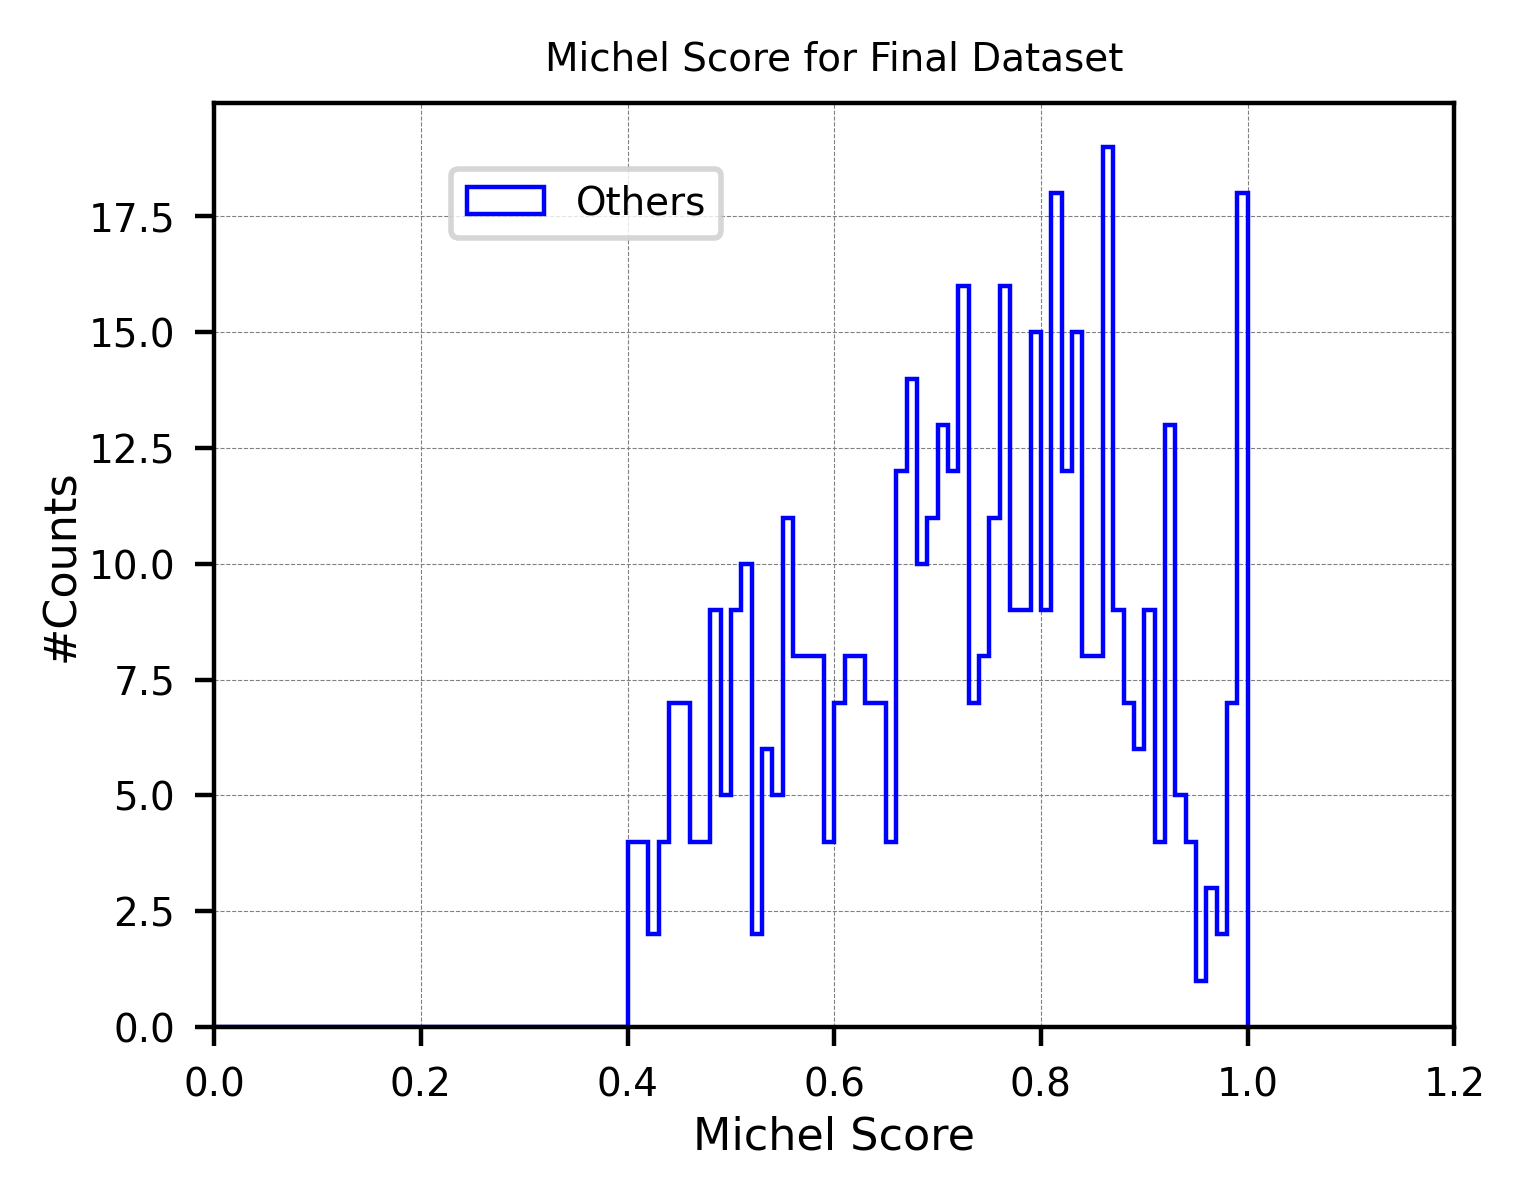


Michel Hits Distribution: 


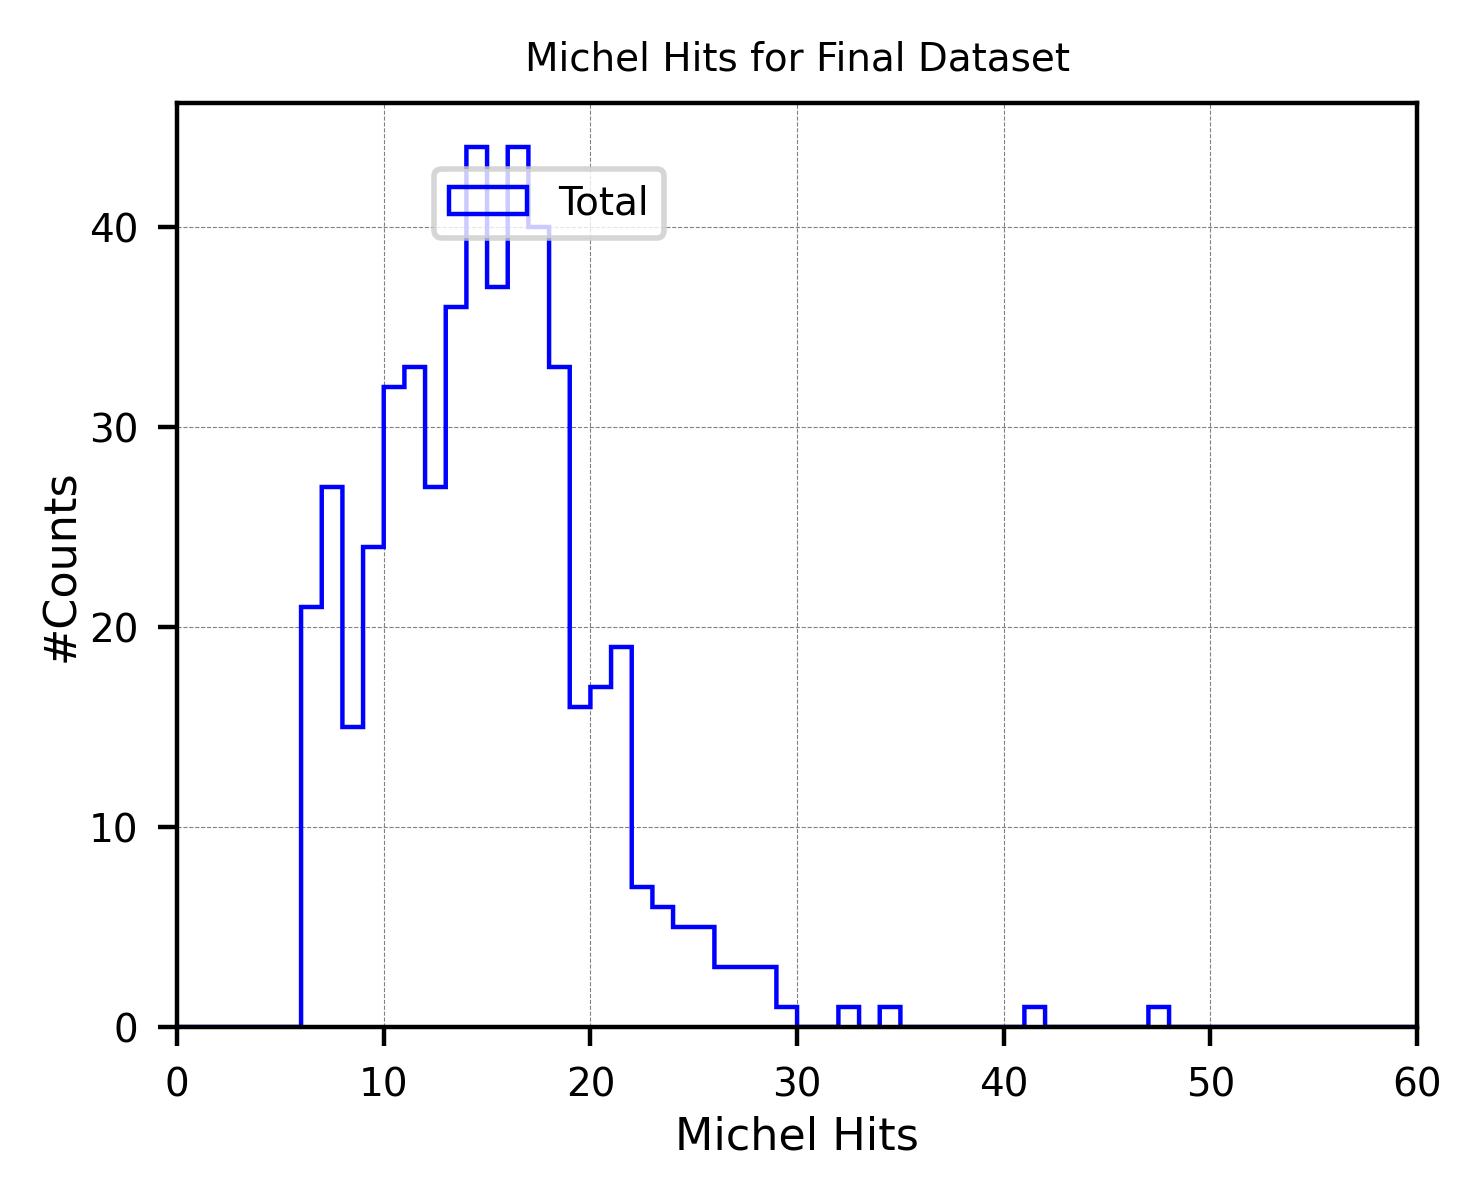

In [57]:

hits_total_purify9 = [ev.michel_hits for ev in events_total_purify9]

score_total_purify9 = [ev.michel_score for ev in events_total_purify9]











# ==========================================================
# reco hits VS posX
# ==========================================================
plt.figure(figsize=(4,3), dpi=400)

# Scatter plot----------
plt.scatter(posX_total_purify9, hits_total_purify9, s=0.1, c='blue', alpha=1.0, label="Total")
#-----------------------

#plt.axis('scaled')
plt.xlim(-400, 400)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0, 2000)
plt.ylabel('Reco Hits', labelpad=1, fontsize=5)
plt.xlabel('Decay point X0', labelpad=1, fontsize=5)
plt.title('Reco Hits along Drift Direction', fontsize=7)
plt.tick_params(labelsize=4)
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.24, 0.95), fontsize=6, markerscale=5, ncol=1, prop={'size':5})
plt.show()








#Michel Score distribution:==========================================
print("\nMichel Score Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min =-1
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(score_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Others")

#--------------------------------

plt.xlim(0, 1.2)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Score for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 







#Michel Hits distribution:==========================================
print("\nMichel Hits Distribution: ")

# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min =0
range_max = 600
bins = np.arange(range_min, range_max + bin_width, bin_width)

#--------------------------------
plt.hist(hits_total_purify9, bins=bins, range=(range_min, range_max), edgecolor='blue', 
          histtype='step', linewidth=0.8, label="Total")

#--------------------------------

plt.xlim(0, 60)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 200)
#plt.yscale('log')
plt.title('Michel Hits for Final Dataset', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 





<br />
<br />
<br />

#### Lifetime Distribution of Final Dataset (purification 9):



For each event, +40ns for reco time


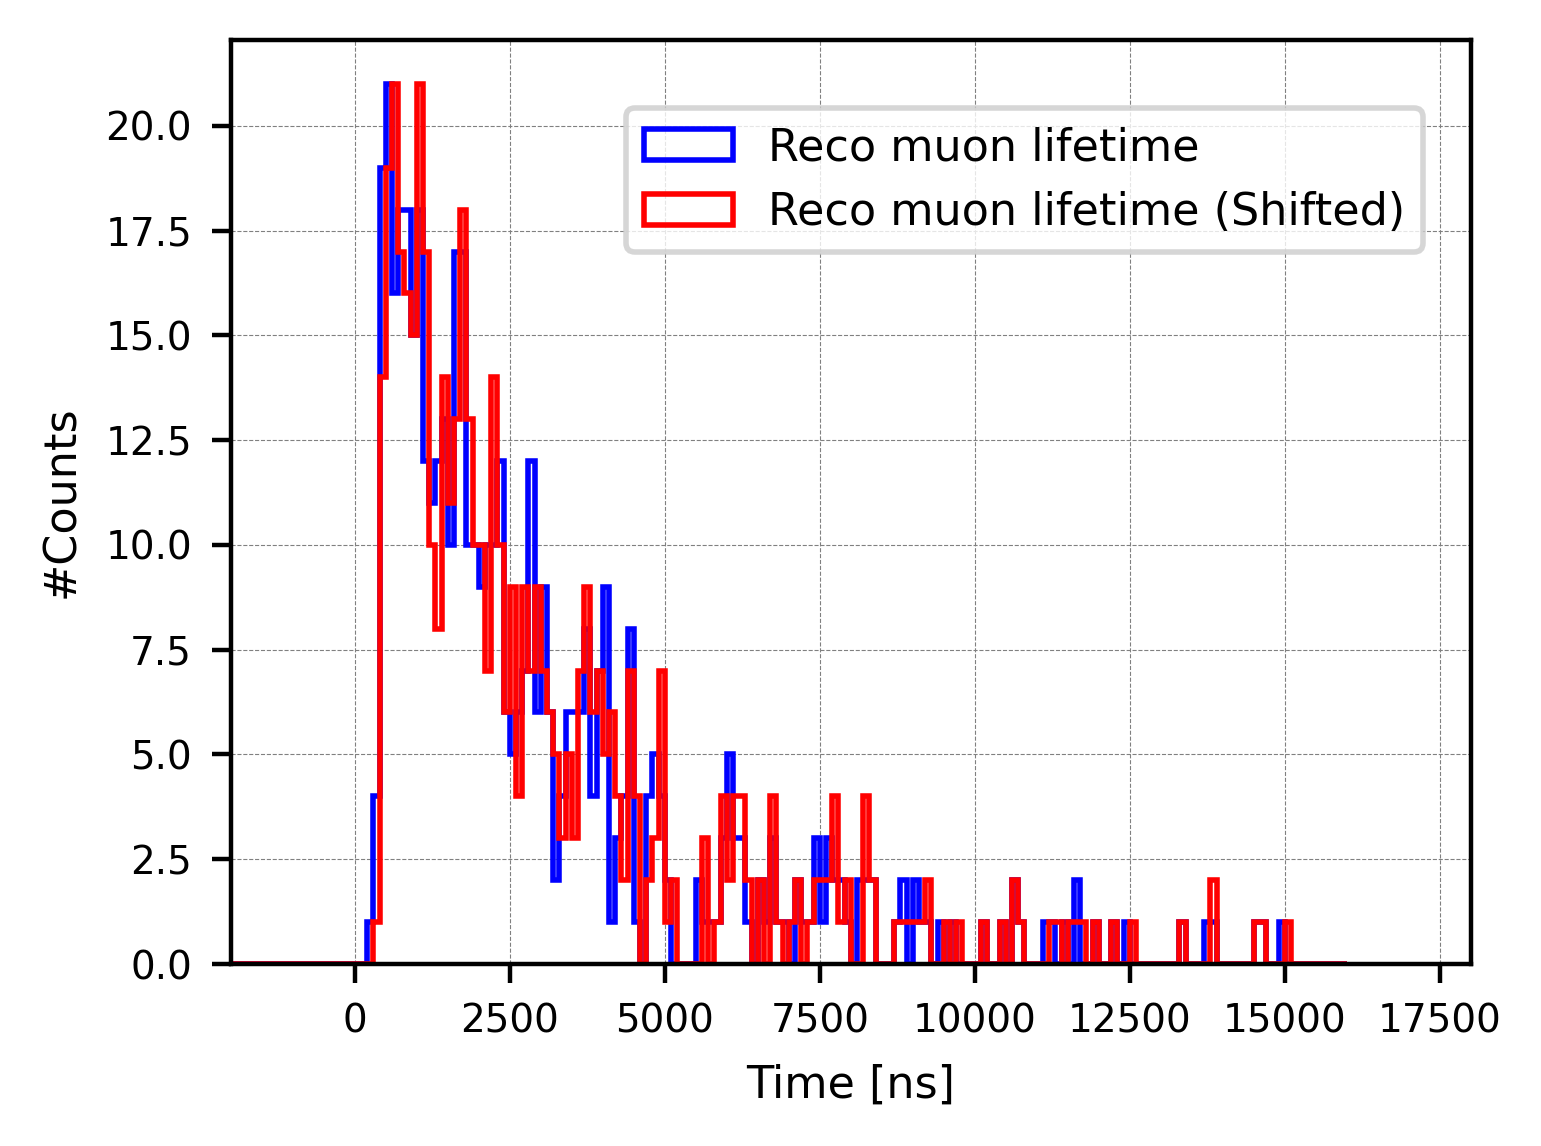

In [58]:

recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]






#Shift +40ns=========================================
print("\n\n===================================")
print("For each event, +40ns for reco time")
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]


bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.figure(figsize=(4, 3), dpi=400)
plt.hist(recoT_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=1.0,
         label='Reco muon lifetime')

plt.hist(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
         edgecolor='red', histtype='step', linewidth=1.0,
         label='Reco muon lifetime (Shifted)')

plt.xlim(-2000, 18000)
#plt.ylim(0.9, 1000)
#plt.yscale("log")
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
#plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.64, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()





<br />
<br />
<br />

#### Fitting (Bin integrated) for lifetime distribution (purification 9): [No need to execute NOW]

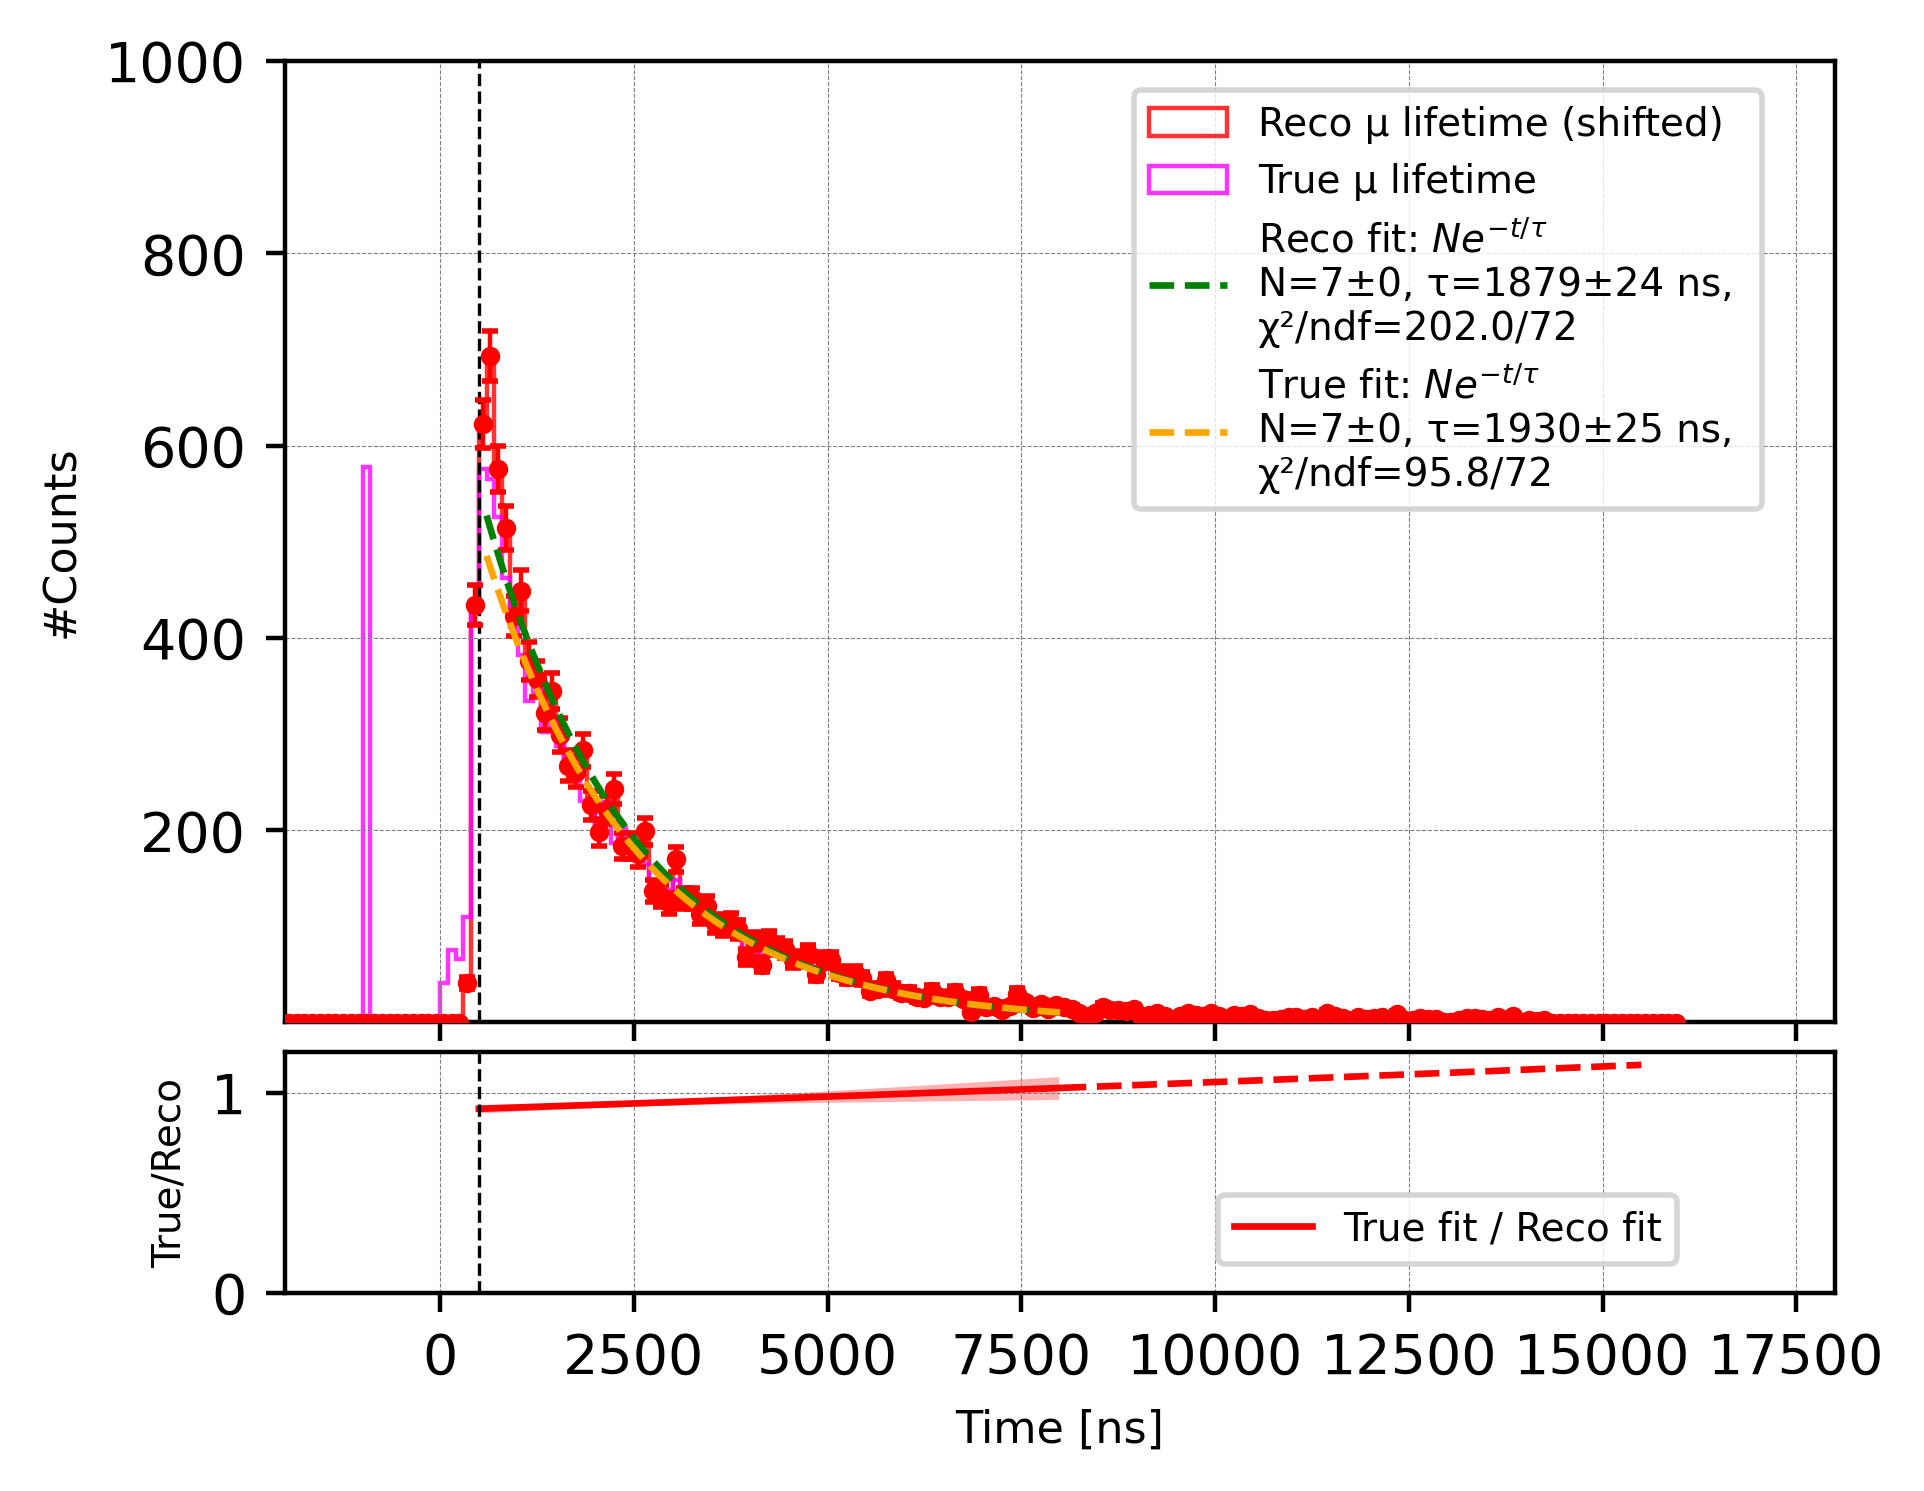

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.gridspec import GridSpec


#======Double Fitting with Ratio Panel==================================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Histogram binning
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- Bin-integrated models ---
def exp1_integrated(edges, N, tau):
    a, b = edges[:-1], edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau))

def exp1C_integrated(edges, N, tau, C):
    a, b = edges[:-1], edges[1:]
    return N * tau * (np.exp(-a/tau) - np.exp(-b/tau)) + C * (b - a)

# --- Helpers ---
def _safe_sigma(y):
    return np.sqrt(np.clip(y, 1.0, None))

def numerical_grad(func, params, cov, x, h=1e-6):
    """Compute propagated uncertainty for func(x,*params) given parameter covariance."""
    f0 = func(x, *params)
    nparams = len(params)
    grads = np.zeros((nparams, len(x)))

    # finite difference for each parameter
    for i in range(nparams):
        dp = np.zeros_like(params, dtype=float)
        dp[i] = h * (abs(params[i]) + 1.0)
        f1 = func(x, *(params+dp))
        f2 = func(x, *(params-dp))
        grads[i] = (f1 - f2) / (2*dp[i])

    # propagate covariance: per point variance
    var = np.zeros(len(x))
    for k in range(len(x)):
        gk = grads[:, k]               # gradient at point k
        var[k] = gk @ cov @ gk         # g^T Cov g
    return np.sqrt(var)


# --- Reco fit: N*exp(-t/tau) + C ---
def fit_and_overlay_exp1C(ax, sample, label, fit_min, fit_max, color=None, line_style='--'):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    m = (centers >= fit_min) & (centers <= fit_max)
    y = counts[m]

    if len(y) < 3 or y.sum() <= 0:
        return None, None, None, None

    edges_fit = bin_edges[np.where(m)[0][0] : np.where(m)[0][-1] + 2]
    sigma = _safe_sigma(y)

    N0 = np.sum(y); tau0 = 2000.0; C0 = np.min(y)/max(bin_width,1)
    p0 = [N0, tau0, C0]

    popt, pcov = curve_fit(
        lambda e, N, tau, C: exp1C_integrated(e, N, tau, C),
        edges_fit, y, p0=p0, sigma=sigma,
        absolute_sigma=True, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(((y - exp1C_integrated(edges_fit, *popt))/sigma)**2)
    ndf = len(y) - len(popt)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    y_smooth = popt[0]*np.exp(-t_smooth/popt[1])*bin_width + popt[2]*bin_width

    ax.plot(t_smooth, y_smooth, line_style, linewidth=1.2, color=color, zorder=5,
            label=(rf"{label} fit: $Ne^{{-t/\tau}} + C$"
                   f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
                   f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
                   f"\nC={popt[2]:.1f}±{perr[2]:.1f}, "
                   f"χ²/ndf={chi2:.1f}/{ndf}"))

    return t_smooth, y_smooth, popt, pcov

# --- True fit: N*exp(-t/tau) ---
def fit_and_overlay_exp1(ax, sample, label, fit_min, fit_max, color=None):
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    m = (centers >= fit_min) & (centers <= fit_max)
    y = counts[m]

    if len(y) < 3 or y.sum() <= 0:
        return None, None, None, None

    edges_fit = bin_edges[np.where(m)[0][0] : np.where(m)[0][-1] + 2]
    sigma = _safe_sigma(y)

    N0 = np.sum(y); tau0 = 2000.0
    p0 = [N0, tau0]

    popt, pcov = curve_fit(
        lambda e, N, tau: exp1_integrated(e, N, tau),
        edges_fit, y, p0=p0, sigma=sigma,
        absolute_sigma=True, maxfev=20000
    )
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(((y - exp1_integrated(edges_fit, *popt))/sigma)**2)
    ndf = len(y) - len(popt)

    t_smooth = np.linspace(fit_min, fit_max, 400)
    y_smooth = popt[0]*np.exp(-t_smooth/popt[1])*bin_width

    ax.plot(t_smooth, y_smooth, linestyle='--', linewidth=1.2, color=color, zorder=5,
            label=(rf"{label} fit: $Ne^{{-t/\tau}}$"
                   f"\nN={popt[0]:.0f}±{perr[0]:.0f}, "
                   f"τ={popt[1]:.0f}±{perr[1]:.0f} ns, "
                   f"\nχ²/ndf={chi2:.1f}/{ndf}"))

    return t_smooth, y_smooth, popt, pcov

# -------- Top panel --------
ax1 = fig.add_subplot(gs[0])

# Histograms (faint outlines) + errors
counts_reco, bin_edges_reco, _ = ax1.hist(
    recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max),
    edgecolor='red', histtype='step', linewidth=0.8, alpha=0.8,
    label='Reco μ lifetime (shifted)', zorder=1
)
bin_centers_reco = 0.5*(bin_edges_reco[:-1]+bin_edges_reco[1:])
ax1.errorbar(bin_centers_reco, counts_reco,
             yerr=np.sqrt(np.clip(counts_reco,0,None)),
             fmt='o', color='red', markersize=2.5,
             elinewidth=0.8, capsize=1.5, zorder=3)

ax1.hist(trueT_total_purify9, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8,
         alpha=0.8, label='True μ lifetime', zorder=1)

# Fits
#t_reco, fit_reco, popt_reco, pcov_reco = fit_and_overlay_exp1C(ax1, recoT_total_purify9_shift40, "Reco",
#                                                               500, 8000, color="green")
t_reco, fit_reco, popt_reco, pcov_reco = fit_and_overlay_exp1(ax1, recoT_total_purify9_shift40, "Reco",
                                                               600, 8000, color="green")
t_true, fit_true, popt_true, pcov_true = fit_and_overlay_exp1(ax1, trueT_total_purify9, "True",
                                                              600, 8000, color="orange")

# Style
ax1.set_xlim(-2000, 16000)
ax1.tick_params(labelbottom=False)
ax1.set_ylim(0.1, 1000)
#ax1.set_yscale('log')
ax1.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.75, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})

# -------- Bottom panel (ratio) --------
ax2 = fig.add_subplot(gs[1], sharex=ax1)
if (popt_reco is not None) and (popt_true is not None):
    t_common = np.linspace(500, 15500, 400)

#    f_reco = lambda x, N, tau, C: N*np.exp(-x/tau)*bin_width + C*bin_width
    f_reco = lambda x, N, tau: N*np.exp(-x/tau)*bin_width
    f_true = lambda x, N, tau: N*np.exp(-x/tau)*bin_width

    fit_reco_common = f_reco(t_common, *popt_reco)
    fit_true_common = f_true(t_common, *popt_true)
    ratio = np.divide(fit_true_common, fit_reco_common,
                      out=np.zeros_like(fit_true_common),
                      where=(fit_reco_common>0))

    # --- Error bands (only valid in fit range ≤ 8000) ---
    sigma_true = numerical_grad(f_true, np.array(popt_true), pcov_true, t_common)
    sigma_reco = numerical_grad(f_reco, np.array(popt_reco), pcov_reco, t_common)
    sigma_ratio = np.sqrt((sigma_true/fit_reco_common)**2 +
                          (fit_true_common * sigma_reco / fit_reco_common**2)**2)

    mask_fit = t_common <= 8000
    mask_extrap = t_common > 8000

    # Plot ratio: solid inside fit range, dashed outside
    ax2.plot(t_common[mask_fit], ratio[mask_fit],
             color='red', linewidth=1.2, label='True fit / Reco fit')
    ax2.plot(t_common[mask_extrap], ratio[mask_extrap],
             color='red', linewidth=1.2, linestyle='--')

    # Fill band only in fit range
    ax2.fill_between(t_common[mask_fit],
                     ratio[mask_fit] - sigma_ratio[mask_fit],
                     ratio[mask_fit] + sigma_ratio[mask_fit],
                     color='red', alpha=0.3, linewidth=0)

ax2.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax2.set_xlim(-2000, 18000)
ax2.set_ylim(0.0, 1.2)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('True/Reco', fontsize=7)
ax2.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.75, 0.49),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})

plt.show()

<br />
<br />
<br />

## Lifetime measurement efficiency: [No need to execute NOW]

#### Efficiency for final dataset (Note: The ratio here is NOT very helpful...):

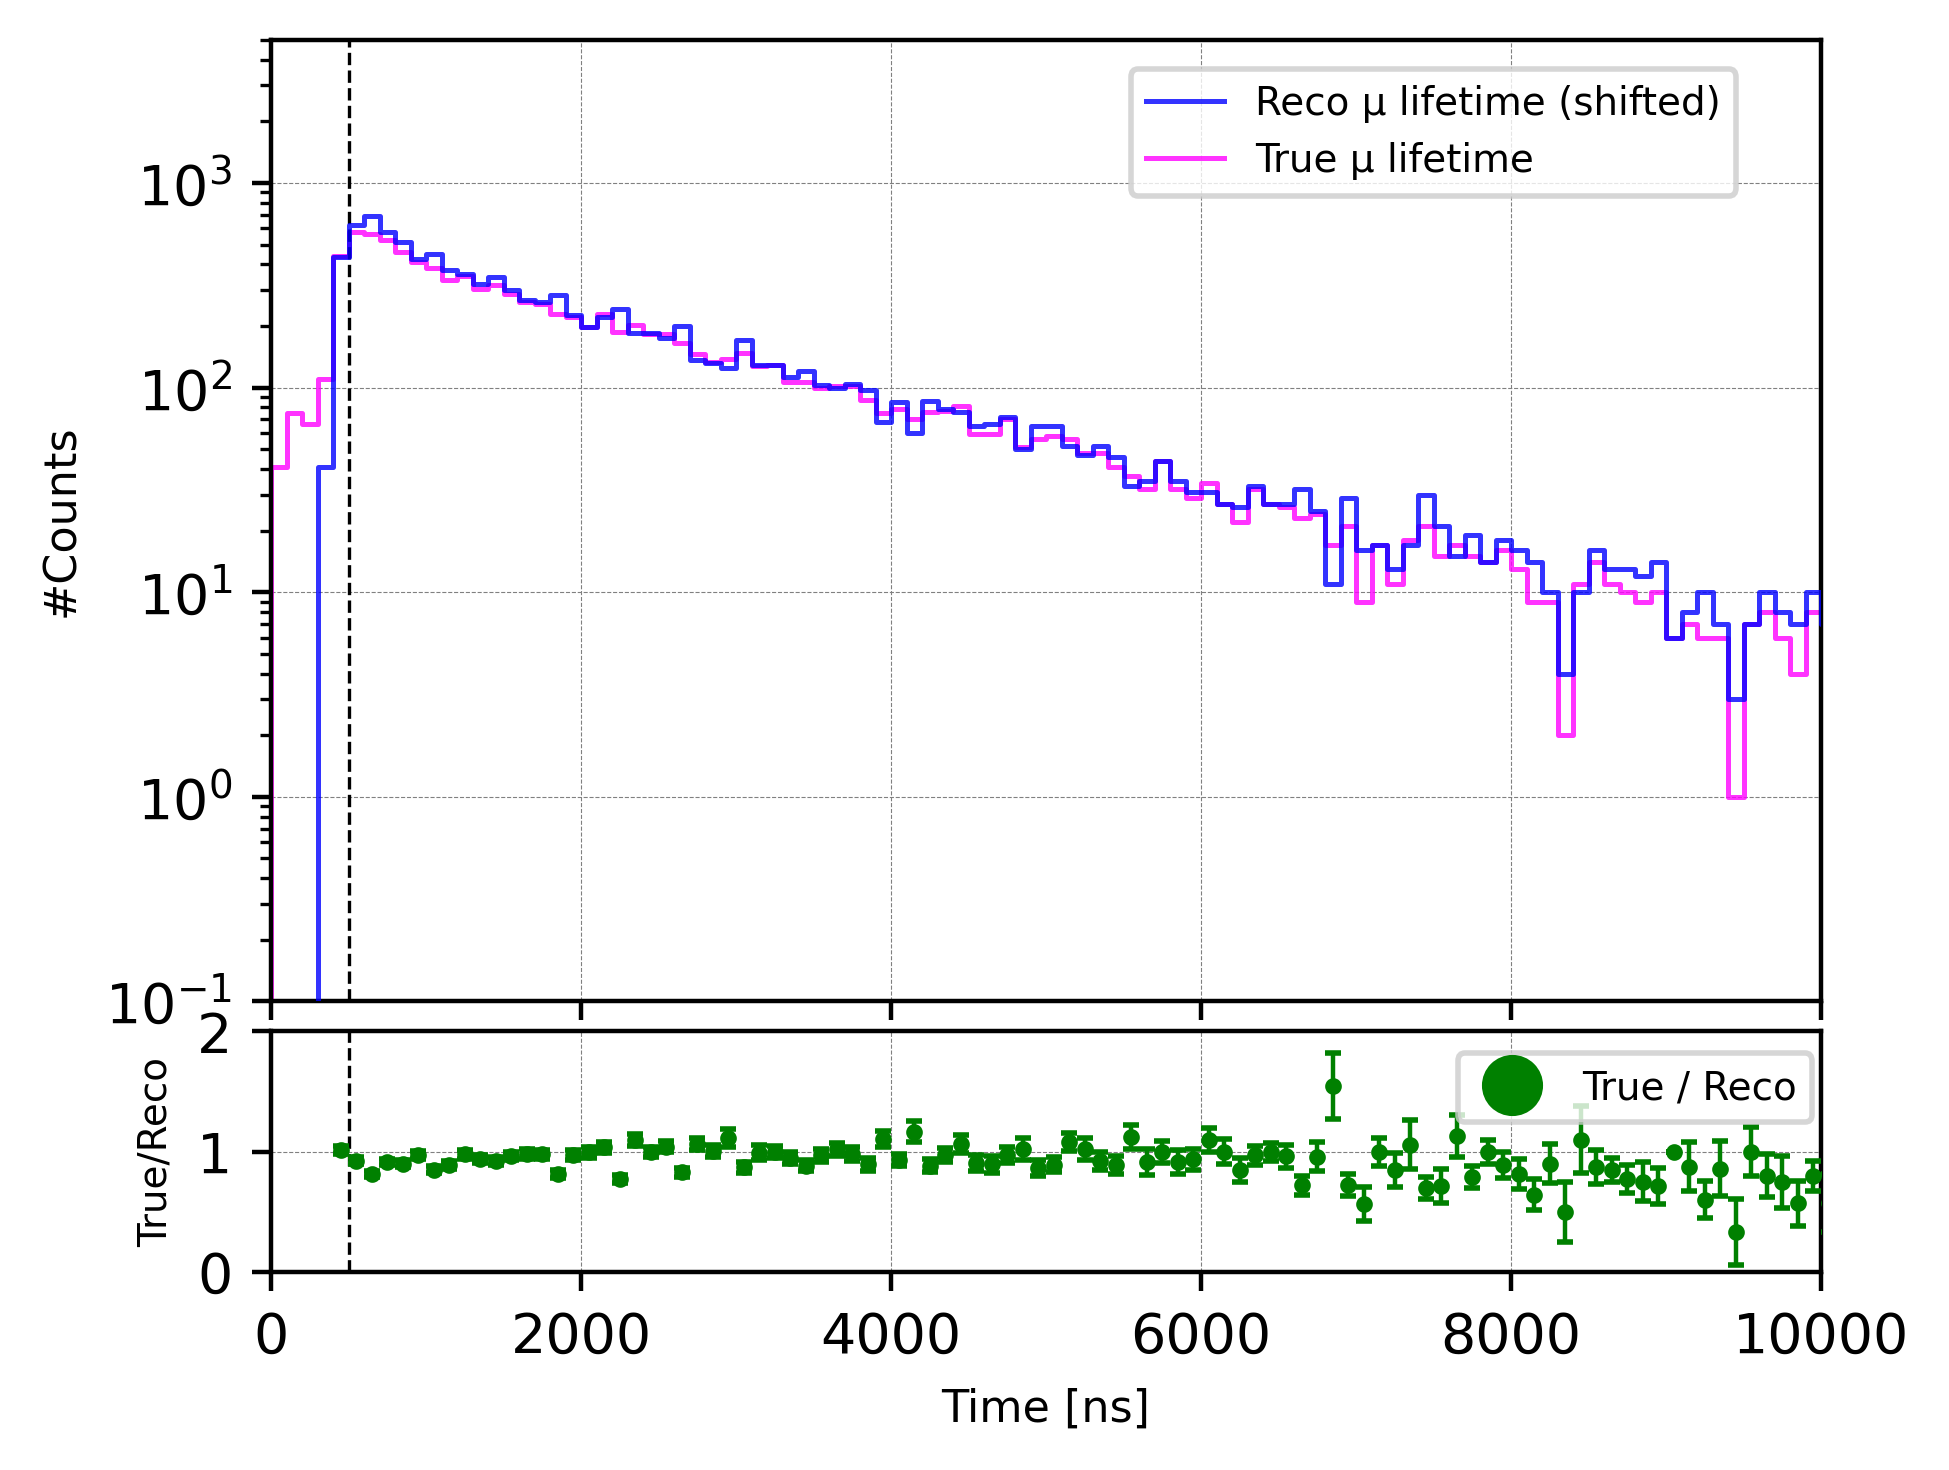

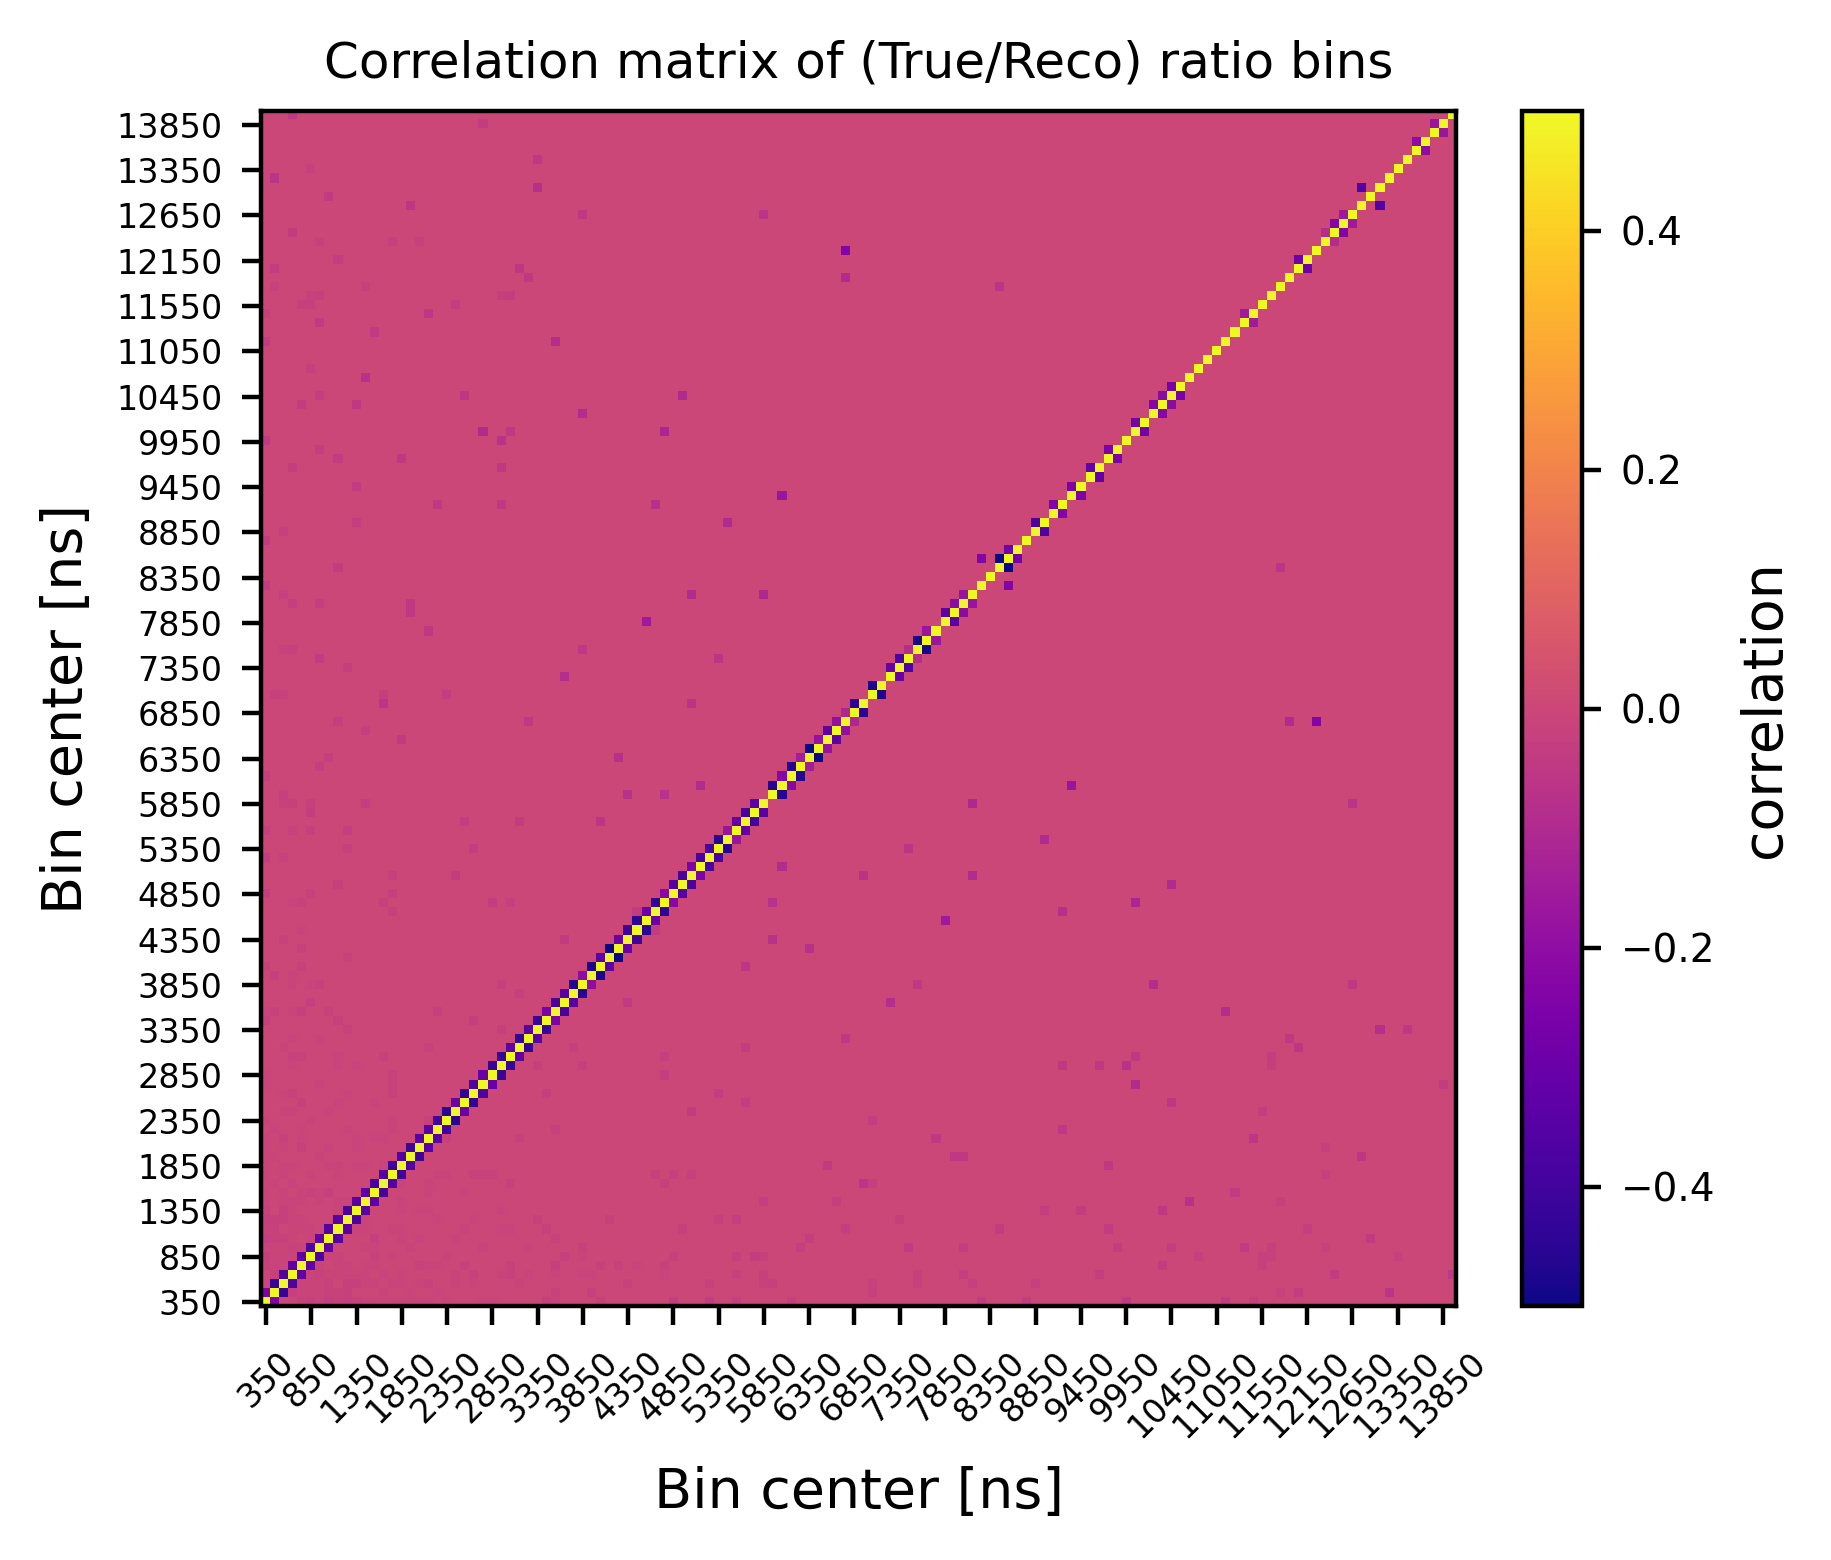

In [110]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ====== Extract lifetimes =====================================================
recoT_total_purify9 = [ev.reco_lifetime for ev in events_total_purify9]
trueT_total_purify9 = [ev.true_lifetime for ev in events_total_purify9]
recoT_total_purify9_shift40 = [x + 40 for x in recoT_total_purify9]  # ns shift

# ====== Double Panel: Hist + Ratio ============================================
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Histogram binning
bin_width = 100
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(bin_centers)

# -------- Top panel -----------------------------------------------------------
ax1 = fig.add_subplot(gs[0])

# Histograms (paired events)
counts_reco, _ = np.histogram(recoT_total_purify9_shift40, bins=bins, range=(range_min, range_max))
counts_true, _ = np.histogram(trueT_total_purify9, bins=bins, range=(range_min, range_max))

# Plot both as step histograms
ax1.step(bins[:-1], counts_reco, where='post', color='blue',
         linewidth=0.9, alpha=0.8, label='Reco μ lifetime (shifted)', zorder=3)
ax1.step(bins[:-1], counts_true, where='post', color='magenta',
         linewidth=0.9, alpha=0.8, label='True μ lifetime', zorder=2)

# Style
ax1.set_xlim(-2000, 16000)
ax1.tick_params(labelbottom=False)
ax1.set_ylim(0.1, 5000)
ax1.set_yscale('log')
ax1.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax1.legend(loc='upper center', bbox_to_anchor=(0.75, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})

# -------- Build 2D joint histogram (True vs Reco) -----------------------------
joint, _, _ = np.histogram2d(trueT_total_purify9, recoT_total_purify9_shift40, bins=[bins, bins])
N = joint.sum()
if N == 0:
    raise ValueError("No events found in joint histogram!")

# Empirical probabilities
p = joint / N
pT = p.sum(axis=1)  # marginal over reco (true dist)
pC = p.sum(axis=0)  # marginal over true (reco dist)

# -------- Build covariance matrices ------------------------------------------
Cov_TT = np.zeros((nb, nb))
Cov_CC = np.zeros((nb, nb))
Cov_TC = np.zeros((nb, nb))
for i in range(nb):
    for j in range(nb):
        Cov_TT[i, j] = N * ((pT[i] if i == j else 0.0) - pT[i] * pT[j])
        Cov_CC[i, j] = N * ((pC[i] if i == j else 0.0) - pC[i] * pC[j])
for i in range(nb):
    for k in range(nb):
        Cov_TC[i, k] = N * (p[i, k] - pT[i] * pC[k])

# -------- Ratio and correlated propagation -----------------------------------
mask = counts_reco > 0
ratio = np.full(nb, np.nan)
ratio[mask] = counts_true[mask] / counts_reco[mask]

# Jacobians for delta propagation
J_T = np.zeros((nb, nb))
J_C = np.zeros((nb, nb))
for i in range(nb):
    if counts_reco[i] > 0:
        J_T[i, i] = 1.0 / counts_reco[i]
        J_C[i, i] = -counts_true[i] / (counts_reco[i] ** 2)

# Full covariance of ratio (includes bin correlations!)
Cov_R = (
    J_T @ Cov_TT @ J_T.T +
    J_C @ Cov_CC @ J_C.T +
    J_T @ Cov_TC @ J_C.T +
    J_C @ Cov_TC.T @ J_T.T
)
sigma_ratio = np.sqrt(np.clip(np.diag(Cov_R), 0, np.inf))

# -------- Bottom panel (ratio) -----------------------------------------------
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.errorbar(bin_centers, ratio, yerr=sigma_ratio,
             fmt='o', color='green', markersize=2.0,
             elinewidth=0.8, capsize=1.5, label='True / Reco', zorder=3)

ax2.axvline(x=500, color='black', linestyle='--', linewidth=0.6)
ax2.set_xlim(0, 10000)
ax2.set_ylim(0.0, 2.0)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('True/Reco', fontsize=7)
ax2.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
ax2.legend(loc='upper center', bbox_to_anchor=(0.88, 0.99),
           fontsize=8, markerscale=5, ncol=1, prop={'size':7})

plt.show()






good_bins = np.where(mask & np.isfinite(ratio) & (sigma_ratio > 0))[0]

# Build correlation matrix
Cov_valid = Cov_R[np.ix_(good_bins, good_bins)]
sigma_valid = np.sqrt(np.clip(np.diag(Cov_valid), 1e-12, np.inf))
corr_masked = Cov_valid / np.outer(sigma_valid, sigma_valid)
corr_masked = np.clip(corr_masked, -1.0, 1.0)


# Example: show tick labels every Nth bin
tick_step = 5
tick_idx = np.arange(0, len(good_bins), tick_step)
tick_labels = (bin_centers[good_bins][tick_idx]).astype(int)

plt.figure(figsize=(5, 4), dpi=400)
im = plt.imshow(
    corr_masked,
    vmin=-0.5, vmax=0.5,
    cmap='plasma',
    origin='lower',
    interpolation='nearest'
)
plt.title("Correlation matrix of (True/Reco) ratio bins", fontsize=9)
plt.xticks(tick_idx, tick_labels, rotation=45, fontsize=6)
plt.yticks(tick_idx, tick_labels, fontsize=6)
plt.xlabel("Bin center [ns]")
plt.ylabel("Bin center [ns]")
cbar = plt.colorbar(im, label='correlation', fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()





#### Initial True Michel and Final True Michel---

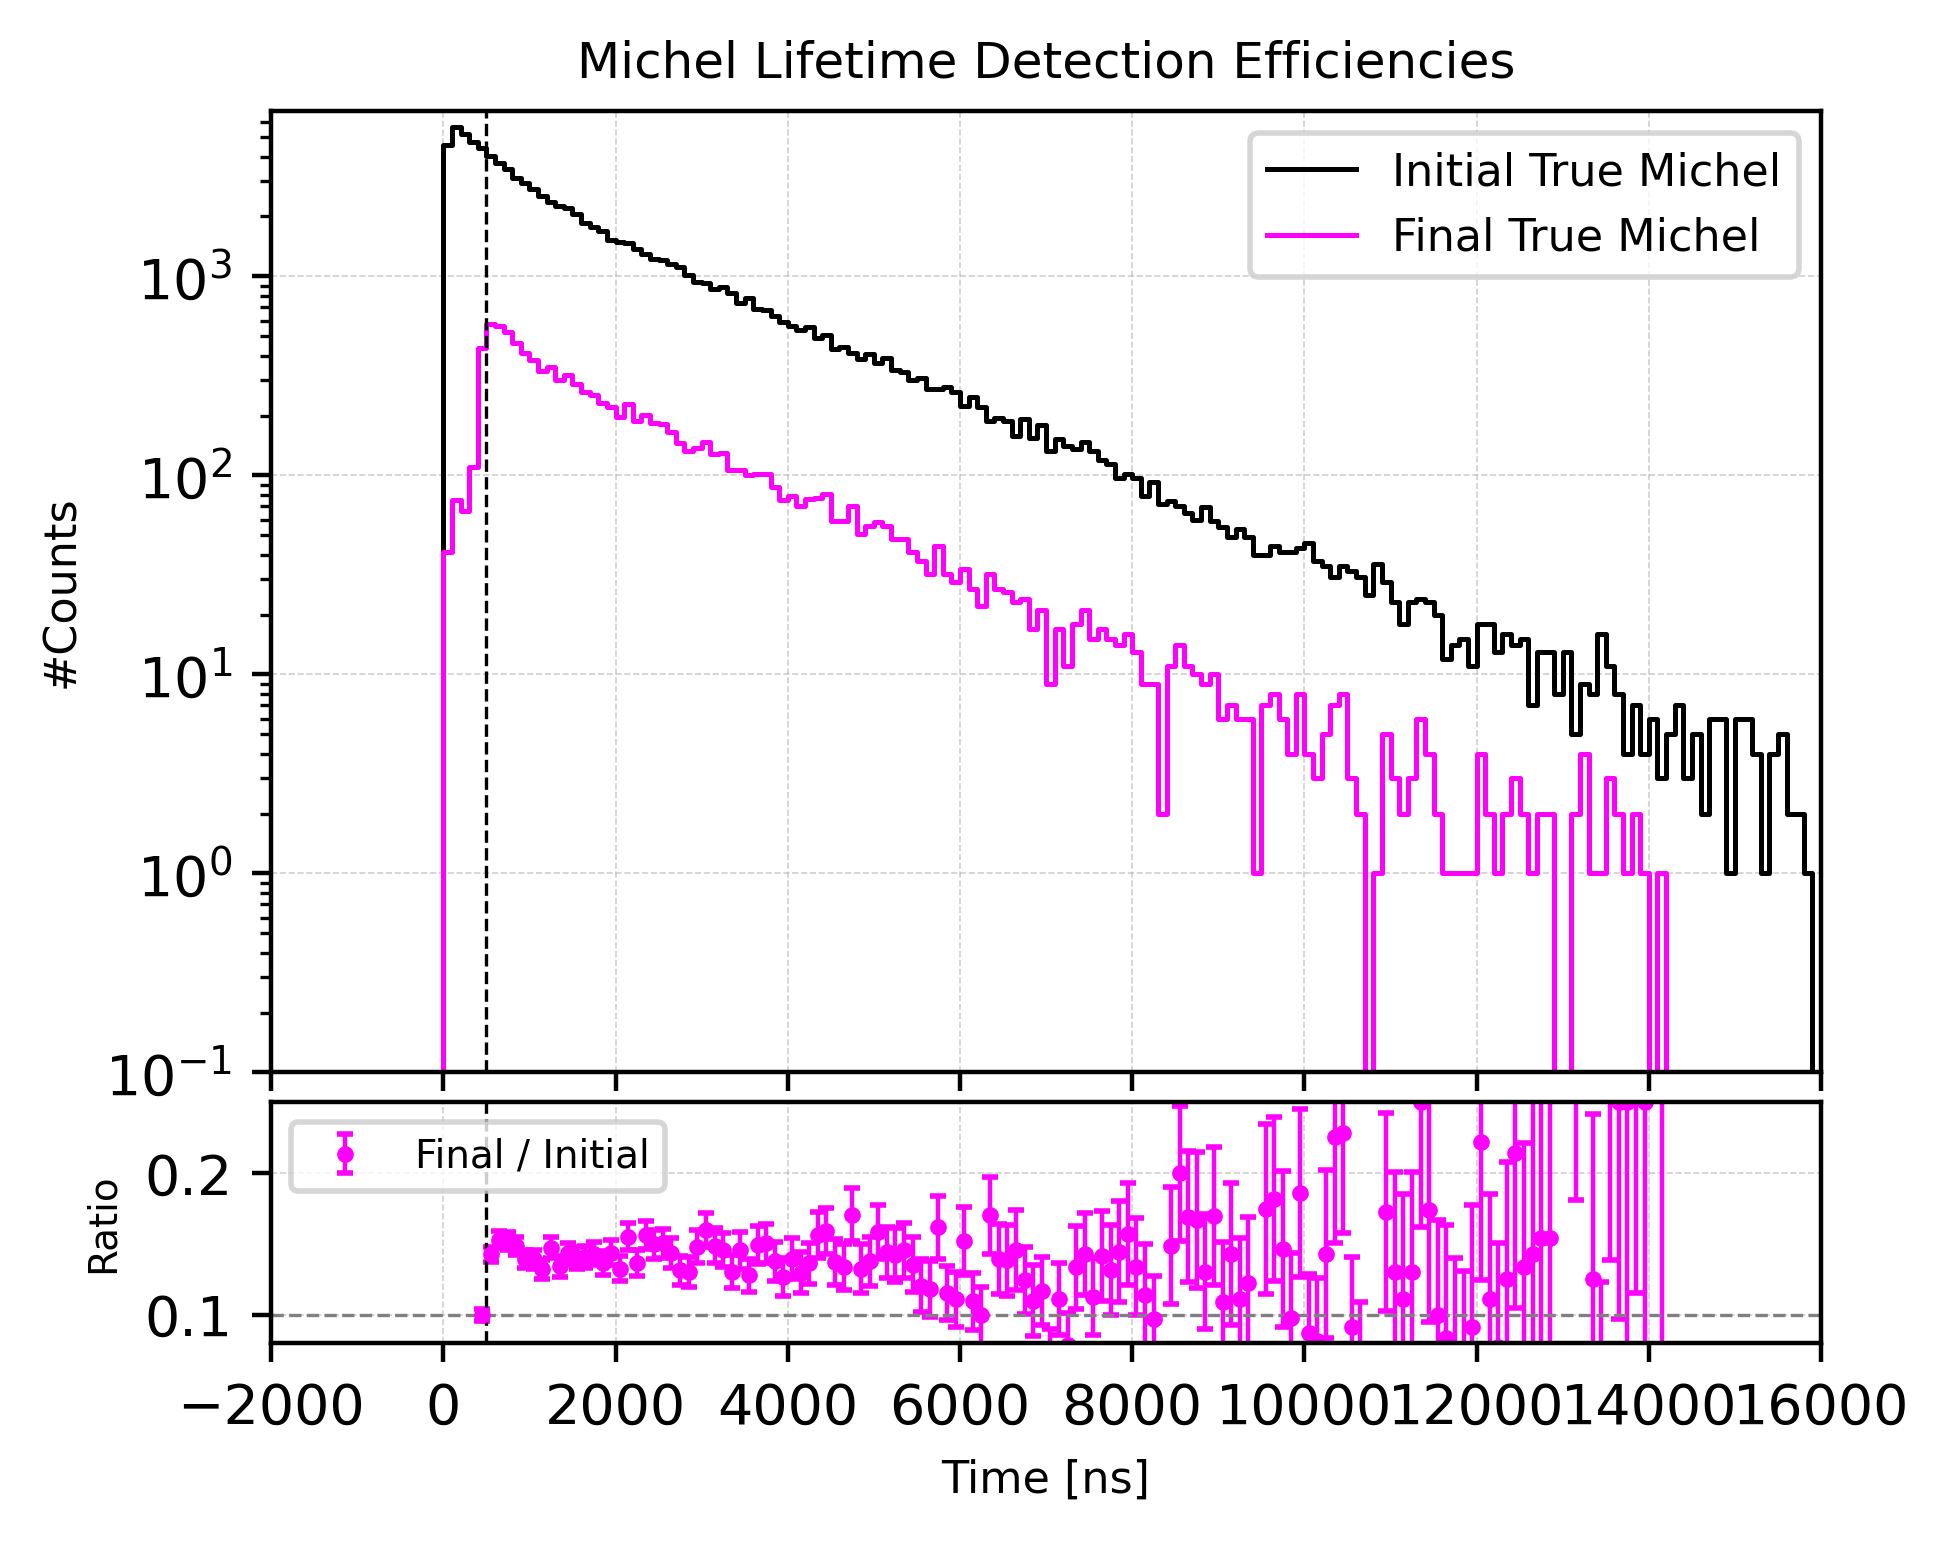

✅ Efficiency ratio and binomial uncertainties stored.
  Number of bins: 320
  Example efficiency range: 0.000–0.444
  Mean relative error: 30.710%
✅ Saved 159 valid bins for later use.
Example: bin=50 ns, ratio=0.009 ± 0.001


/var/folders/c9/547_2pf11mv74b226lzvqwj00000gn/T/ipykernel_46126/2571879795.py:81: RuntimeWarning: invalid value encountered in divide
  print(f"  Mean relative error: {np.nanmean(err_eff[mask]/eff[mask]):.3%}")


In [116]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy.ma as ma

# ----------------------------- Inputs ---------------------------------
trueMichel_initial = np.load("trueMichel_initial.npy", allow_pickle=True).tolist()
trueT_total_purify9 = np.asarray(trueT_total_purify9)

# ----------------------------- Binning --------------------------------
bin_width = 100
range_min, range_max = -16000, 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)
centers = 0.5 * (bins[:-1] + bins[1:])
nb = len(centers)

# ----------------------------- Histos ---------------------------------
I, _ = np.histogram(trueMichel_initial, bins=bins, range=(range_min, range_max))
F, _ = np.histogram(trueT_total_purify9, bins=bins, range=(range_min, range_max))

I = I.astype(float)
F = np.minimum(F.astype(float), I)  # guard: ensure F ≤ I
mask = I > 0

# ----------------------------- Efficiency -----------------------------
eff = np.full(nb, np.nan)
eff[mask] = F[mask] / I[mask]

# Binomial (conditional) uncertainty: sqrt(p(1-p)/I)
err_eff = np.full(nb, np.nan)
err_eff[mask] = np.sqrt(np.clip(eff[mask] * (1 - eff[mask]) / I[mask], 0, np.inf))

# Covariance: diagonal only (bins independent)
Cov_eff = np.zeros((nb, nb))
Cov_eff[np.diag_indices(nb)] = np.nan_to_num(err_eff ** 2, nan=0.0)


# ----------------------------- Plots ----------------------------------
fig = plt.figure(figsize=(5, 4), dpi=400)
gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Top panel: counts
ax1 = fig.add_subplot(gs[0])
ax1.step(bins[:-1], I, where='post', color='black', lw=0.9, label='Initial True Michel')
ax1.step(bins[:-1], F, where='post', color='magenta', lw=0.9, label='Final True Michel')
ax1.set_yscale('log')
ax1.set_ylim(0.1, max(10, 1.2 * np.nanmax(I)))
ax1.set_xlim(-2000, 16000)
ax1.axvline(500, ls='--', c='k', lw=0.6)
ax1.set_ylabel('#Counts', fontsize=8)
ax1.set_title("Michel Lifetime Detection Efficiencies", fontsize=9)
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(ls='--', lw=0.3, alpha=0.6)
ax1.tick_params(labelbottom=False)

# Bottom panel: efficiency
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.errorbar(centers[mask], eff[mask], yerr=err_eff[mask],
             fmt='o', ms=2.0, elinewidth=0.8, capsize=1.5,
             color='magenta', label='Final / Initial')
ax2.axvline(500, ls='--', c='k', lw=0.6)
ax2.axhline(0.1, ls='--', c='gray', lw=0.6)
ax2.set_xlim(-2000, 16000)
ax2.set_ylim(0.08, 0.25)
ax2.set_xlabel('Time [ns]', fontsize=8)
ax2.set_ylabel('Ratio', fontsize=7)
ax2.grid(ls='--', lw=0.3, alpha=0.6)
ax2.legend(fontsize=7, loc='upper left')
plt.show()

# ----------------------------- Save Results ---------------------------
lifetime_efficiency = eff.copy()
lifetime_efficiency_unc = err_eff.copy()
Cov_efficiency = Cov_eff.copy()
bin_edges_eff = bins.copy()
bin_centers_eff = centers.copy()

print("✅ Efficiency ratio and binomial uncertainties stored.")
print(f"  Number of bins: {len(lifetime_efficiency)}")
print(f"  Example efficiency range: {np.nanmin(lifetime_efficiency):.3f}–{np.nanmax(lifetime_efficiency):.3f}")
print(f"  Mean relative error: {np.nanmean(err_eff[mask]/eff[mask]):.3%}")



# ============================================================
# Save efficiency ratios and uncertainties for later notebook use
# ============================================================

# Keep only valid (I > 0) bins
valid_idx = np.where(I > 0)[0]

# Lists for later use
efficiency_bins = centers[valid_idx].tolist()       # bin centers [ns]
efficiency_ratio = eff[valid_idx].tolist()          # Final / Initial
efficiency_uncertainty = err_eff[valid_idx].tolist()  # Binomial σ

print(f"✅ Saved {len(efficiency_ratio)} valid bins for later use.")
print(f"Example: bin={efficiency_bins[0]:.0f} ns, ratio={efficiency_ratio[0]:.3f} ± {efficiency_uncertainty[0]:.3f}")



<br />
<br />

#### Apply efficiency curve (CORE):

n_final total entries: 11401.0
Nonzero bins: 762 / 102400


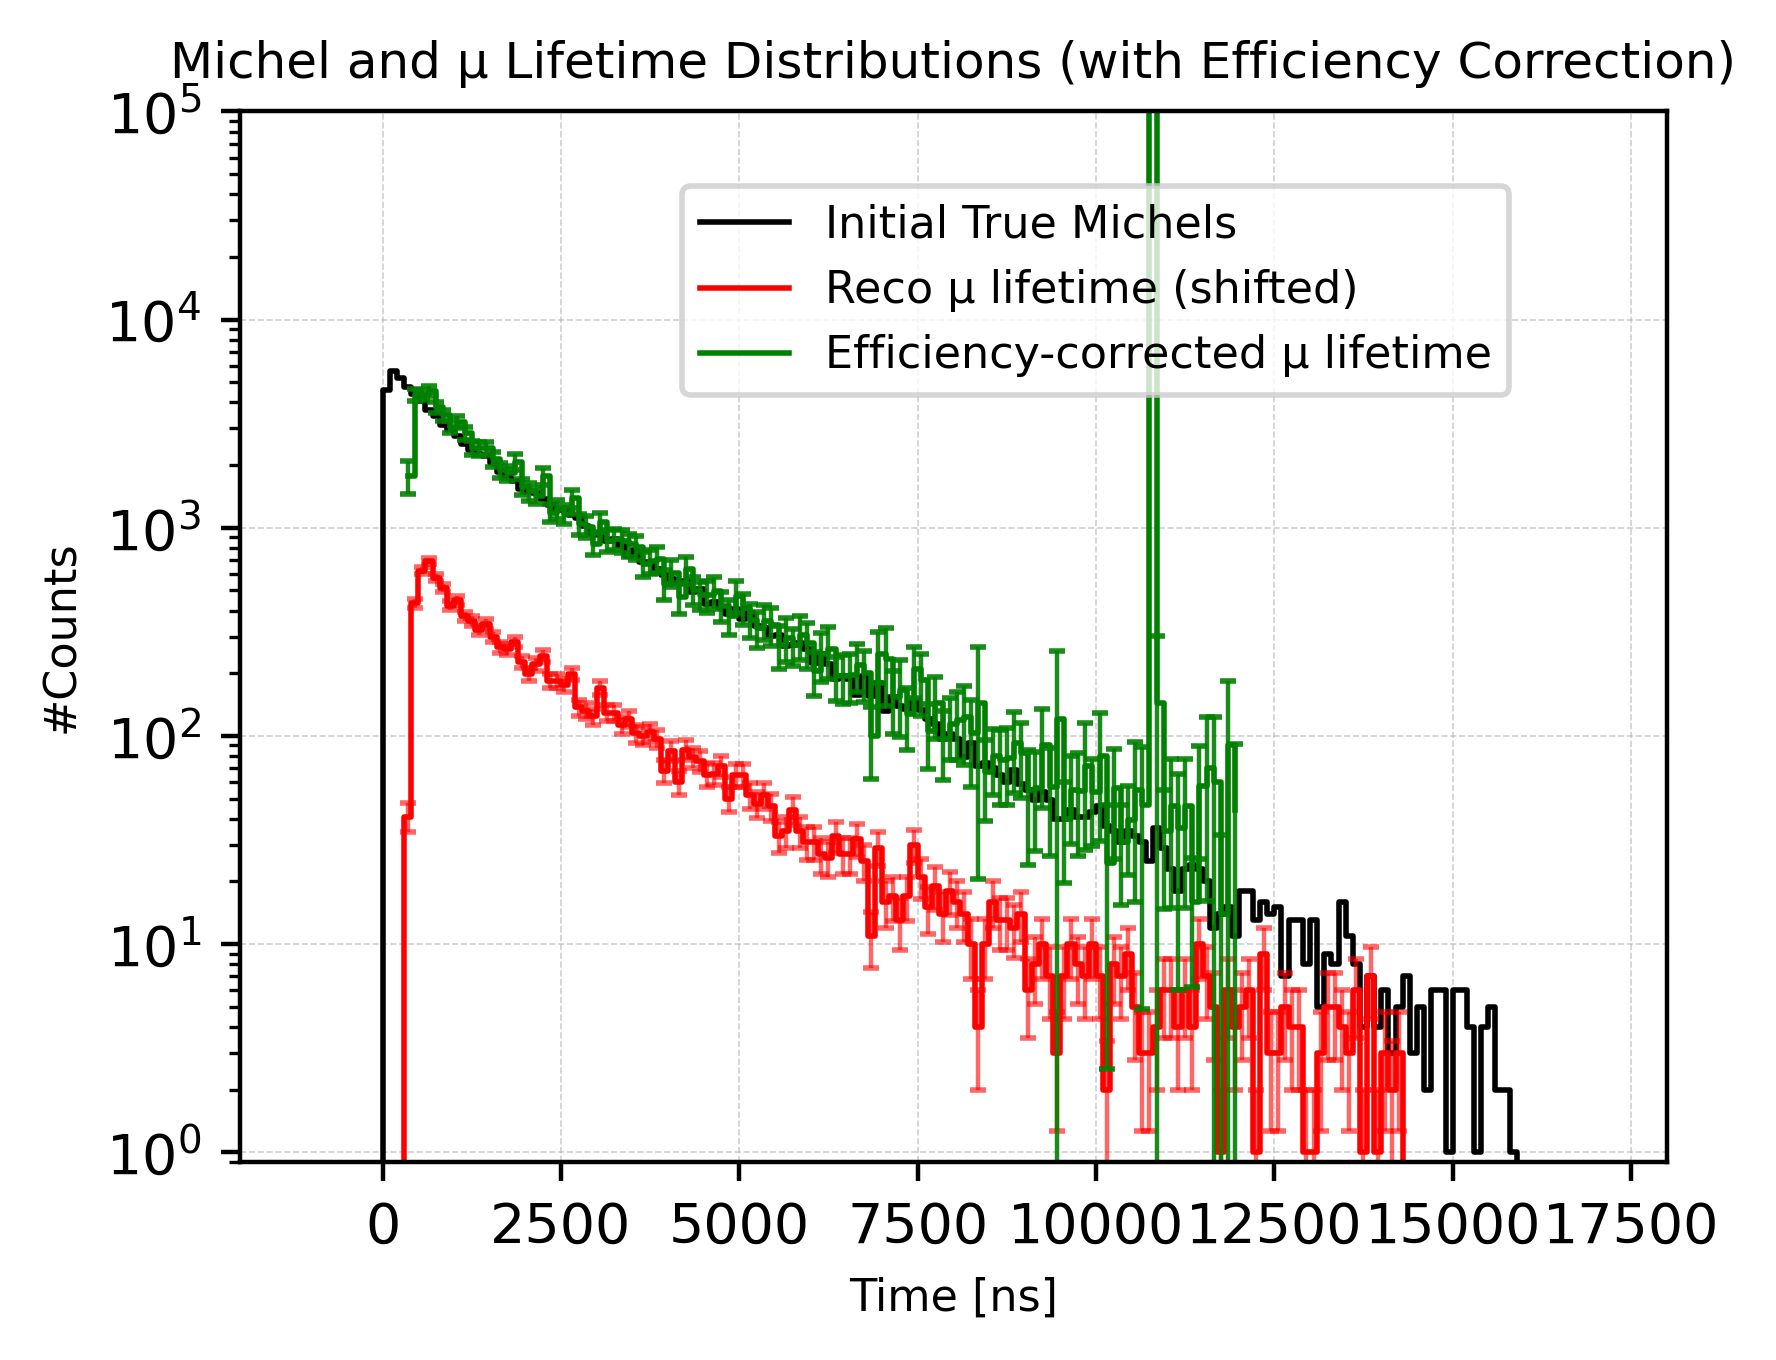

✅ Efficiency-corrected reco histogram built for 117 bins.
   Mean correction factor ≈ 132075471706.96×


In [119]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Binning setup — reuse from efficiency calculation
# ============================================================
bins = bin_edges_eff.copy()
centers = bin_centers_eff.copy()
nb = len(centers)


# ============================================================
# 2. Load efficiency results from previous cell
# ============================================================
eff = np.clip(lifetime_efficiency, 1e-12, None)              # ratio Final/Initial
eff_unc = np.nan_to_num(lifetime_efficiency_unc, nan=0.0)    # binomial uncertainty
Cov_eff = Cov_efficiency.copy()                              # diagonal covariance


# ============================================================
# 3. Build final true–reco 2D table from paired events
# ============================================================
true_idx = np.digitize(trueT_total_purify9, bins) - 1
reco_idx = np.digitize(recoT_total_purify9_shift40, bins) - 1

valid = (
    (true_idx >= 0) & (true_idx < nb) &
    (reco_idx >= 0) & (reco_idx < nb)
)
true_idx = true_idx[valid]
reco_idx = reco_idx[valid]

# 2D true–reco histogram after cuts
n_final = np.zeros((nb, nb), dtype=float)
np.add.at(n_final, (true_idx, reco_idx), 1.0)

print(f"n_final total entries: {np.sum(n_final)}")
print(f"Nonzero bins: {np.count_nonzero(n_final)} / {nb*nb}")


# ============================================================
# 4. Apply efficiency correction (A/B-style propagation)
# ============================================================
# Reco histogram before correction
counts_reco, _ = np.histogram(recoT_total_purify9_shift40, bins=bins)
sigma_reco = np.sqrt(np.clip(counts_reco, 0, None))

# Efficiency-corrected spectrum: simple division (float-safe)
R_corr = np.divide(counts_reco.astype(float), eff,
                   out=np.zeros_like(counts_reco, dtype=float),
                   where=eff > 0)

# Propagate error: σ² = (σ_R/ε)² + (R * σ_ε / ε²)²
Var_Rcorr = (
    (sigma_reco / np.clip(eff, 1e-12, None)) ** 2 +
    ((counts_reco * eff_unc) / np.clip(eff, 1e-12, None) ** 2) ** 2
)
sigma_R_corr = np.sqrt(np.clip(Var_Rcorr, 0, None))


# ============================================================
# 5. Reference histograms (for visual comparison)
# ============================================================
counts_initial, _ = np.histogram(trueMichel_initial, bins=bins, range=(range_min, range_max))

# ============================================================
# 6. Plot
# ============================================================
plt.figure(figsize=(4.5, 3.5), dpi=400)

# (a) Initial true Michel
plt.step(bins[:-1], counts_initial, where='post',
         color='black', linewidth=1.0, label='Initial True Michels')

# (b) Reco μ lifetime (shifted)
plt.step(bins[:-1], counts_reco, where='post',
         color='red', linewidth=1.0, label='Reco μ lifetime (shifted)')
plt.errorbar(centers, counts_reco, yerr=sigma_reco,
             fmt='none', ecolor='red', elinewidth=0.8, capsize=1.5, alpha=0.6)

# (c) Efficiency-corrected μ lifetime
region_mask = (centers >= 0) & (centers <= 12000) & np.isfinite(R_corr) & (R_corr > 0)
plt.plot(centers[region_mask], R_corr[region_mask],
         drawstyle='steps-post', color='green', lw=1.0, label='Efficiency-corrected μ lifetime')
plt.errorbar(centers[region_mask], R_corr[region_mask],
             yerr=sigma_R_corr[region_mask],
             fmt='none', ecolor='green', elinewidth=0.8, capsize=1.5, alpha=0.9)

# Axes and style
plt.xlim(-2000, 18000)
plt.ylim(0.9, 100000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.yscale('log')
plt.grid(ls='--', lw=0.3, alpha=0.6)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.95), fontsize=8)
plt.title('Michel and μ Lifetime Distributions (with Efficiency Correction)', fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 7. Save outputs for later fitting or ratio comparisons
# ============================================================
effcorr_reco_counts = R_corr.copy()
effcorr_reco_unc = sigma_R_corr.copy()

Var_data = (sigma_reco / np.clip(eff, 1e-12, None)) ** 2
Var_eff = ((counts_reco * eff_unc) / np.clip(eff, 1e-12, None) ** 2) ** 2
Cov_effcorr_reco = np.diag(Var_data + Var_eff)

print(f"✅ Efficiency-corrected reco histogram built for {np.count_nonzero(region_mask)} bins.")
print(f"   Mean correction factor ≈ {np.nanmean(1/eff[eff>0]):.2f}×")


#### Double exponential fitting (fixed tau2 and r)

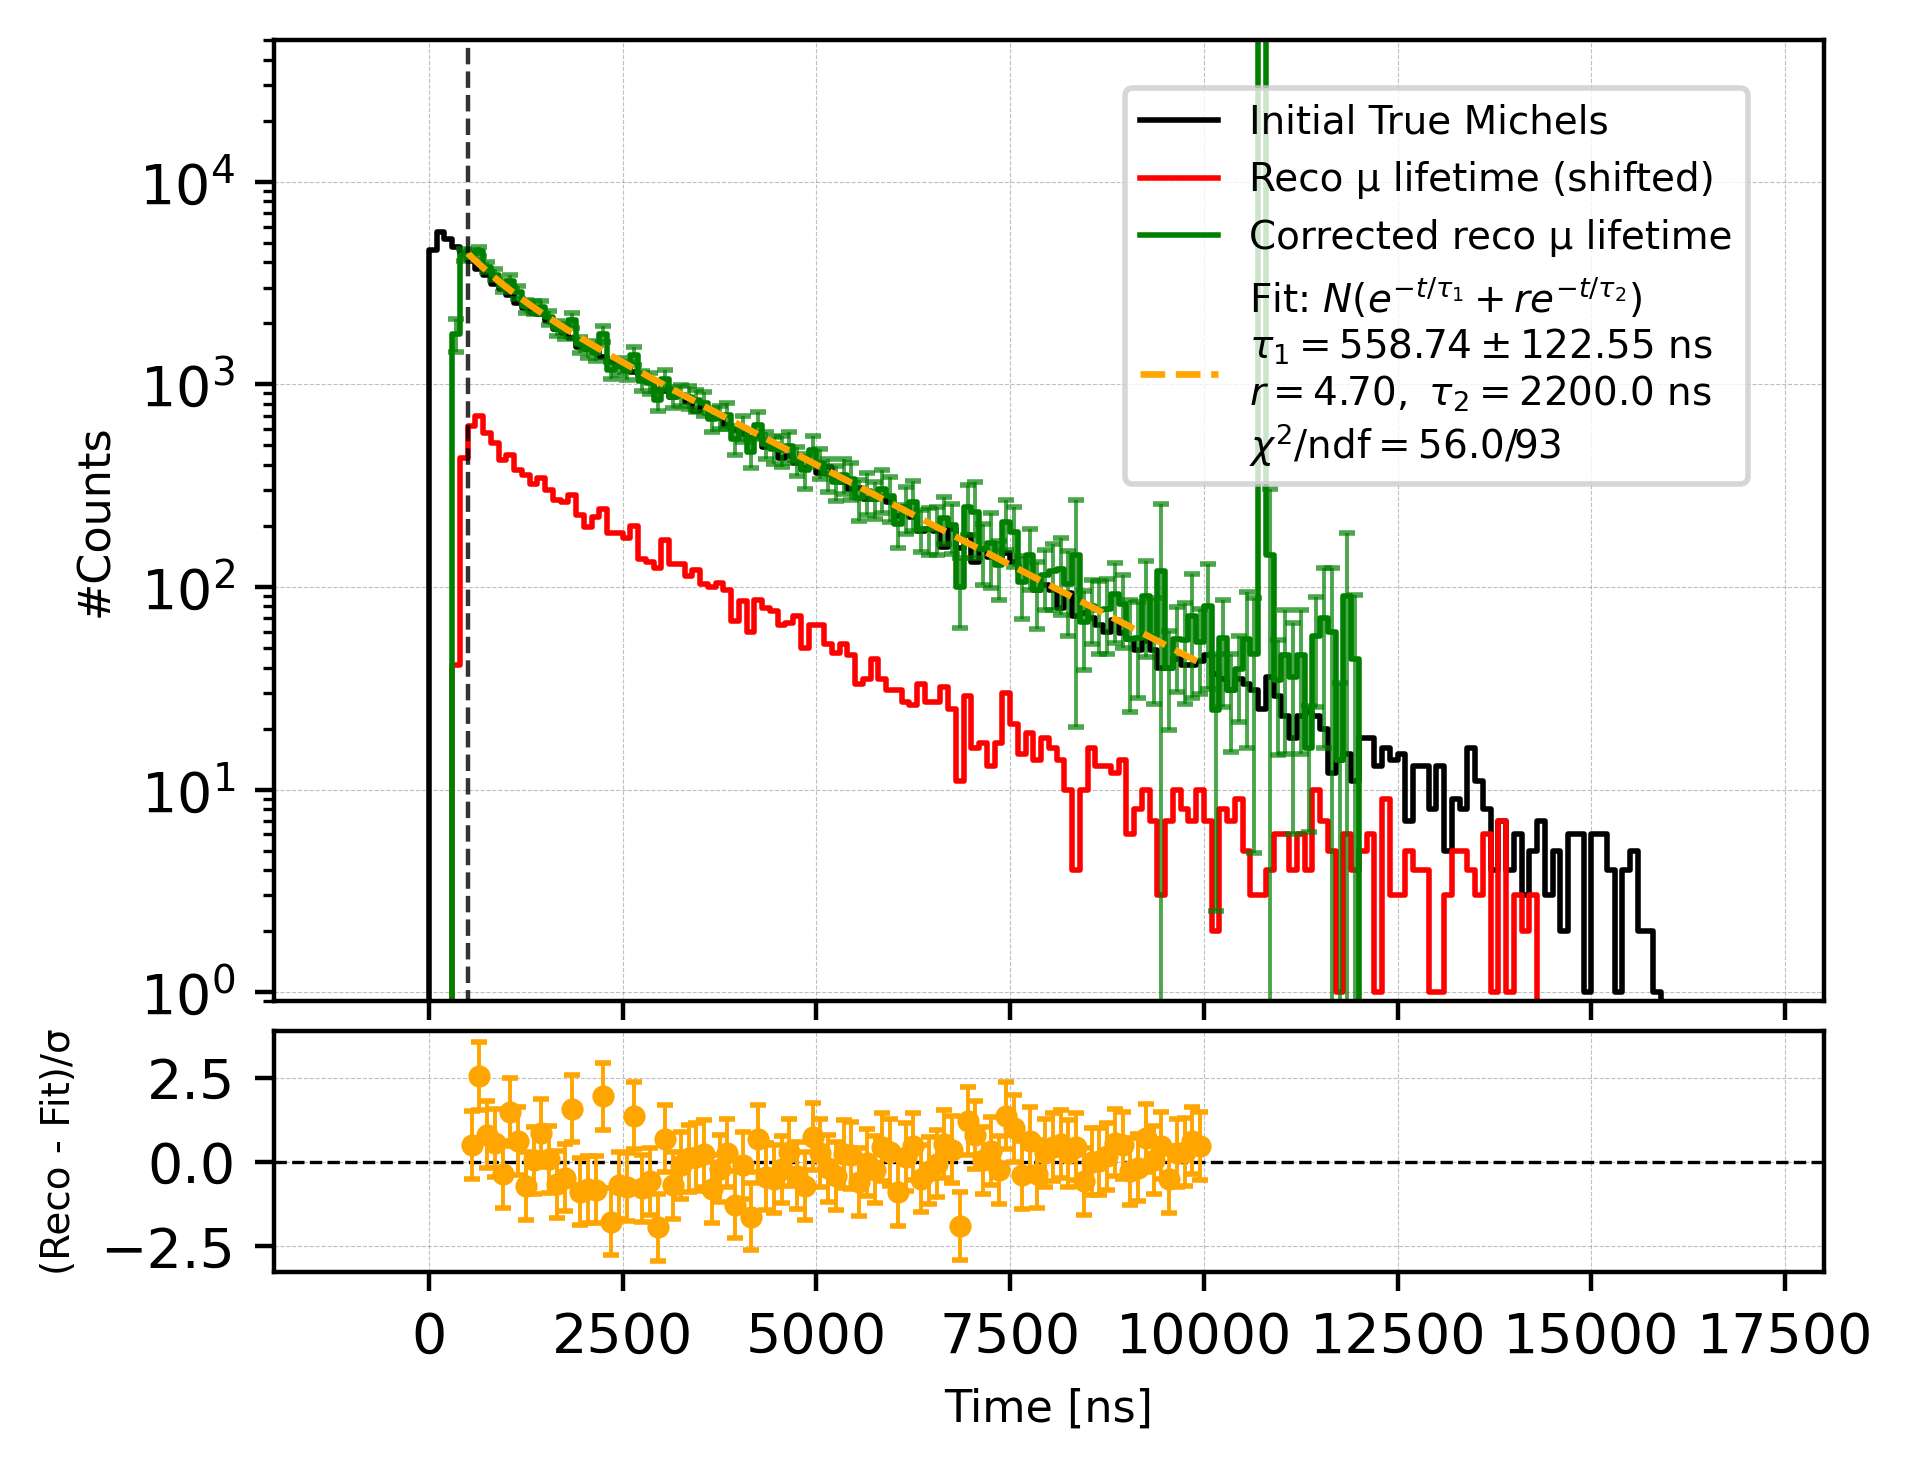


Fit results:
  N        = 18166.664 ± 431.926
  τ₁       = 558.740 ± 122.553 ns
  r        = 4.70
  τ₂       = 2200.0 ns
  χ²/ndf   = 56.0/93 = 0.60


In [126]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Double exponential integrated model ---------------------------------------
def exp2_integrated(bin_edges, N, tau1, ratio=4.8, tau2=2200.0):
    a = bin_edges[:-1]
    b = bin_edges[1:]
    term1 = np.exp(-a / tau1) - np.exp(-b / tau1)
    term2 = np.exp(-a / tau2) - np.exp(-b / tau2)
    return N * (term1 + ratio * term2)

# --- Perform fit on efficiency-corrected data ----------------------------------
def fit_efficiency_corrected(bin_edges, y, yerr, counts_initial, counts_reco, sigma_reco,
                             fit_range=(0, 10000), ratio=4.8, tau2=2200.0,
                             xlim_manual=(-2000, 16000)):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (y > 0)
    if not np.any(mask):
        print("No valid bins in fit range.")
        return None

    edges_fit = bin_edges[mask.nonzero()[0][0] : mask.nonzero()[0][-1] + 2]
    y_fit = y[mask]
    sigma = np.clip(yerr[mask], 1.0, None)

    # initial guesses
    N0 = np.sum(y_fit)
    tau1_0 = 1000.0

    # fit using curve_fit
    popt, pcov = curve_fit(
        lambda edges, N, tau1: exp2_integrated(edges, N, tau1, ratio, tau2),
        edges_fit, y_fit,
        p0=[N0, tau1_0],
        sigma=sigma, absolute_sigma=True,
        bounds=([0, 1e-6], [np.inf, np.inf])
    )

    N_fit, tau1_fit = popt
    N_err, tau1_err = np.sqrt(np.diag(pcov))

    # compute fitted model for all bins
    y_model = exp2_integrated(bin_edges, *popt, ratio=ratio, tau2=tau2)
    pulls = np.zeros_like(y)
    valid = (yerr > 0)
    pulls[valid] = (y[valid] - y_model[valid]) / yerr[valid]

    chi2 = np.sum(((y_fit - exp2_integrated(edges_fit, *popt, ratio, tau2)) / sigma) ** 2)
    ndf = len(y_fit) - len(popt)

    # ========================
    # Draw figure
    # ========================
    fig, (ax, ax_resid) = plt.subplots(
        2, 1, figsize=(5, 4), dpi=400, sharex=True,
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
    )

    # --- Top panel: three histograms + fit (closed)
    ax.step(bin_edges, np.append(counts_initial, counts_initial[-1]),
            where='post', color='black', linewidth=1.0, label='Initial True Michels')
    ax.step(bin_edges, np.append(counts_reco, counts_reco[-1]),
            where='post', color='red', linewidth=1.0, label='Reco μ lifetime (shifted)')
    ax.step(bin_edges, np.append(y, y[-1]),
            where='post', color='green', linewidth=1.0, label='Corrected reco μ lifetime')

    ax.errorbar(bin_centers, y, yerr=yerr, fmt='none', ecolor='green',
                elinewidth=0.7, capsize=1.5, alpha=0.7)

    # Smooth fit line
    x_smooth = np.linspace(fit_range[0], fit_range[1], 400)
    y_smooth = (N_fit / tau1_fit) * np.exp(-x_smooth / tau1_fit) * (bin_edges[1] - bin_edges[0]) \
               + (N_fit * ratio / tau2) * np.exp(-x_smooth / tau2) * (bin_edges[1] - bin_edges[0])
    ax.plot(x_smooth, y_smooth, color='orange', linestyle='--', linewidth=1.2,
            label=(fr"Fit: $N(e^{{-t/\tau_1}} + r e^{{-t/\tau_2}})$" + "\n"
                   + rf"$\tau_1={tau1_fit:.2f}\pm{tau1_err:.2f}$ ns" + "\n"
                   + rf"$r={ratio:.2f},\ \tau_2={tau2:.1f}$ ns" + "\n"
                   + rf"$\chi^2/\mathrm{{ndf}}={chi2:.1f}/{ndf}$"))

    ax.vlines(x=500, ymin=0.1, ymax=1e5,
          color='black', linestyle='--', lw=0.8, alpha=0.8)


    # Style for top panel
    ax.set_yscale('log')
    ax.set_xlim(*xlim_manual)
    ax.set_ylim(0.9, 5e4)
    ax.set_ylabel('#Counts', fontsize=8)
    ax.tick_params(labelbottom=False)
    ax.grid(color='gray', linestyle='--', linewidth=0.2, alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.75, 0.97), fontsize=7)
#    ax.set_title("Michel and μ Lifetime Distributions + Fit", fontsize=9)

    # --- Bottom panel: residuals (pulls)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    ax_resid.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax_resid.errorbar(bin_centers[fit_mask], pulls[fit_mask], yerr=np.ones(np.sum(fit_mask)),
                      fmt='o', color='orange', markersize=3, elinewidth=0.7, capsize=1.5)
    ax_resid.set_xlim(*xlim_manual)
    ax_resid.set_xlabel('Time [ns]', fontsize=8)
    ax_resid.set_ylabel('(Reco - Fit)/σ', fontsize=7)
    ax_resid.grid(color='gray', linestyle='--', linewidth=0.2, alpha=0.5)

    plt.show()

    # --- Print results
    print(f"\nFit results:")
    print(f"  N        = {N_fit:.3f} ± {N_err:.3f}")
    print(f"  τ₁       = {tau1_fit:.3f} ± {tau1_err:.3f} ns")
    print(f"  r        = {ratio:.2f}")
    print(f"  τ₂       = {tau2:.1f} ns")
    print(f"  χ²/ndf   = {chi2:.1f}/{ndf:.0f} = {chi2/ndf:.2f}")

    return N_fit, N_err, tau1_fit, tau1_err, chi2, ndf, pulls

# --- Run fit on your efficiency-corrected distribution -------------------------
N_fit, N_err, tau1_fit, tau1_err, chi2, ndf, pulls = fit_efficiency_corrected(
    bin_edges=bin_edges,
    y=updated_reco_muon,
    yerr=sigma_updated_reco_muon,
    counts_initial=counts_initial,
    counts_reco=counts_reco,
    sigma_reco=sigma_reco,
    fit_range=(500, 10000),
    ratio=4.7,
    tau2=2200.0,
    xlim_manual=(-2000, 18000)
)
